# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [343]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#0adfc6ff"
    genotype_color['eYFP_ArchT'] = "#8F9FFF"
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    genotype_color['short_1'] = "#ff6600ff"
    genotype_color['short_2'] = "#ffdd00ff"
    genotype_color['F231A'] = '#F44636ff'
    genotype_color['F231A_wt'] =  '#5ba0d8ff'


    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]


# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
'#1F2A63'
'#C276A5'
"#f468f1ff"

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [335]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260511.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20260511.csv


## Main

### Visualize the cheeseboard maze task variables

In [336]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [290]:
dl.id, dl.ses_dir

('AL', 'ses-02_date-20250709')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

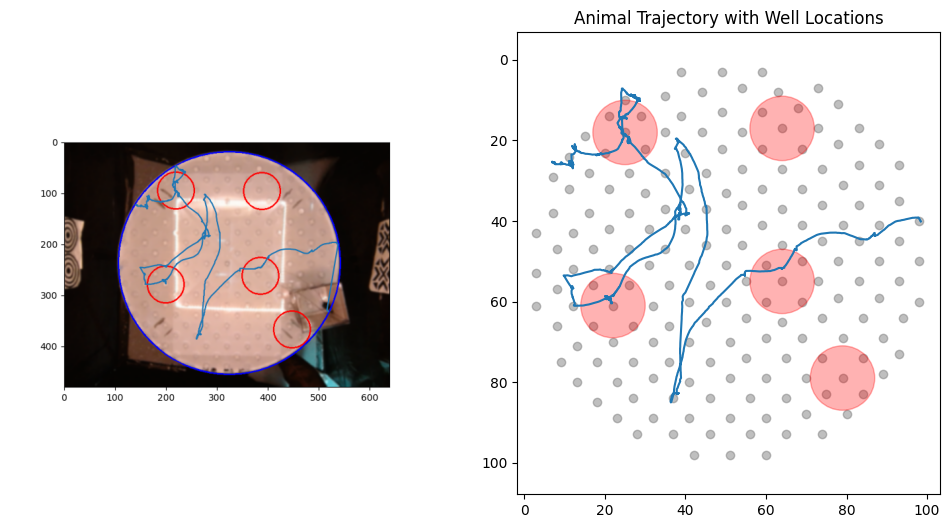

In [337]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [338]:
triggerLoc

,well_row,well_col,x,y
0,D,2,25,18
1,D,6,64,17
2,M,7,64,55
3,N,3,22,61
4,R,8,79,79


In [339]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,93406,166092,72686,1
1,213010,221155,8145,1
2,222870,223096,226,1
3,6961,13736,6775,3
4,46011,70075,24064,4


### Compute the time animal took to reach the trigger zone

In [340]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,gender,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,97,F8,20260503,8,6,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7252,97,F8,20260503,8,7,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7253,97,F8,20260503,8,8,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7254,97,F8,20260504,9,1,T,1,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN


# compute time to reward

In [344]:
# ============================================================
# COMPUTE:
#   1) t_to_trigger
#        = time to first reward-zone entry across ANY trigger
#        = all visits / any entry
#
#   2) t_to_trigger_long
#        = time to first reward-zone entry across ANY trigger
#        = only visits lasting > 2 s
#
# PLUS per-trigger values:
#   3) t_to_trigger_trig
#        = time to first entry into EACH trigger separately
#        = all visits / any entry
#
#   4) t_to_trigger_trig_long
#        = time to first entry into EACH trigger separately
#        = only visits lasting > 2 s
#
# Fallback:
#   If animal never enters a trigger/zone under that criterion,
#   use full trial duration.
#
# Output:
#   metadata keeps original wide columns:
#       t_to_trigger
#       t_to_trigger_long
#
#   meta_trig is long format:
#       one row per trial x trigger_id
#       includes t_to_trigger_trig and t_to_trigger_trig_long
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# Original code 1 columns
# DO NOT rename these because your plotting code depends on them.
# ------------------------------------------------------------
metadata['t_to_trigger'] = np.nan
metadata['t_to_trigger_long'] = np.nan

# Optional diagnostic columns
metadata['learned'] = False          # any trigger reached, all visits
metadata['learned_long'] = False     # any trigger reached, >2 s stay

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
R_TRIGGER = 10 / 1.2

# Match your original code 1:
# code 1 used duration > 2000 for long visits.
LONG_VISIT_MIN_DUR_MS = 2000

# Store long-format per-trigger rows here
trigger_rows = []


# ============================================================
# Main loop
# ============================================================

for trial_id in tqdm(range(len(metadata))):

    dl = DataLoader(metadata.iloc[trial_id])

    # --------------------------------------------------------
    # Load position
    # --------------------------------------------------------
    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    if 't' not in position.columns:
        continue

    # --------------------------------------------------------
    # Load trigger locations
    # --------------------------------------------------------
    triggerLoc = dl.get_data('triggerLoc')

    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        continue

    trigger_num = len(triggerLoc)

    # --------------------------------------------------------
    # Add distance to triggers
    # --------------------------------------------------------
    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    if position_ is None or len(position_) == 0:
        continue

    if 't' not in position_.columns:
        continue

    # Full trial time, used as fallback
    full_trial_time = position_.iloc[-1]['t']

    if not np.isfinite(full_trial_time):
        continue

    # --------------------------------------------------------
    # Get all trigger interactions
    # --------------------------------------------------------
    dfs = []

    for i in range(trigger_num):

        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trigger_interaction is not None and len(df_trigger_interaction) > 0:
            df_trigger_interaction = df_trigger_interaction.copy()
            df_trigger_interaction['trigger_id'] = i + 1
            dfs.append(df_trigger_interaction)

    # --------------------------------------------------------
    # If no visits to any trigger at all:
    # use full trial time for both original columns,
    # and for every per-trigger value.
    # --------------------------------------------------------
    if len(dfs) == 0:

        metadata.at[trial_id, 't_to_trigger'] = full_trial_time
        metadata.at[trial_id, 't_to_trigger_long'] = full_trial_time

        for trig_id in range(1, trigger_num + 1):
            trigger_rows.append({
                'trial_id': trial_id,
                'trigger_id': trig_id,

                # per-trigger all visits
                't_to_trigger_trig': full_trial_time,

                # per-trigger >2 s stay
                't_to_trigger_trig_long': full_trial_time,

                # diagnostics
                'reached_trigger_trig': False,
                'reached_trigger_trig_long': False,
                'full_trial_time': full_trial_time,
            })

        continue

    # --------------------------------------------------------
    # Combine all trigger visits
    # --------------------------------------------------------
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = (
        df_all_triggers
        .sort_values(by='t_enter')
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # ALL visits: original t_to_trigger
    # first entry into ANY trigger
    # --------------------------------------------------------
    if len(df_all_triggers) > 0:
        first_entry_time = df_all_triggers.iloc[0]['t_enter']
        metadata.at[trial_id, 't_to_trigger'] = first_entry_time
        metadata.at[trial_id, 'learned'] = True
    else:
        metadata.at[trial_id, 't_to_trigger'] = full_trial_time

    # --------------------------------------------------------
    # LONG visits only: original t_to_trigger_long
    # first >2 s entry into ANY trigger
    # --------------------------------------------------------
    df_long = df_all_triggers[
        df_all_triggers['duration'] > LONG_VISIT_MIN_DUR_MS
    ].copy()

    if len(df_long) > 0:
        first_long_entry = df_long.iloc[0]['t_enter']
        metadata.at[trial_id, 't_to_trigger_long'] = first_long_entry
        metadata.at[trial_id, 'learned_long'] = True
    else:
        metadata.at[trial_id, 't_to_trigger_long'] = full_trial_time

    # --------------------------------------------------------
    # PER-TRIGGER TIMES
    #
    # For each trigger separately:
    #   all visits:
    #       first entry into this trigger
    #       else full trial time
    #
    #   long visits:
    #       first entry into this trigger lasting >2 s
    #       else full trial time
    # --------------------------------------------------------
    for trig_id in range(1, trigger_num + 1):

        # ----------------------------
        # All visits for this trigger
        # ----------------------------
        df_t_all = df_all_triggers[
            df_all_triggers['trigger_id'] == trig_id
        ].copy()

        if len(df_t_all) == 0:
            t_trig = full_trial_time
            reached_trig = False
        else:
            df_t_all = df_t_all.sort_values('t_enter').reset_index(drop=True)
            t_trig = df_t_all.iloc[0]['t_enter']
            reached_trig = True

        # ----------------------------
        # Long visits for this trigger
        # ----------------------------
        df_t_long = df_long[
            df_long['trigger_id'] == trig_id
        ].copy()

        if len(df_t_long) == 0:
            t_trig_long = full_trial_time
            reached_trig_long = False
        else:
            df_t_long = df_t_long.sort_values('t_enter').reset_index(drop=True)
            t_trig_long = df_t_long.iloc[0]['t_enter']
            reached_trig_long = True

        # ----------------------------
        # Store long-format row
        # ----------------------------
        trigger_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,

            # per-trigger all visits
            't_to_trigger_trig': t_trig,

            # per-trigger >2 s stay
            't_to_trigger_trig_long': t_trig_long,

            # diagnostics
            'reached_trigger_trig': reached_trig,
            'reached_trigger_trig_long': reached_trig_long,
            'full_trial_time': full_trial_time,
        })


# ============================================================
# Build long-format per-trigger dataframe
# ============================================================

df_trig = pd.DataFrame(trigger_rows)

if len(df_trig) > 0:
    meta_trig = df_trig.merge(
        metadata,
        left_on='trial_id',
        right_index=True,
        how='left'
    )
else:
    meta_trig = pd.DataFrame()


# ============================================================
# Quick checks
# ============================================================

print("\n============================================================")
print("Time-to-trigger computation complete")
print("Reward-zone radius:", R_TRIGGER)
print("Long-visit criterion: duration > 2000 ms")
print("============================================================")

print("\nOriginal metadata columns:")
display_cols_metadata = [
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    't_to_trigger',
    't_to_trigger_long',
    'learned',
    'learned_long',
]

display_cols_metadata = [
    c for c in display_cols_metadata
    if c in metadata.columns
]

display(metadata[display_cols_metadata].head())


print("\nLong-format per-trigger table:")
if len(meta_trig) > 0:
    display_cols_trig = [
        'trial_id',
        'sub',
        'id',
        'ses',
        'trial_type',
        'trial_type_day',
        'trigger_id',
        't_to_trigger_trig',
        't_to_trigger_trig_long',
        'reached_trigger_trig',
        'reached_trigger_trig_long',
        'full_trial_time',
        't_to_trigger',
        't_to_trigger_long',
    ]

    display_cols_trig = [
        c for c in display_cols_trig
        if c in meta_trig.columns
    ]

    display(meta_trig[display_cols_trig].head(30))

    print("\nNaN check:")
    print("NaN t_to_trigger:", metadata['t_to_trigger'].isna().sum())
    print("NaN t_to_trigger_long:", metadata['t_to_trigger_long'].isna().sum())
    print("NaN t_to_trigger_trig:", meta_trig['t_to_trigger_trig'].isna().sum())
    print("NaN t_to_trigger_trig_long:", meta_trig['t_to_trigger_trig_long'].isna().sum())

else:
    print("meta_trig is empty.")

 11%|█         | 706/6611 [00:08<00:58, 100.33it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1184/6611 [00:14<00:53, 100.96it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2592/6611 [00:29<00:41, 97.31it/s] 

...


Time-to-trigger computation complete
Reward-zone radius: 8.333333333333334
Long-visit criterion: duration > 2000 ms

Original metadata columns:


,sub,id,ses,trial_type,trial_type_day,t_to_trigger,t_to_trigger_long,learned,learned_long
0,1,A,1,H,1,3809.0,83516.0,True,True
1,1,A,1,H,1,20199.0,33656.0,True,True
2,1,A,1,H,1,884.0,9418.0,True,True
3,1,A,1,H,1,1930.0,1930.0,True,True
4,1,A,1,H,1,15276.0,93616.0,True,True



Long-format per-trigger table:


,trial_id,sub,id,ses,trial_type,trial_type_day,trigger_id,t_to_trigger_trig,t_to_trigger_trig_long,reached_trigger_trig,reached_trigger_trig_long,full_trial_time,t_to_trigger,t_to_trigger_long
0,0,1,A,1,H,1,1,62604,304638,True,False,304638,3809.0,83516.0
1,0,1,A,1,H,1,2,28127,304638,True,False,304638,3809.0,83516.0
2,0,1,A,1,H,1,3,13197,304638,True,False,304638,3809.0,83516.0
3,0,1,A,1,H,1,4,240327,240327,True,True,304638,3809.0,83516.0
4,0,1,A,1,H,1,5,3809,209520,True,True,304638,3809.0,83516.0
5,0,1,A,1,H,1,6,96754,130198,True,True,304638,3809.0,83516.0
6,0,1,A,1,H,1,7,70142,126861,True,True,304638,3809.0,83516.0
7,0,1,A,1,H,1,8,22064,83516,True,True,304638,3809.0,83516.0
8,1,1,A,1,H,1,1,22613,191921,True,True,301866,20199.0,33656.0
9,1,1,A,1,H,1,2,33656,33656,True,True,301866,20199.0,33656.0



NaN check:
NaN t_to_trigger: 41
NaN t_to_trigger_long: 41
NaN t_to_trigger_trig: 0
NaN t_to_trigger_trig_long: 0


([<matplotlib.axis.XTick at 0x12224e210>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

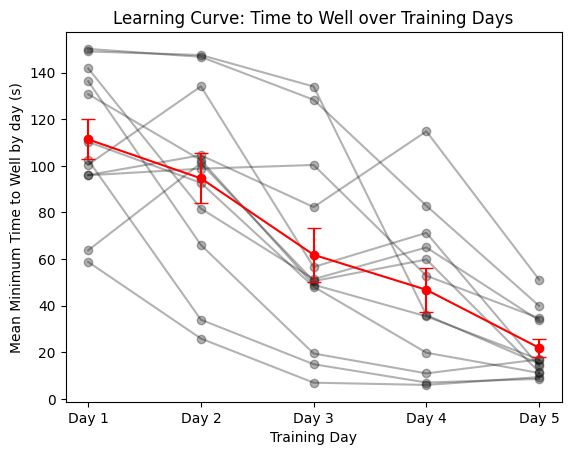

In [ ]:
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
    ].reset_index(drop=True)

performance_mat = []
for sub in metadata_L['sub'].unique():
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['t_to_trigger'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day/1000, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance/1000, yerr=sem_performance/1000, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (s)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])



############################################################
TIME-TO-FIRST-REWARD ANALYSIS
Using: t_to_trigger (all visits)
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Groups used for plotting/stats: ['eYFP_ChR2', 'eYFP_ArchT']
Original genotypes loaded: ['eYFP_ArchT', 'eYFP_ChR2']
Custom IDs loaded: []

Custom groups requested:
  None

Rows after filtering:
     sub id genotype_original    genotype trial_type  trial_type_day  ses  \
0     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
1     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
2     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
3     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
4     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
..   ... ..               ...         ...        ...             ...  ...   
445   39  P        eYFP_ArchT  eYFP_ArchT          L               5

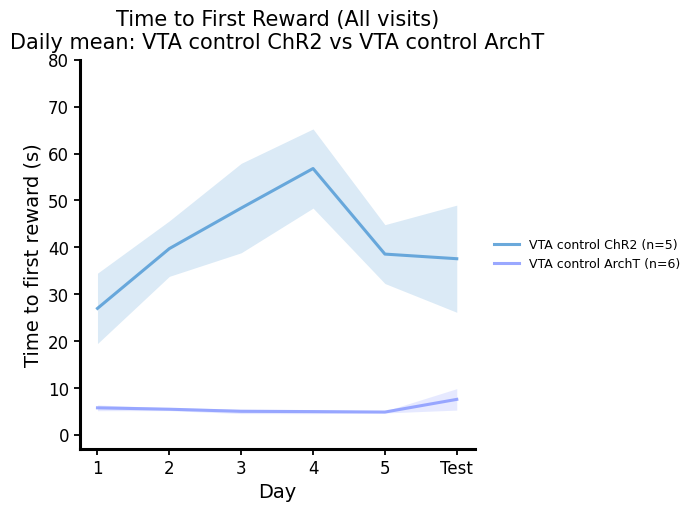


Boxplot: Learning days 1-5 average
Using: t_to_trigger (all visits)
Day value mode: daily_mean
Animals plotted:
  VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
  VTA control ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']

Per-animal values:
         group  sub  id    value_s
0    eYFP_ChR2   19   E  31.800321
1    eYFP_ChR2   20  EE  35.990075
2    eYFP_ChR2   21  EF  39.374525
3    eYFP_ChR2   22   F  54.359775
4    eYFP_ChR2   23   G  48.973750
5   eYFP_ArchT   34   M   5.489600
6   eYFP_ArchT   35  MA   4.526700
7   eYFP_ArchT   36  MB   5.116775
8   eYFP_ArchT   37   N   5.034675
9   eYFP_ArchT   38   O   5.563100
10  eYFP_ArchT   39   P   5.679150

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, U=30.0, p=0.00433


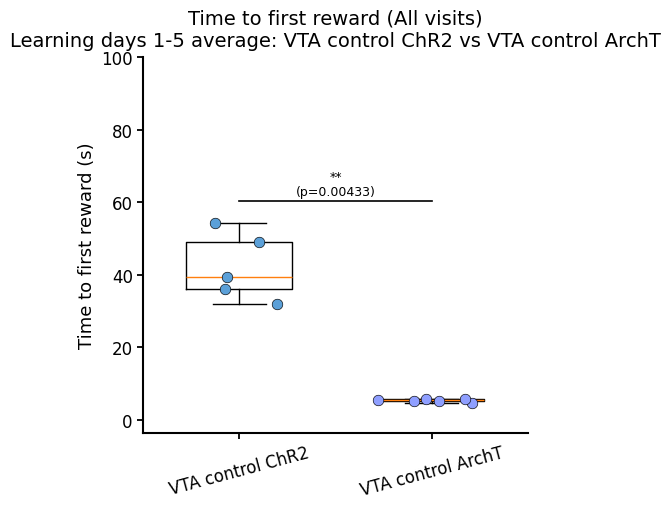


Boxplot: Test day
Using: t_to_trigger (all visits)
Day value mode: daily_mean
Animals plotted:
  VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
  VTA control ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']

Per-animal values:
         group  sub  id  value_s
0    eYFP_ChR2   19   E   63.505
1    eYFP_ChR2   20  EE   25.393
2    eYFP_ChR2   21  EF    2.288
3    eYFP_ChR2   22   F   60.846
4    eYFP_ChR2   23   G   35.881
5   eYFP_ArchT   34   M    7.410
6   eYFP_ArchT   35  MA   17.146
7   eYFP_ArchT   36  MB    7.525
8   eYFP_ArchT   37   N    4.339
9   eYFP_ArchT   38   O    0.270
10  eYFP_ArchT   39   P    8.837

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, U=25.0, p=0.08225


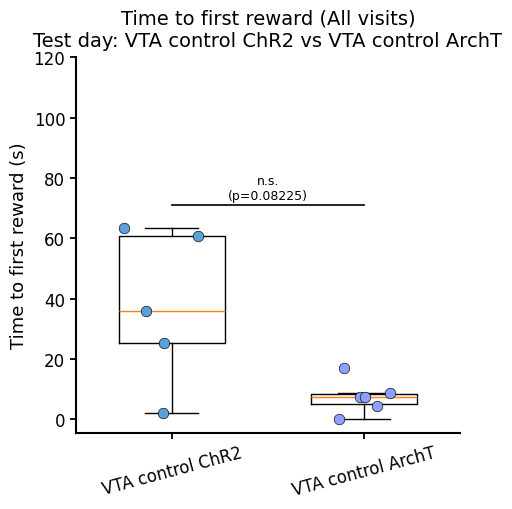



############################################################
TIME-TO-FIRST-REWARD ANALYSIS
Using: t_to_trigger_long (>2 s stay)
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Groups used for plotting/stats: ['eYFP_ChR2', 'eYFP_ArchT']
Original genotypes loaded: ['eYFP_ArchT', 'eYFP_ChR2']
Custom IDs loaded: []

Custom groups requested:
  None

Rows after filtering:
     sub id genotype_original    genotype trial_type  trial_type_day  ses  \
0     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
1     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
2     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
3     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
4     19  E         eYFP_ChR2   eYFP_ChR2          L               1    4   
..   ... ..               ...         ...        ...             ...  ...   
445   39  P        eYFP_ArchT  eYFP_ArchT          L            

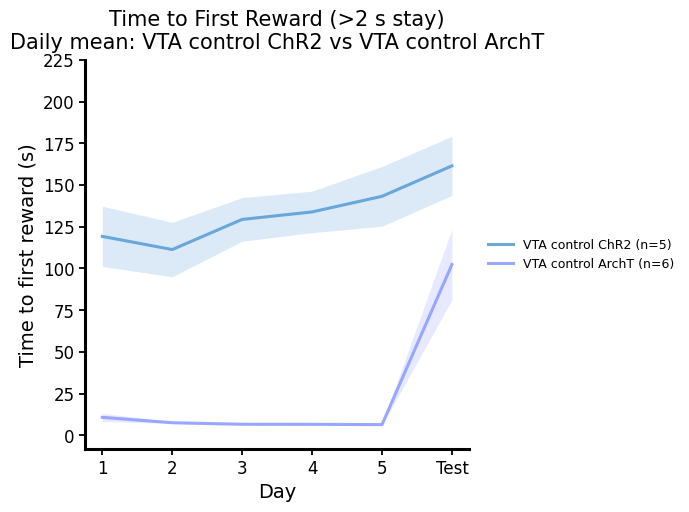


Boxplot: Learning days 1-5 average
Using: t_to_trigger_long (>2 s stay)
Day value mode: daily_mean
Animals plotted:
  VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
  VTA control ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']

Per-animal values:
         group  sub  id     value_s
0    eYFP_ChR2   19   E  121.802611
1    eYFP_ChR2   20  EE  142.666350
2    eYFP_ChR2   21  EF  165.072775
3    eYFP_ChR2   22   F  113.335150
4    eYFP_ChR2   23   G   94.007600
5   eYFP_ArchT   34   M    8.776750
6   eYFP_ArchT   35  MA    5.926925
7   eYFP_ArchT   36  MB    6.714275
8   eYFP_ArchT   37   N    7.894525
9   eYFP_ArchT   38   O    9.550425
10  eYFP_ArchT   39   P    6.527200

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, U=30.0, p=0.00433


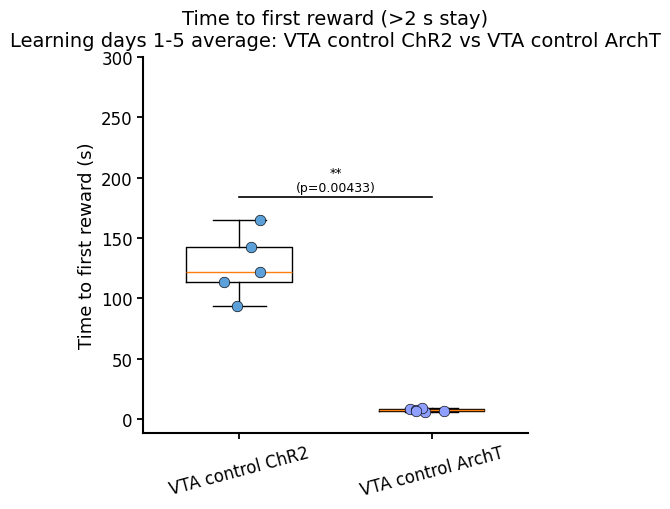


Boxplot: Test day
Using: t_to_trigger_long (>2 s stay)
Day value mode: daily_mean
Animals plotted:
  VTA control ChR2 (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
  VTA control ArchT (eYFP_ArchT): n = 6, ids = ['M', 'MA', 'MB', 'N', 'O', 'P']

Per-animal values:
         group  sub  id  value_s
0    eYFP_ChR2   19   E  197.084
1    eYFP_ChR2   20  EE  101.325
2    eYFP_ChR2   21  EF  180.073
3    eYFP_ChR2   22   F  186.919
4    eYFP_ChR2   23   G  141.826
5   eYFP_ArchT   34   M   25.748
6   eYFP_ArchT   35  MA   87.103
7   eYFP_ArchT   36  MB   83.140
8   eYFP_ArchT   37   N  151.453
9   eYFP_ArchT   38   O  169.323
10  eYFP_ArchT   39   P   97.318

Mann–Whitney U tests:
  VTA control ChR2 vs VTA control ArchT: n=5 vs 6, U=26.0, p=0.05195


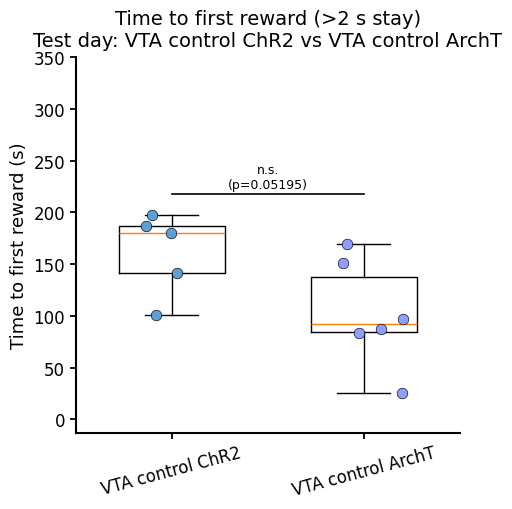

In [347]:
# ============================================================
# Time to first reward across L1-L5 + Test
#
# Runs BOTH arrival definitions:
#   1) t_to_trigger      -> all visits
#   2) t_to_trigger_long -> >2 s stay
#
# Adds pooled control group:
#   'Control' = eYFP_ChR2 + CA1_control + NAc_control
#
# Adds custom ID-based groups:
#   short_1 = AI, AJ, AL
#   short_2 = V1, V2, V3, V4, V5
#
# Important behaviour:
#   GROUPS = ['ChR2_short']
#       -> keeps all ChR2_short animals together.
#
#   GROUPS = ['short_1', 'short_2']
#       -> splits AI/AJ/AL and V1-V5 into custom groups.
#
#   GROUPS = ['ChR2_short', 'short_1', 'short_2']
#       -> short_1/short_2 animals are split out,
#          remaining ChR2_short animals stay in ChR2_short.
#
# Produces FOR EACH arrival definition:
#   1) Line plot across L1-L5 + Test
#   2) Boxplot: learning days 1-5 average
#   3) Boxplot: test day
#
# DAY_VALUE_MODE:
#   'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   'first_trial'
#       learning days = first trial only from each learning day
#       test day      = first test trial only
#
# IMPORTANT:
#   short_duration is NOT filtered anywhere in this code.
#
# Requires metadata columns from your computing code:
#   metadata['t_to_trigger']
#   metadata['t_to_trigger_long']
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

# ------------------------------------------------------------
# Run both time-to-trigger definitions
# ------------------------------------------------------------

ARRIVAL_VERSIONS_TO_PLOT = [
    {
        'time_col': 't_to_trigger',
        'stay_tag': 'all visits',
        'title_tag': 'All visits',
    },
    {
        'time_col': 't_to_trigger_long',
        'stay_tag': '>2 s stay',
        'title_tag': '>2 s stay',
    },
]

PLOT_INDIVIDUAL = False         # True -> faded individual animal lines
REQUIRE_COMPLETE = False        # True -> only animals with all L1-L5 + Test
SHOW_ANIMAL_IDS = False         # True -> label each dot with animal ID

# How to compute one value per animal per day:
#   'daily_mean'  = average across all available trials that day
#   'first_trial' = trial 1 only
DAY_VALUE_MODE = 'daily_mean'
# DAY_VALUE_MODE = 'first_trial'

# Example group choices:
# GROUPS = ['Control']
# GROUPS = ['ChR2', 'Control']
# GROUPS = ['ChR2_short']
# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2']
# GROUPS = ['ChR2_short', 'short_1', 'short_2']
# GROUPS = ['ChR2_short', 'CA1', 'CA3', 'Control']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['F231A', 'F231A_wt']
# GROUPS = ['short_1', 'short_2']
# GROUPS = ['short_1', 'short_2', 'ChR2']
# GROUPS = ['short_1', 'short_2', 'ChR2', 'eYFP_ChR2']
GROUPS = ['eYFP_ChR2', 'eYFP_ArchT']


# ------------------------------------------------------------
# Custom ID-based groups
# ------------------------------------------------------------

CUSTOM_GROUP_ID_MAP = {
    'short_1': ['AI', 'AJ', 'AL'],
    'short_2': ['V1', 'V2', 'V3', 'V4', 'V5'],
}

# Usually these animals are ChR2_short.
# Set a value to None to load that custom group by ID regardless of genotype.
CUSTOM_GROUP_GENOTYPE_SOURCE = {
    'short_1': 'ChR2_short',
    'short_2': 'ChR2_short',
}

# These original genotypes will be pooled into displayed/statistical group 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = [
    'eYFP_ChR2',
    'CA1_control',
    'NAc_control',
]

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control ChR2',
    'ChR2_short': 'VTA short',
    'short_1': 'Short 1',
    'short_2': 'Short 2',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
    'WT': 'WT',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'VTA control ArchT',
}

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

# Between-group boxplot comparisons
COMPARISONS = 'all'
# COMPARISONS = [('short_1', 'short_2')]
# COMPARISONS = [('short_1', 'ChR2'), ('short_2', 'ChR2')]
# COMPARISONS = [('ChR2_short', 'eYFP_ChR2')]


# ------------------------------------------------------------
# Figure sizes
# ------------------------------------------------------------

LINE_FIGSIZE = (8.5, 5.5)
BOX_FIGSIZE_BASE = (4.8, 5.2)


# ------------------------------------------------------------
# Boxplot dot/stat options
# ------------------------------------------------------------

JITTER = 0.12
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45
P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.40
P_TEXT_OFFSET_FRAC = 0.015
P_TOP_PAD_FRAC = 0.25


# ------------------------------------------------------------
# Line plot y-axis options
# ------------------------------------------------------------
# LINE_YMIN = None:
#   automatic small padding below 0, so 0 is visibly above the x-axis.
#
# LINE_YMIN = 0:
#   axis starts exactly at zero.
#
# LINE_YMAX = None:
#   automatic top limit independently for each plotted figure.
#
# Example fixed axis for both versions:
#   LINE_YMAX = 200
#   LINE_Y_TICK_STEP = 50

LINE_YMIN = None
LINE_YMAX = None
LINE_Y_BOTTOM_PAD_FRAC = 0.04
LINE_Y_TOP_PAD_FRAC = 0.15
LINE_Y_TICK_STEP = None


# ------------------------------------------------------------
# Boxplot y-axis options
# ------------------------------------------------------------
# BOX_YMIN = None:
#   automatic small padding below 0.
#
# BOX_YMIN = 0:
#   axis starts exactly at zero.

BOX_YMIN = None
BOX_YMAX = None
BOX_Y_BOTTOM_PAD_FRAC = 0.04
BOX_Y_TICK_STEP = None


# ------------------------------------------------------------
# General plot-day settings
# ------------------------------------------------------------

plot_days = np.arange(1, 7)
x_vals = plot_days - 1
plot_day_labels = ['1', '2', '3', '4', '5', 'Test']

np.random.seed(1)

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


# ============================================================
# Helper functions: custom groups
# ============================================================

def is_custom_group(group_name):
    return group_name in CUSTOM_GROUP_ID_MAP


def get_plot_color(group_name):
    """
    Uses your existing get_genotype_color() function.

    For custom short_1 / short_2 groups, falls back to the
    ChR2_short colour when no dedicated colour exists.
    """
    try:
        return get_genotype_color(group_name)
    except Exception:
        if group_name in ['short_1', 'short_2']:
            return get_genotype_color('ChR2_short')
        raise


def add_analysis_group(meta_df):
    """
    Adds analysis_group.

    Default:
      analysis_group = genotype

    Custom ID groups:
      Animals with IDs in CUSTOM_GROUP_ID_MAP are assigned to
      short_1, short_2, etc. only when that custom group is in GROUPS.

    Therefore:
      GROUPS = ['ChR2_short']
          keeps all ChR2_short animals together.

      GROUPS = ['short_1', 'short_2']
          splits specified animals into custom groups.

      GROUPS = ['ChR2_short', 'short_1', 'short_2']
          splits custom animals out while leaving remaining
          ChR2_short animals in ChR2_short.
    """
    meta_df = meta_df.copy()
    meta_df['analysis_group'] = meta_df['genotype']

    if 'id' not in meta_df.columns:
        return meta_df

    id_as_str = meta_df['id'].astype(str)

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():
        if group_name not in GROUPS:
            continue

        ids_str = [str(x) for x in ids]
        meta_df.loc[id_as_str.isin(ids_str), 'analysis_group'] = group_name

    return meta_df


# ============================================================
# General helper functions
# ============================================================

def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return 'NaN'
    return f'{p:.{decimals}f}'


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs

    return comparisons


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals,
    and custom group visible for short_1 / short_2.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'analysis_group' in ms.columns and ms['analysis_group'].notna().any():
        analysis_group = str(ms['analysis_group'].dropna().iloc[0])

        if analysis_group in CUSTOM_GROUP_ID_MAP:
            return f'{animal_id} ({DISPLAY_NAME.get(analysis_group, analysis_group)})'

    if (
        'genotype_original' in ms.columns and
        ms['genotype'].iloc[0] == 'Control'
    ):
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({DISPLAY_NAME.get(original, original)})'

    return animal_id


def style_nature(ax, linewidth=2.0):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def apply_line_y_axis(ax, all_vals):
    """
    Line-plot y-axis:
      - uses plotted mean ± SEM values
      - gives each arrival version its own appropriate y-axis
      - provides optional fixed y-limits
      - pads below zero when LINE_YMIN is None
      - displays ticks beginning at zero
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)

        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    if LINE_YMAX is not None:
        y_top = float(LINE_YMAX)
    else:
        y_top = data_top * (1 + LINE_Y_TOP_PAD_FRAC)

    if LINE_YMIN is not None:
        y_bottom = float(LINE_YMIN)
    else:
        y_bottom = -LINE_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if LINE_Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + LINE_Y_TICK_STEP, LINE_Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def apply_box_y_axis(ax, y_top):
    """
    Boxplot y-axis:
      - pads below zero when BOX_YMIN is None
      - displays ticks beginning at zero
      - includes room for p-value bars/text
    """
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    if BOX_YMAX is not None:
        y_top = float(BOX_YMAX)

    if BOX_YMIN is not None:
        y_bottom = float(BOX_YMIN)
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]

        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)

        ax.set_yticks(ticks)


def assign_learning_and_test_days(meta_df):
    """
    Assign:
      L trial_type_day 1-5 -> plot_day 1-5
      first T session after last L session -> plot_day 6
    """
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']

        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin(plot_days)].copy()

    return meta_df


def add_trial_in_day(meta_df):
    """
    Adds trial_in_day = 1..8.

    Uses an existing within-session trial-number column if present.
    Otherwise infers trial number from row order within sub/session.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def get_day_value(ms, day, value_col):
    """
    Returns one time-to-first-reward value for one animal on one plot day.

    DAY_VALUE_MODE:
      'daily_mean':
          mean across all available trials within that day

      'first_trial':
          trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna()) &
        (np.isfinite(ms[value_col]))
    ].copy()

    if len(md) == 0:
        return np.nan

    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan

        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    """
    Build animal × day matrix.

    One row = one animal.
    Columns = L1, L2, L3, L4, L5, Test.
    Values remain in the original time unit from metadata, converted
    to seconds only when plotting.
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[
        meta_group[value_col].notna() &
        np.isfinite(meta_group[value_col])
    ].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def mean_sem_by_day(mat):
    """
    Mean and SEM for each plot day, with NaN handling.
    """
    mean_vals = np.full(mat.shape[1], np.nan)
    sem_vals = np.full(mat.shape[1], np.nan)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_vals[i] = np.nanmean(vals)

        if len(vals) <= 1:
            sem_vals[i] = 0.0
        else:
            sem_vals[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return mean_vals, sem_vals


def values_from_matrix(group_key, mode, group_data):
    """
    Uses the exact same animal × day matrix as the line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = matrix columns 0:5
      'test'          -> test day = matrix column 5
    """
    mat = group_data[group_key]['mat']
    subs = group_data[group_key]['subs']
    ids = group_data[group_key]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value_s'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            valid_learning = row[0:5][np.isfinite(row[0:5])]

            if len(valid_learning) == 0:
                continue

            value_ms = np.nanmean(valid_learning)

        elif mode == 'test':
            value_ms = row[5]

        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value_ms):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value_s': float(value_ms) / 1000.0
        })

    return pd.DataFrame(rows)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    label = (
        f"{p_to_stars(p)}\n(p={format_p(p)})"
        if np.isfinite(p)
        else "p = NaN"
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# Prepare data for one arrival version
# ============================================================

def prepare_data_for_time_column(metadata_df, time_col, stay_tag):
    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        time_col,
    ]

    missing_cols = [c for c in needed_cols if c not in metadata_df.columns]

    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in metadata for '{stay_tag}': {missing_cols}\n"
            f"Make sure your computing code created metadata['{time_col}']."
        )

    groups_to_load = []
    custom_ids_to_load = []

    for group_name in GROUPS:
        if group_name == 'Control':
            groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)

        elif group_name in CUSTOM_GROUP_ID_MAP:
            custom_ids_to_load.extend(CUSTOM_GROUP_ID_MAP[group_name])

            genotype_source = CUSTOM_GROUP_GENOTYPE_SOURCE.get(group_name, None)

            if genotype_source is not None:
                groups_to_load.append(genotype_source)

        else:
            groups_to_load.append(group_name)

    groups_to_load = sorted(set(groups_to_load))
    custom_ids_to_load = sorted(set([str(x) for x in custom_ids_to_load]))

    base_mask = (
        (metadata_df['usable'] == 1) &
        (metadata_df['trial_type'].isin(['L', 'T'])) &
        (metadata_df[time_col].notna()) &
        (np.isfinite(metadata_df[time_col]))
    )

    if len(groups_to_load) > 0:
        genotype_mask = metadata_df['genotype'].isin(groups_to_load)
    else:
        genotype_mask = pd.Series(False, index=metadata_df.index)

    if len(custom_ids_to_load) > 0 and 'id' in metadata_df.columns:
        custom_id_mask = metadata_df['id'].astype(str).isin(custom_ids_to_load)
    else:
        custom_id_mask = pd.Series(False, index=metadata_df.index)

    meta_LT = metadata_df[
        base_mask &
        (genotype_mask | custom_id_mask)
    ].copy()

    # Store original genotype before pooling/custom reassignment.
    meta_LT['genotype_original'] = meta_LT['genotype']

    # Pool controls into one displayed/statistical group.
    if 'Control' in GROUPS:
        meta_LT.loc[
            meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
            'genotype'
        ] = 'Control'

    # Add optional custom analysis groups.
    meta_LT = add_analysis_group(meta_LT)

    # Use analysis_group as the active plotting/statistical group.
    meta_LT['genotype'] = meta_LT['analysis_group']

    # Keep only requested displayed groups.
    meta_LT = meta_LT[meta_LT['genotype'].isin(GROUPS)].copy()

    # Do not accidentally exclude custom animals if their IDs are
    # deliberately requested in custom groups.
    exclude_ids_effective = [
        x for x in EXCLUDE_ID
        if str(x) not in custom_ids_to_load
    ]

    if len(exclude_ids_effective) > 0 and 'id' in meta_LT.columns:
        meta_LT = meta_LT[
            ~meta_LT['id'].astype(str).isin([str(x) for x in exclude_ids_effective])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta_LT = meta_LT[
            ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    meta_LT = assign_learning_and_test_days(meta_LT)
    meta_LT, trial_col_used = add_trial_in_day(meta_LT)

    print("\n\n############################################################")
    print("TIME-TO-FIRST-REWARD ANALYSIS")
    print("Using:", time_col, f"({stay_tag})")
    print("Day value mode:", DAY_VALUE_MODE)
    print(
        "Trial column used:",
        trial_col_used if trial_col_used is not None else "inferred from sub/ses order"
    )
    print("Groups used for plotting/stats:", GROUPS)
    print("Original genotypes loaded:", groups_to_load)
    print("Custom IDs loaded:", custom_ids_to_load)

    if 'Control' in GROUPS:
        print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

    print("\nCustom groups requested:")
    any_custom = False

    for group_name, ids in CUSTOM_GROUP_ID_MAP.items():
        if group_name in GROUPS:
            any_custom = True
            print(
                f"  {group_name}: {ids}, "
                f"colour = get_genotype_color('{group_name}') "
                f"or ChR2_short fallback"
            )

    if not any_custom:
        print("  None")

    print("\nRows after filtering:")

    cols_to_print = ['sub']

    if 'id' in meta_LT.columns:
        cols_to_print.append('id')

    if 'genotype_original' in meta_LT.columns:
        cols_to_print.append('genotype_original')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'plot_day',
        'trial_in_day',
        time_col,
    ]

    if len(meta_LT) > 0:
        print(
            meta_LT[cols_to_print]
            .drop_duplicates()
            .sort_values(cols_to_print)
            .reset_index(drop=True)
        )
    else:
        print("No rows left after filtering.")

    return meta_LT, trial_col_used


# ============================================================
# Build matrices for one arrival version
# ============================================================

def build_all_group_matrices(meta_LT, time_col):
    group_data = {}

    print("\nAnimals included:")

    for group_name in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == group_name].copy()

        mat_g, subs_g, ids_g = build_genotype_matrix(
            meta_group=meta_g,
            value_col=time_col
        )

        group_data[group_name] = {
            'meta': meta_g,
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"  {DISPLAY_NAME.get(group_name, group_name)} ({group_name})")
        print(f"    animals in dataset: {meta_g['sub'].nunique()}")
        print(f"    animals plotted:    {len(subs_g)}")
        print(f"    ids plotted:        {ids_g}")

    return group_data


# ============================================================
# Line plot for one arrival version
# ============================================================

def plot_group_shaded(
    ax,
    mat,
    subs,
    genotype_key,
    label,
    alpha_fill=0.22,
    alpha_line=0.9,
    alpha_individual=0.12
):
    """
    Plot one group's mean ± SEM line.

    Returns plotted y-values in seconds for automatic y-axis selection.
    Axis values are based on mean ± SEM, plus individual traces when shown.
    """
    if mat is None or len(subs) == 0:
        return []

    col = get_plot_color(genotype_key)
    plotted_y = []

    if PLOT_INDIVIDUAL:
        for row in mat:
            row_s = row / 1000.0

            ax.plot(
                x_vals,
                row_s,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

            plotted_y.extend(row_s[np.isfinite(row_s)])

    mean_ms, sem_ms = mean_sem_by_day(mat)

    mean_s = mean_ms / 1000.0
    sem_s = sem_ms / 1000.0

    valid_band = np.isfinite(mean_s) & np.isfinite(sem_s)

    if np.any(valid_band):
        plotted_y.extend((mean_s - sem_s)[valid_band])
        plotted_y.extend((mean_s + sem_s)[valid_band])

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    return plotted_y


def plot_line_across_days(group_data, stay_tag, title_tag):
    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    all_line_y = []

    for group_name in GROUPS:
        all_line_y.extend(
            plot_group_shaded(
                ax=ax,
                mat=group_data[group_name]['mat'],
                subs=group_data[group_name]['subs'],
                genotype_key=group_name,
                label=DISPLAY_NAME.get(group_name, group_name)
            )
        )

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward (s)', fontsize=14)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(plot_day_labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax, linewidth=2.2)

    if DAY_VALUE_MODE == 'first_trial':
        value_mode_title = 'First trial only'
    else:
        value_mode_title = 'Daily mean'

    display_groups = ' vs '.join([
        DISPLAY_NAME.get(group_name, group_name)
        for group_name in GROUPS
    ])

    ax.set_title(
        f'Time to First Reward ({title_tag})\n'
        f'{value_mode_title}: {display_groups}',
        fontsize=15,
        pad=8
    )

    handles, legend_labels = ax.get_legend_handles_labels()

    if len(handles) > 0:
        ax.legend(
            frameon=False,
            fontsize=9,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5)
        )

    apply_line_y_axis(ax, all_line_y)

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ============================================================
# Boxplot for one arrival version
# ============================================================

def plot_boxplot_from_matrix(group_data, time_col, stay_tag, title_tag, mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for group_name in GROUPS:
        df_g = values_from_matrix(
            group_key=group_name,
            mode=mode,
            group_data=group_data
        )

        group_dfs[group_name] = df_g
        vals_groups.append(df_g['value_s'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Using: {time_col} ({stay_tag})")
    print(f"Day value mode: {DAY_VALUE_MODE}")
    print("Animals plotted:")

    for group_name in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(group_name, group_name)} ({group_name}): "
            f"n = {len(group_dfs[group_name])}, "
            f"ids = {list(group_dfs[group_name]['id'])}"
        )

    print("\nPer-animal values:")

    if any(len(group_dfs[group_name]) > 0 for group_name in GROUPS):
        meta_animal = pd.concat(
            [
                group_dfs[group_name].assign(group=group_name)
                for group_name in GROUPS
                if len(group_dfs[group_name]) > 0
            ],
            ignore_index=True
        )

        print(meta_animal[['group', 'sub', 'id', 'value_s']])

    else:
        print("No data.")

    fig_width = max(BOX_FIGSIZE_BASE[0], 1.4 * len(GROUPS))
    fig, ax = plt.subplots(figsize=(fig_width, BOX_FIGSIZE_BASE[1]))

    positions = np.arange(len(GROUPS))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, group_name in enumerate(GROUPS):
        df_g = group_dfs[group_name]
        vals = df_g['value_s'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(group_name),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(group_name),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    comparisons_to_run = get_comparisons(GROUPS, COMPARISONS)
    stats_to_draw = []

    print("\nMann–Whitney U tests:")

    for group_1, group_2 in comparisons_to_run:
        if group_1 not in GROUPS or group_2 not in GROUPS:
            print(
                f"  Skipping {DISPLAY_NAME.get(group_1, group_1)} vs "
                f"{DISPLAY_NAME.get(group_2, group_2)}: group not in GROUPS"
            )
            continue

        vals_1 = group_dfs[group_1]['value_s'].values.astype(float)
        vals_2 = group_dfs[group_2]['value_s'].values.astype(float)

        vals_1 = vals_1[np.isfinite(vals_1)]
        vals_2 = vals_2[np.isfinite(vals_2)]

        if len(vals_1) > 0 and len(vals_2) > 0:
            stat, p = mannwhitneyu(vals_1, vals_2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        if np.isfinite(p):
            print(
                f"  {DISPLAY_NAME.get(group_1, group_1)} vs "
                f"{DISPLAY_NAME.get(group_2, group_2)}: "
                f"n={len(vals_1)} vs {len(vals_2)}, "
                f"U={stat:.1f}, p={format_p(p)}"
            )

            x1 = GROUPS.index(group_1)
            x2 = GROUPS.index(group_2)
            stats_to_draw.append((x1, x2, p))

        else:
            print(
                f"  {DISPLAY_NAME.get(group_1, group_1)} vs "
                f"{DISPLAY_NAME.get(group_2, group_2)}: p = NaN"
            )

    nonempty_vals = [
        vals[np.isfinite(vals)]
        for vals in vals_groups
        if len(vals) > 0 and np.any(np.isfinite(vals))
    ]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        current_y = ymax + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        for x1, x2, p in stats_to_draw:
            draw_sig_bar(ax, x1, x2, current_y, p, yrng)
            current_y += y_step

        y_top_auto = current_y + P_TOP_PAD_FRAC * yrng
        apply_box_y_axis(ax, y_top_auto)

    else:
        apply_box_y_axis(ax, 1.0)

    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(group_name, group_name) for group_name in GROUPS],
        fontsize=12,
        rotation=15
    )

    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax, linewidth=1.5)

    display_groups = ' vs '.join([
        DISPLAY_NAME.get(group_name, group_name)
        for group_name in GROUPS
    ])

    ax.set_title(
        f'Time to first reward ({title_tag})\n'
        f'{title_suffix}: {display_groups}',
        fontsize=14,
        pad=8
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Run complete analysis for one arrival definition
# ============================================================

def run_complete_analysis_for_arrival_version(metadata_df, time_col, stay_tag, title_tag):
    meta_LT, trial_col_used = prepare_data_for_time_column(
        metadata_df=metadata_df,
        time_col=time_col,
        stay_tag=stay_tag
    )

    if len(meta_LT) == 0:
        print(f"\nNo data available for {time_col} ({stay_tag}). Skipping plots.")
        return

    group_data = build_all_group_matrices(
        meta_LT=meta_LT,
        time_col=time_col
    )

    # --------------------------------------------------------
    # 1) Line plot: L1-L5 + Test
    # --------------------------------------------------------
    plot_line_across_days(
        group_data=group_data,
        stay_tag=stay_tag,
        title_tag=title_tag
    )

    # --------------------------------------------------------
    # 2) Boxplot: learning days 1-5 average
    # --------------------------------------------------------
    plot_boxplot_from_matrix(
        group_data=group_data,
        time_col=time_col,
        stay_tag=stay_tag,
        title_tag=title_tag,
        mode='learning_mean',
        title_suffix='Learning days 1-5 average'
    )

    # --------------------------------------------------------
    # 3) Boxplot: test day
    # --------------------------------------------------------
    plot_boxplot_from_matrix(
        group_data=group_data,
        time_col=time_col,
        stay_tag=stay_tag,
        title_tag=title_tag,
        mode='test',
        title_suffix='Test day'
    )


# ============================================================
# Run BOTH: all visits and >2 s stay
# ============================================================

for arrival_version in ARRIVAL_VERSIONS_TO_PLOT:
    run_complete_analysis_for_arrival_version(
        metadata_df=metadata,
        time_col=arrival_version['time_col'],
        stay_tag=arrival_version['stay_tag'],
        title_tag=arrival_version['title_tag']
    )

Group plotted: ArchT (ArchT)
Using column: t_to_trigger
Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 6
  Day 2 best -> Day 3 trial 1: n = 6
  Day 3 best -> Day 4 trial 1: n = 6
  Day 4 best -> Day 5 trial 1: n = 6
  Day 5 best -> Test trial 1: n = 6


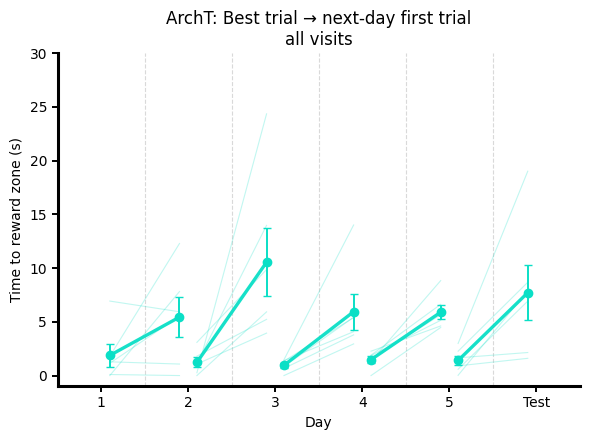

In [ ]:
# ============================================================
# Flexible genotype:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: time to reward zone
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
#
# IMPORTANT:
# For time-to-trigger, "best trial" = SMALLEST time
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'ArchT'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control'
PLOT_INDIVIDUAL = True        # False -> only mean ± SEM
USE_LONG_VISITS = False        # False -> t_to_trigger ; True -> t_to_trigger_long

EXCLUDE_ID = ['AN','BQ','BP']               # e.g. ['AS']
EXCLUDE_SUBS = []             # e.g. [43]

FILTER_SHORT_DURATION = False # True -> apply short_duration != 1
                              # False -> no short_duration filter

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_LABEL = 'Time to reward zone (s)'
TITLE_SUFFIX = 'long visits only (≥2 s)' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = MIN time within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, best_val, first_val
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'best_val', 'first_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        # mean per trial if duplicates exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        best_val = np.nanmin(by_trial.values)   # smaller time = better
        first_val = by_trial.get(1, np.nan)

        rows.append({
            'sub': sub,
            'best_val': best_val,
            'first_val': first_val
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best -> day d+1 first
# ------------------------------------------------------------
transitions = []

for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = (
        per_subject_day_values(meta_LT, d_prev, TIME_COL)[['sub', 'best_val']]
        .rename(columns={'best_val': 'y_prev'})
    )

    next_df = (
        per_subject_day_values(meta_LT, d_next, TIME_COL)[['sub', 'first_val']]
        .rename(columns={'first_val': 'y_next'})
    )

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

print(f"Group plotted: {GROUP_LABEL} ({GENOTYPE_TO_PLOT})")
print(f"Using column: {TIME_COL}")
print("Animals included per transition:")

for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'
    print(f"  Day {d_prev} best -> {nxt_label} trial 1: n = {n}")

# ------------------------------------------------------------
# 6) Plot helper
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color(GENOTYPE_TO_PLOT)

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

all_y_s = []

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    # --------------------------------------------------------
    # 1) Individual animal lines
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            y_prev_s = row['y_prev'] / 1000.0
            y_next_s = row['y_next'] / 1000.0

            ax.plot(
                [x_prev, x_next],
                [y_prev_s, y_next_s],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

            all_y_s.extend([y_prev_s, y_next_s])

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    y_prev = df_tr['y_prev'].values / 1000.0
    y_next = df_tr['y_next'].values / 1000.0

    all_y_s.extend(list(y_prev) + list(y_next))

    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    ax.errorbar(
        x_prev,
        m_prev,
        yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next,
        m_next,
        yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel(TIME_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: Best trial → next-day first trial\n'
    f'{TITLE_SUFFIX}',
    fontsize=12
)

if len(all_y_s) > 0:
    ymax = np.nanmax(all_y_s)

    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    # Padding below zero so low values do not sit on the x-axis
    Y_ZERO_PAD_FRAC = 0.04
    ax.set_ylim(-Y_ZERO_PAD_FRAC * ymax, ymax * 1.15)

    # Keep tick labels starting from 0
    yticks = ax.get_yticks()
    yticks = yticks[yticks >= 0]
    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)
    ax.set_yticks(yticks)

style_nature(ax)
plt.tight_layout()
plt.show()

Using genotype: eYFP_ArchT (eYFP_ArchT)
Using column: t_to_trigger
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included per within-day comparison:
  Day 1: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 2: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 3: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 4: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Day 5: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']
  Test: n = 6, animals = ['M', 'MA', 'MB', 'N', 'O', 'P']

Wilcoxon signed-rank tests: first trial vs best trial of same day
Alternative used: two-sided
Test day is plotted as one dot only and is not tested.
  Day 1: n = 6, first mean = 7.764 s, best mean = 0.830 s, median diff best-first = -6.907 s, W = 0.000, p = 0.04311
  Day 2: n = 6, first mean = 6.133 s, best mean = 1.075 s, median diff best-first = -3.917 s, W = 0.000, p = 0.03125
  Day 3: n = 6, first mean = 7.639 s, best mean = 0.998 s, median 

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


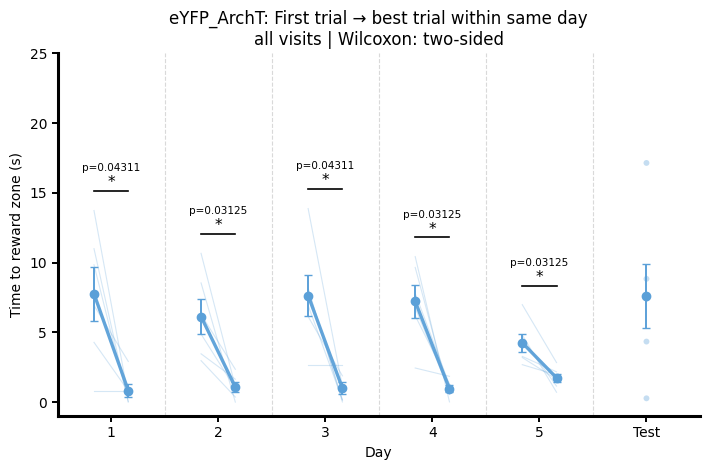

In [ ]:
# ============================================================
# Flexible genotype:
# Plot "first trial of each day" -> "best trial of same day"
# Metric: time to reward zone
#
# Within-day progress:
#   Day 1 trial 1 -> Day 1 best trial
#   Day 2 trial 1 -> Day 2 best trial
#   Day 3 trial 1 -> Day 3 best trial
#   Day 4 trial 1 -> Day 4 best trial
#   Day 5 trial 1 -> Day 5 best trial
#
# Test day:
#   only one trial, so it is plotted as one dot only
#   no paired line / Wilcoxon test for Test
#
# IMPORTANT:
# For time-to-trigger, "best trial" = SMALLEST time
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
#   alternative='less' tests whether best trial < first trial
#   alternative='two-sided' tests whether first and best are different
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'eYFP_ArchT'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control'
PLOT_INDIVIDUAL = True        # False -> only mean ± SEM
USE_LONG_VISITS = False        # False -> t_to_trigger ; True -> t_to_trigger_long

EXCLUDE_ID = ['AN','BQ','BP']               # e.g. ['AS']
EXCLUDE_SUBS = []             # e.g. [43]

# Wilcoxon:
# 'less' = tests whether best trial time < first trial time
# 'two-sided' = tests whether first and best are different
WILCOXON_ALTERNATIVE = 'two-sided'

SHOW_P_VALUES = True
SHOW_STARS = True
P_DECIMALS = 5

# x-axis positioning
X_FIRST_OFFSET = -0.16
X_BEST_OFFSET  =  0.16

# p-value annotation spacing
P_LINE_FRAC_ABOVE = 0.08
P_STAR_FRAC_ABOVE = 0.004   # smaller = star closer to horizontal line
P_TEXT_FRAC_ABOVE = 0.075

# y-axis
YMIN = None          # None -> slightly below 0
YMAX = 25          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_LABEL = 'Time to reward zone (s)'
TITLE_SUFFIX = 'long visits only (≥2 s)' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", TIME_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) For each animal and day:
#    - first trial = trial_in_day == 1
#    - best trial = MIN time within that day
# ------------------------------------------------------------
def per_subject_day_first_best(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, id, first_val, best_val

    For time-to-trigger:
      best_val = minimum time within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'first_val', 'best_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        first_val = by_trial.get(1, np.nan)
        best_val = np.nanmin(by_trial.values.astype(float))  # smaller time = better

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'first_val': float(first_val),
            'best_val': float(best_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build within-day comparison values
# ------------------------------------------------------------
within_day = []

for d in plot_days:
    df_d = per_subject_day_first_best(meta_LT, d, TIME_COL)

    within_day.append({
        'day': d,
        'df': df_d
    })

print("\nAnimals included per within-day comparison:")
for wd in within_day:
    d = wd['day']
    df_d = wd['df']
    day_label = 'Test' if d == 6 else f'Day {d}'
    print(
        f"  {day_label}: n = {len(df_d)}, "
        f"animals = {list(df_d['id']) if len(df_d) > 0 else []}"
    )

# ------------------------------------------------------------
# 6) Stats + plotting helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def run_wilcoxon_paired(first_vals, best_vals, alternative='less'):
    """
    Paired Wilcoxon signed-rank test.

    For time-to-reward:
      alternative='less' tests whether best_vals < first_vals.
      alternative='two-sided' tests whether best_vals != first_vals.

    If all differences are zero, scipy raises an error;
    in that case return p=1.
    """
    first_vals = np.asarray(first_vals, float)
    best_vals = np.asarray(best_vals, float)

    ok = np.isfinite(first_vals) & np.isfinite(best_vals)
    first_vals = first_vals[ok]
    best_vals = best_vals[ok]

    if len(first_vals) == 0:
        return np.nan, np.nan

    diffs = best_vals - first_vals

    if np.allclose(diffs, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(
            best_vals,
            first_vals,
            alternative=alternative,
            zero_method='wilcox'
        )
    except ValueError:
        stat, p = np.nan, np.nan

    return stat, p


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Run stats first
#    Test day is skipped because it usually has only one trial.
# ------------------------------------------------------------
print("\nWilcoxon signed-rank tests: first trial vs best trial of same day")
print(f"Alternative used: {WILCOXON_ALTERNATIVE}")
print("Test day is plotted as one dot only and is not tested.")

stats_results = {}

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': len(df_d)
        }
        print(f"  {day_label}: n = {len(df_d)}, no test")
        continue

    if len(df_d) == 0:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': 0
        }
        print(f"  {day_label}: n = 0, p = NaN")
        continue

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    stat, p = run_wilcoxon_paired(
        first_vals,
        best_vals,
        alternative=WILCOXON_ALTERNATIVE
    )

    stats_results[d] = {
        'stat': stat,
        'p': p,
        'n': len(df_d)
    }

    print(
        f"  {day_label}: "
        f"n = {len(df_d)}, "
        f"first mean = {np.nanmean(first_vals) / 1000.0:.3f} s, "
        f"best mean = {np.nanmean(best_vals) / 1000.0:.3f} s, "
        f"median diff best-first = {np.nanmedian((best_vals - first_vals) / 1000.0):.3f} s, "
        f"W = {stat:.3f}, "
        f"p = {format_p(p, P_DECIMALS)}"
        if np.isfinite(p)
        else
        f"  {day_label}: n = {len(df_d)}, p = NaN"
    )

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))

col = get_genotype_color(GENOTYPE_TO_PLOT)

all_y_for_ylim = []

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    if len(df_d) == 0:
        continue

    # --------------------------------------------------------
    # Test day:
    # only plot single trial/best point, no paired line/stat
    # dots remain
    # --------------------------------------------------------
    if d == 6:
        x_test = d

        test_vals_s = df_d['first_val'].values.astype(float) / 1000.0
        test_vals_s = test_vals_s[np.isfinite(test_vals_s)]

        all_y_for_ylim.extend(test_vals_s)

        if len(test_vals_s) == 0:
            continue

        if PLOT_INDIVIDUAL:
            ax.scatter(
                np.full(len(test_vals_s), x_test),
                test_vals_s,
                color=col,
                s=18,
                alpha=0.35,
                edgecolor='none',
                zorder=2
            )

        m_test, s_test = mean_sem(test_vals_s)

        ax.errorbar(
            x_test,
            m_test,
            yerr=s_test,
            fmt='o',
            color=col,
            markersize=6,
            capsize=3,
            linewidth=1.4,
            zorder=5
        )

        continue

    x_first = d + X_FIRST_OFFSET
    x_best  = d + X_BEST_OFFSET

    first_vals_s = df_d['first_val'].values.astype(float) / 1000.0
    best_vals_s = df_d['best_val'].values.astype(float) / 1000.0

    all_y_for_ylim.extend(first_vals_s[np.isfinite(first_vals_s)])
    all_y_for_ylim.extend(best_vals_s[np.isfinite(best_vals_s)])

    # --------------------------------------------------------
    # 1) Individual animal paired lines only
    #    No individual dots for learning days 1-5
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_d.iterrows():
            y_first_s = row['first_val'] / 1000.0
            y_best_s = row['best_val'] / 1000.0

            ax.plot(
                [x_first, x_best],
                [y_first_s, y_best_s],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    m_first, s_first = mean_sem(first_vals_s)
    m_best, s_best = mean_sem(best_vals_s)

    ax.plot(
        [x_first, x_best],
        [m_first, m_best],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=4
    )

    ax.errorbar(
        x_first,
        m_first,
        yerr=s_first,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

    ax.errorbar(
        x_best,
        m_best,
        yerr=s_best,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

# ------------------------------------------------------------
# 9) Add p-value bars after determining y scale
# ------------------------------------------------------------
if len(all_y_for_ylim) > 0:
    y_data_max = np.nanmax(all_y_for_ylim)
    y_data_min = np.nanmin(all_y_for_ylim)

    yrng = y_data_max - y_data_min
    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(y_data_max), 1.0)

    for wd in within_day:
        d = wd['day']
        df_d = wd['df']

        # Skip test day
        if d == 6:
            continue

        if len(df_d) == 0:
            continue

        x_first = d + X_FIRST_OFFSET
        x_best  = d + X_BEST_OFFSET
        x_mid = (x_first + x_best) / 2

        local_vals_s = np.r_[
            df_d['first_val'].values.astype(float) / 1000.0,
            df_d['best_val'].values.astype(float) / 1000.0
        ]

        local_max = np.nanmax(local_vals_s)

        y_line = local_max + P_LINE_FRAC_ABOVE * yrng
        y_star = y_line + P_STAR_FRAC_ABOVE * yrng
        y_pval = y_line + P_TEXT_FRAC_ABOVE * yrng

        p = stats_results[d]['p']

        ax.plot(
            [x_first, x_best],
            [y_line, y_line],
            color='black',
            linewidth=1.2,
            zorder=6
        )

        if SHOW_STARS:
            ax.text(
                x_mid,
                y_star,
                p_to_stars(p),
                ha='center',
                va='bottom',
                fontsize=11,
                zorder=7
            )

        if SHOW_P_VALUES:
            ax.text(
                x_mid,
                y_pval,
                f"p={format_p(p, P_DECIMALS)}",
                ha='center',
                va='bottom',
                fontsize=7.5,
                zorder=7
            )

# ------------------------------------------------------------
# 10) Styling
# ------------------------------------------------------------
for d in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(
        d,
        color='0.85',
        linestyle='--',
        linewidth=0.8,
        zorder=0
    )

ax.set_xticks(plot_days)
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(0.5, 6.5)

ax.set_xlabel('Day')
ax.set_ylabel(TIME_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: First trial → best trial within same day\n'
    f'{TITLE_SUFFIX} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y_for_ylim) > 0:
        ymax = np.nanmax(all_y_for_ylim)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.55
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using genotype: F231A (F231A)
Using column: t_to_trigger_long
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 14
    sub  id  Day 1 trial 1 trials  Day 5 trial 1 trials
0    48  BB                     1                     1
1    51  BE                     1                     1
2    52  BF                     1                     1
3    53  BG                     1                     1
4    54  BH                     1                     1
5    55  BI                     1                     1
6    57  BL                     1                     1
7    58  BM                     1                     1
8    59  BN                     1                     1
9    63  BR                     1                     1
10   92  F3                     1                     1
11   93  F4                     1                     1
12   96  F7                     1                     1
13   97  F8                     1          

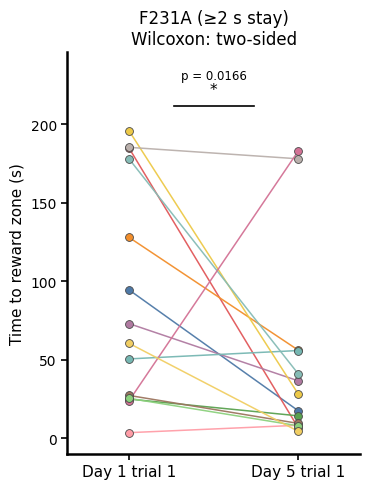

In [ ]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for time to reward zone
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
#   'day1_trial1_vs_day5_trial1':
#       Day 1 = trial 1 only
#       Day 5 = trial 1 only
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_trial1_vs_day5_trial1'
# COMPARE_MODE = 'day1_vs_test'
# COMPARE_MODE = 'day1_vs_day5'

GENOTYPE_TO_USE = 'F231A'  # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'eYFP_ChR2', 'CA1_control'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

# choose latency metric
USE_LONG_VISITS = True
TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_SUFFIX = ' (≥2 s stay)' if USE_LONG_VISITS else ' (all visits)'

# Optional short-duration filter
FILTER_SHORT_DURATION = False

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

INDIVIDUAL_COLOR_MODE = 'pastel'
DOT_EDGE = True

# y-axis padding
YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", TIME_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    Used for:
      - Day 1 in day1_vs_day5
      - Day 5 in day1_vs_day5
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(np.nanmean(by_trial.values)),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    Used for:
      - Day 1 in day1_vs_test
      - Test day in day1_vs_test
      - Day 1 and Day 5 in day1_trial1_vs_day5_trial1
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, TIME_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'
    comparison_description = 'Day 1 trial 1 vs Test trial 1'

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, TIME_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'
    comparison_description = 'Day 1 daily mean vs Day 5 daily mean'

elif COMPARE_MODE == 'day1_trial1_vs_day5_trial1':
    day1_df = per_subject_day_first_trial(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 5, TIME_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Day 5 trial 1'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'
    comparison_description = 'Day 1 trial 1 vs Day 5 trial 1'

else:
    raise ValueError(
        "COMPARE_MODE must be 'day1_vs_test', "
        "'day1_vs_day5', or 'day1_trial1_vs_day5_trial1'"
    )

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['y1_s'] = paired_print['y1'] / 1000.0
    paired_print['y2_s'] = paired_print['y2'] / 1000.0
    paired_print['diff_y2_minus_y1_s'] = paired_print['y2_s'] - paired_print['y1_s']
    print(paired_print[['sub', 'id', 'y1_s', 'y2_s', 'diff_y2_minus_y1_s', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 6) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")
print(comparison_description)

# ------------------------------------------------------------
# 7) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    """
    Publication-style muted but visible colours.
    """
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

# individual paired lines
if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'] / 1000.0, row['y2'] / 1000.0],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'] / 1000.0, row['y2'] / 1000.0],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'] / 1000.0,
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

# optional group mean ± SEM
y1_s = y1 / 1000.0
y2_s = y2 / 1000.0

if PLOT_GROUP_MEAN and len(y1_s) > 0:
    m1 = np.nanmean(y1_s)
    m2 = np.nanmean(y2_s)

    s1 = 0.0 if len(y1_s) <= 1 else np.nanstd(y1_s, ddof=1) / np.sqrt(len(y1_s))
    s2 = 0.0 if len(y2_s) <= 1 else np.nanstd(y2_s, ddof=1) / np.sqrt(len(y2_s))

    ax.plot(
        [x1, x2],
        [m1, m2],
        '-',
        color=base_col,
        linewidth=2.4,
        zorder=3
    )

    ax.errorbar(
        x1,
        m1,
        yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2,
        m2,
        yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# significance line + stars + p value
all_y_s = np.r_[y1_s, y2_s]

if len(all_y_s) > 0 and np.isfinite(all_y_s).any():
    ymax_data = np.nanmax(all_y_s)
    ymin_data = np.nanmin(all_y_s)
    yrng = ymax_data - ymin_data

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

# styling
ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel('Time to reward zone (s)', fontsize=11)

ax.set_title(
    f'{title_txt}\nWilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * yrng

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()



############################################################
RUNNING: t_to_trigger (all visits)
############################################################
Using time column: t_to_trigger
Stay mode: all visits
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10 (all visits)
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI  ChR2_

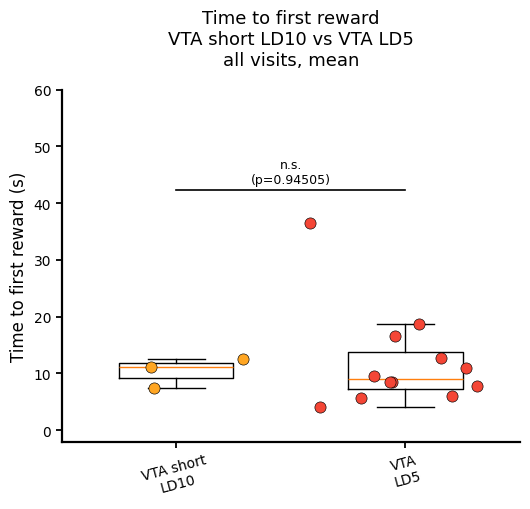


Time to first reward
VTA short next test vs VTA test
Per-animal values used for statistics:
Left group:
   sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0   13  AI   18744.0   18.744         1     [14]                 [1]   
1   14  AJ   20505.0   20.505         1     [14]                 [1]   
2   15  AL     328.0    0.328         1     [14]                 [1]   

  trial_type_list trial_in_day_list  
0             [T]               [1]  
1             [T]               [1]  
2             [T]               [1]  
Right group:
    sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0     1   A    5182.0    5.182         1      [9]                 [1]   
1     3   C    8237.0    8.237         1      [9]                 [1]   
2     4   D     278.0    0.278         1      [9]                 [1]   
3     6  AB    7985.0    7.985         1      [9]                 [1]   
4     7  AC    4357.0    4.357         1      [9]                 [1]   
5  

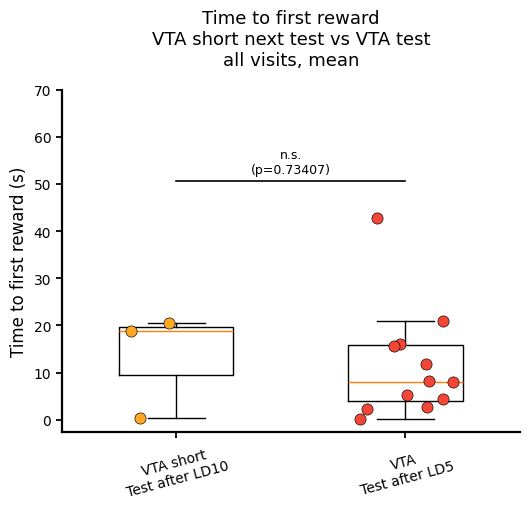



############################################################
RUNNING: t_to_trigger_long (≥2 s stay)
############################################################
Using time column: t_to_trigger_long
Stay mode: ≥2 s stay
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10 (≥2 s stay)
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI

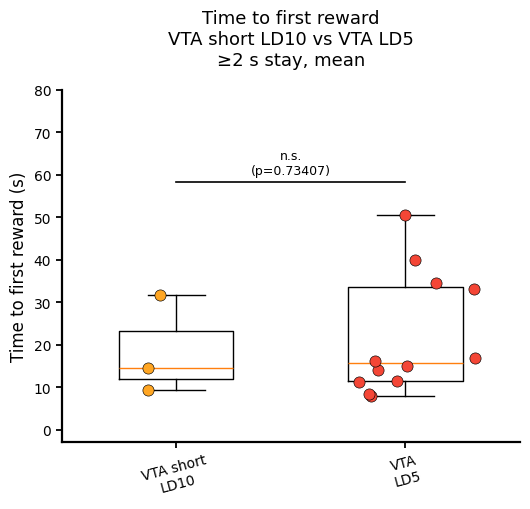


Time to first reward
VTA short next test vs VTA test
Per-animal values used for statistics:
Left group:
   sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0   13  AI   18744.0   18.744         1     [14]                 [1]   
1   14  AJ   37938.0   37.938         1     [14]                 [1]   
2   15  AL   18209.0   18.209         1     [14]                 [1]   

  trial_type_list trial_in_day_list  
0             [T]               [1]  
1             [T]               [1]  
2             [T]               [1]  
Right group:
    sub  id  value_ms  value_s  n_trials ses_list trial_type_day_list  \
0     1   A    5182.0    5.182         1      [9]                 [1]   
1     3   C   40861.0   40.861         1      [9]                 [1]   
2     4   D    9569.0    9.569         1      [9]                 [1]   
3     6  AB    7985.0    7.985         1      [9]                 [1]   
4     7  AC   33150.0   33.150         1      [9]                 [1]   
5  

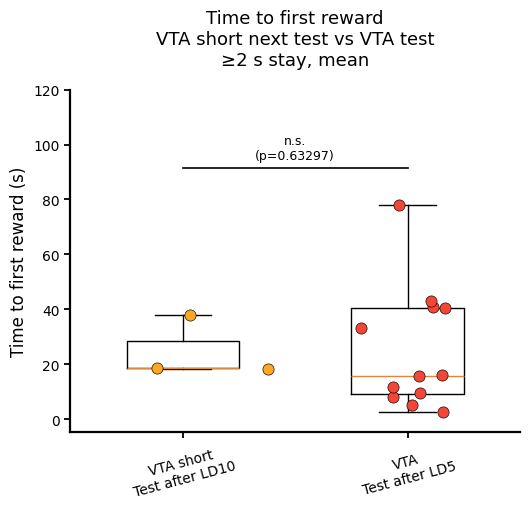

In [ ]:
# ============================================================
# Compare time to first reward:
#
# ChR2_short animals AI/AJ/AL:
#   final learning day = learning day 10
#   trial_type_day == 10, trial_type == 'L'
#
# vs
#
# ChR2 animals:
#   final learning day = learning day 5
#   trial_type_day == 5, trial_type == 'L'
#
# Also compare:
#   ChR2_short next test day after learning day 10
#   vs
#   ChR2 first test day after learning day 5
#
# Produces 4 boxplots:
#   1) Learning comparison, all visits:          t_to_trigger
#   2) Test comparison, all visits:              t_to_trigger
#   3) Learning comparison, ≥2 s stay only:      t_to_trigger_long
#   4) Test comparison, ≥2 s stay only:          t_to_trigger_long
#
# Stats:
#   Mann–Whitney U test between animal-level values.
#
# Prints:
#   - exact trial rows included
#   - animal-level values used for stats
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

CHR2_SHORT_IDS = ['AI', 'AJ', 'AL']

CH_R2_GENOTYPE = 'ChR2'
CH_R2_SHORT_GENOTYPE = 'ChR2_short'

TIME_COLS_TO_RUN = [
    ('t_to_trigger', 'all visits'),
    ('t_to_trigger_long', '≥2 s stay'),
]

EXCLUDE_ID = ['AN']      # optional
EXCLUDE_SUBS = []        # optional

REQUIRE_USABLE = True

# How to summarize multiple trials from the same animal/session/day
# 'mean' = average all included trials per animal
# 'first_trial' = use trial_in_day == 1 only
TRIAL_SUMMARY_MODE = 'mean'
# TRIAL_SUMMARY_MODE = 'first_trial'

# Plot options
SHOW_ANIMAL_IDS = False
JITTER = 0.18
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.18
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.35

# y-axis
YMIN = None
YMAX_BY_TIME_COL = {
    't_to_trigger': None,
    't_to_trigger_long': None,
}
Y_BOTTOM_PAD_FRAC = 0.04
Y_TICK_STEP = None       # e.g. 20, 50, or None

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

# ============================================================
# Helper functions
# ============================================================

def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.6):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def add_trial_in_day(meta_df):
    """
    Create trial_in_day = 1..8.
    Prefer an existing trial column if present.
    Otherwise infer from sorted sub/ses/trial_id order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        sort_cols = ['sub', 'ses']
        if 'trial_id' in meta_df.columns:
            sort_cols.append('trial_id')

        meta_df = meta_df.sort_values(sort_cols).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    return meta_df, trial_col


def print_trial_rows(label, meta_df, value_col):
    """
    Print exact trial-level rows used before per-animal averaging.
    Values are printed both in ms and seconds.
    """
    print("\n============================================================")
    print(label)
    print(f"Trial-level rows included: n rows = {len(meta_df)}")
    print(f"Animals included: n = {meta_df['sub'].nunique() if len(meta_df) > 0 else 0}")

    if len(meta_df) == 0:
        print("No rows.")
        return

    cols = [
        'sub',
        'id',
        'genotype',
        'ses',
        'trial_type',
        'trial_type_day',
        'trial_in_day',
    ]

    optional_cols = [
        'trial_id',
        'date',
        'usable',
        'short_duration',
        value_col,
    ]

    cols_to_print = [c for c in cols + optional_cols if c in meta_df.columns]

    out = meta_df[cols_to_print].copy()

    if value_col in out.columns:
        out[f'{value_col}_s'] = out[value_col].astype(float) / 1000.0

    sort_cols = [c for c in ['id', 'sub', 'ses', 'trial_in_day'] if c in out.columns]

    print(
        out
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )


def per_animal_value_from_trials(meta_df, value_col):
    """
    Converts trial-level rows into one value per animal.

    TRIAL_SUMMARY_MODE:
      'mean'        -> average across all included trials per animal
      'first_trial' -> only trial_in_day == 1
    """
    rows = []

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub].copy()

        if TRIAL_SUMMARY_MODE == 'first_trial':
            ms_use = ms[ms['trial_in_day'] == 1].copy()
        elif TRIAL_SUMMARY_MODE == 'mean':
            ms_use = ms.copy()
        else:
            raise ValueError("TRIAL_SUMMARY_MODE must be 'mean' or 'first_trial'")

        vals_ms = ms_use[value_col].values.astype(float)
        vals_ms = vals_ms[np.isfinite(vals_ms)]

        if len(vals_ms) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_label(ms, sub),
            'value_ms': float(np.nanmean(vals_ms)),
            'value_s': float(np.nanmean(vals_ms) / 1000.0),
            'n_trials': len(vals_ms),
            'ses_list': sorted(ms_use['ses'].dropna().unique().tolist()) if 'ses' in ms_use.columns else [],
            'trial_type_day_list': sorted(ms_use['trial_type_day'].dropna().unique().tolist()) if 'trial_type_day' in ms_use.columns else [],
            'trial_type_list': sorted(ms_use['trial_type'].dropna().unique().tolist()) if 'trial_type' in ms_use.columns else [],
            'trial_in_day_list': sorted(ms_use['trial_in_day'].dropna().unique().tolist()) if 'trial_in_day' in ms_use.columns else [],
        })

    return pd.DataFrame(rows)


def apply_box_y_axis(ax, y_top, value_col):
    manual_ymax = YMAX_BY_TIME_COL.get(value_col, None)

    if manual_ymax is not None:
        y_top = manual_ymax
    else:
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if YMIN is not None:
        y_bottom = YMIN
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + Y_TICK_STEP, Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def plot_two_group_boxplot(
    df_left,
    df_right,
    left_label,
    right_label,
    title,
    value_col,
    stay_tag,
):
    """
    Boxplot + individual dots + Mann–Whitney U test.
    df_left / df_right should contain columns:
      sub, id, value_s, value_ms, n_trials
    """
    vals_left = df_left['value_s'].values.astype(float) if len(df_left) > 0 else np.array([])
    vals_right = df_right['value_s'].values.astype(float) if len(df_right) > 0 else np.array([])

    vals_groups = [vals_left, vals_right]
    positions = np.array([0, 1])

    print("\n============================================================")
    print(title)
    print("Per-animal values used for statistics:")
    print("Left group:")
    print(df_left)
    print("Right group:")
    print(df_right)

    if len(vals_left) > 0 and len(vals_right) > 0:
        stat, p = mannwhitneyu(vals_left, vals_right, alternative='two-sided')
        rank_biserial = (2 * stat) / (len(vals_left) * len(vals_right)) - 1

        print("\nMann–Whitney U test:")
        print(
            f"  {left_label} vs {right_label}: "
            f"n={len(vals_left)} vs {len(vals_right)}, "
            f"mean={np.nanmean(vals_left):.3f} vs {np.nanmean(vals_right):.3f} s, "
            f"median={np.nanmedian(vals_left):.3f} vs {np.nanmedian(vals_right):.3f} s, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p, P_DECIMALS)}"
        )
    else:
        stat, p = np.nan, np.nan
        print("\nMann–Whitney U test: skipped because one group has no data.")

    fig, ax = plt.subplots(figsize=(5.4, 5.2))

    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------
    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    # --------------------------------------------------------
    # Individual dots
    # --------------------------------------------------------
    group_keys = [CH_R2_SHORT_GENOTYPE, CH_R2_GENOTYPE]

    for i, (df_g, vals, gkey) in enumerate(zip([df_left, df_right], vals_groups, group_keys)):
        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(gkey),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(gkey),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Significance line
    # --------------------------------------------------------
    nonempty = [v for v in vals_groups if len(v) > 0]

    if len(nonempty) > 0:
        all_vals = np.concatenate(nonempty)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y_line = ymax + P_LINE_START_FRAC * yrng
        y_text = y_line + P_TEXT_OFFSET_FRAC * yrng

        if np.isfinite(p):
            ax.plot(
                [positions[0], positions[1]],
                [y_line, y_line],
                color='black',
                linewidth=1.2,
                zorder=5,
                clip_on=False
            )

            ax.text(
                np.mean(positions),
                y_text,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9,
                zorder=6,
                clip_on=False
            )

        y_top_for_axis = y_line + P_TOP_PAD_FRAC * yrng
    else:
        y_top_for_axis = 1.0

    # --------------------------------------------------------
    # Axes / labels / style
    # --------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [left_label, right_label],
        fontsize=10,
        rotation=15
    )

    ax.set_ylabel('Time to first reward (s)', fontsize=12)
    ax.set_title(
        f'{title}\n{stay_tag}, {TRIAL_SUMMARY_MODE}',
        fontsize=13,
        pad=18
    )

    apply_box_y_axis(ax, y_top_for_axis, value_col)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# Main function for one time column
# ============================================================

def run_time_to_reward_comparison(time_col, stay_tag):
    print("\n\n############################################################")
    print(f"RUNNING: {time_col} ({stay_tag})")
    print("############################################################")

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        time_col,
    ]

    missing_cols = [c for c in needed_cols if c not in metadata.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in metadata: {missing_cols}")

    meta = metadata.copy()

    if REQUIRE_USABLE:
        meta = meta[meta['usable'] == 1].copy()

    meta = meta[
        meta['genotype'].isin([CH_R2_GENOTYPE, CH_R2_SHORT_GENOTYPE]) &
        meta['trial_type'].isin(['L', 'T']) &
        meta[time_col].notna() &
        np.isfinite(meta[time_col])
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
        meta = meta[
            ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta = meta[
            ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    meta, trial_col = add_trial_in_day(meta)

    print("Using time column:", time_col)
    print("Stay mode:", stay_tag)
    print("Trial summary mode:", TRIAL_SUMMARY_MODE)
    print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses/trial_id order")
    print("ChR2_short IDs requested:", CHR2_SHORT_IDS)

    # ========================================================
    # Comparison 1:
    # ChR2_short LD10 vs ChR2 LD5
    # ========================================================

    short_ld10_trials = meta[
        (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
        (meta['id'].astype(str).isin(CHR2_SHORT_IDS)) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 10)
    ].copy()

    chr2_ld5_trials = meta[
        (meta['genotype'] == CH_R2_GENOTYPE) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 5)
    ].copy()

    print_trial_rows(
        label=f"Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10 ({stay_tag})",
        meta_df=short_ld10_trials,
        value_col=time_col
    )

    print_trial_rows(
        label=f"Comparison 1 RIGHT: ChR2 learning day 5 ({stay_tag})",
        meta_df=chr2_ld5_trials,
        value_col=time_col
    )

    short_ld10_animal = per_animal_value_from_trials(short_ld10_trials, time_col)
    chr2_ld5_animal = per_animal_value_from_trials(chr2_ld5_trials, time_col)

    # ========================================================
    # Comparison 2:
    # ChR2_short next test after LD10 vs ChR2 first test after LD5
    # ========================================================

    # --------------------------------------------------------
    # ChR2_short next test:
    # for each animal, find last ses among LD10 rows;
    # next test session = last_ld10_ses + 1
    # --------------------------------------------------------
    short_next_test_list = []

    for animal_id in CHR2_SHORT_IDS:
        m_animal_ld10 = short_ld10_trials[
            short_ld10_trials['id'].astype(str) == str(animal_id)
        ].copy()

        if len(m_animal_ld10) == 0:
            print(f"WARNING: no LD10 rows found for {animal_id}; cannot find next test.")
            continue

        last_ld10_ses = m_animal_ld10['ses'].max()
        next_test_ses = last_ld10_ses + 1

        m_next_test = meta[
            (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
            (meta['id'].astype(str) == str(animal_id)) &
            (meta['trial_type'] == 'T') &
            (meta['ses'] == next_test_ses)
        ].copy()

        if len(m_next_test) == 0:
            print(
                f"WARNING: no next test rows found for {animal_id}: "
                f"expected ses = {next_test_ses}"
            )
            continue

        short_next_test_list.append(m_next_test)

    if len(short_next_test_list) > 0:
        short_next_test_trials = pd.concat(short_next_test_list, ignore_index=False)
    else:
        short_next_test_trials = meta.iloc[0:0].copy()

    # --------------------------------------------------------
    # ChR2 first test after learning day 5:
    # computed separately for each ChR2 animal.
    # --------------------------------------------------------
    chr2_test_list = []

    meta_chr2 = meta[meta['genotype'] == CH_R2_GENOTYPE].copy()

    for sub in meta_chr2['sub'].unique():
        ms = meta_chr2[meta_chr2['sub'] == sub].copy()

        m_ld5 = ms[
            (ms['trial_type'] == 'L') &
            (ms['trial_type_day'] == 5)
        ].copy()

        if len(m_ld5) == 0:
            continue

        last_ld5_ses = m_ld5['ses'].max()

        m_test_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_ld5_ses)
        ].copy()

        if len(m_test_after) == 0:
            continue

        first_test_ses = m_test_after['ses'].min()

        m_first_test = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] == first_test_ses)
        ].copy()

        if len(m_first_test) > 0:
            chr2_test_list.append(m_first_test)

    if len(chr2_test_list) > 0:
        chr2_test_trials = pd.concat(chr2_test_list, ignore_index=False)
    else:
        chr2_test_trials = meta.iloc[0:0].copy()

    print_trial_rows(
        label=f"Comparison 2 LEFT: ChR2_short AI/AJ/AL next test after learning day 10 ({stay_tag})",
        meta_df=short_next_test_trials,
        value_col=time_col
    )

    print_trial_rows(
        label=f"Comparison 2 RIGHT: ChR2 first test after learning day 5 ({stay_tag})",
        meta_df=chr2_test_trials,
        value_col=time_col
    )

    short_next_test_animal = per_animal_value_from_trials(short_next_test_trials, time_col)
    chr2_test_animal = per_animal_value_from_trials(chr2_test_trials, time_col)

    # ========================================================
    # Plot 1: final learning day comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_ld10_animal,
        df_right=chr2_ld5_animal,
        left_label='VTA short\nLD10',
        right_label='VTA\nLD5',
        title='Time to first reward\nVTA short LD10 vs VTA LD5',
        value_col=time_col,
        stay_tag=stay_tag,
    )

    # ========================================================
    # Plot 2: test comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_next_test_animal,
        df_right=chr2_test_animal,
        left_label='VTA short\nTest after LD10',
        right_label='VTA\nTest after LD5',
        title='Time to first reward\nVTA short next test vs VTA test',
        value_col=time_col,
        stay_tag=stay_tag,
    )


# ============================================================
# Run both all-visits and ≥2 s stay versions
# ============================================================

for time_col, stay_tag in TIME_COLS_TO_RUN:
    run_time_to_reward_comparison(time_col, stay_tag)

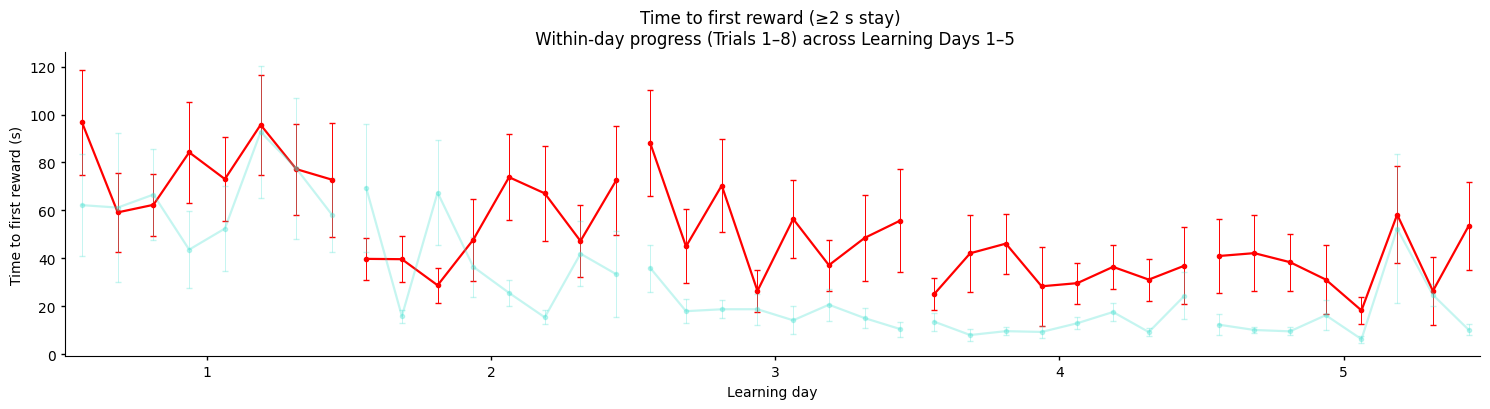

In [ ]:

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    #(metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,        # <-- add this
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# Split by genotype
meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()

# Wider figure so Day 5 curve isn't clipped
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red', alpha=1.0)
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # <-- more faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Centered day ticks
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure Day 5 curve fully visible

ax.set_xlim(1.0, 5.98)

ax.set_title('Time to first reward (≥2 s stay) \n Within-day progress (Trials 1–8) across Learning Days 1–5', fontsize=12)
#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Using: t_to_trigger_long (≥2 s stay)
VTA short animals plotted: n = 8
Animal IDs: ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']


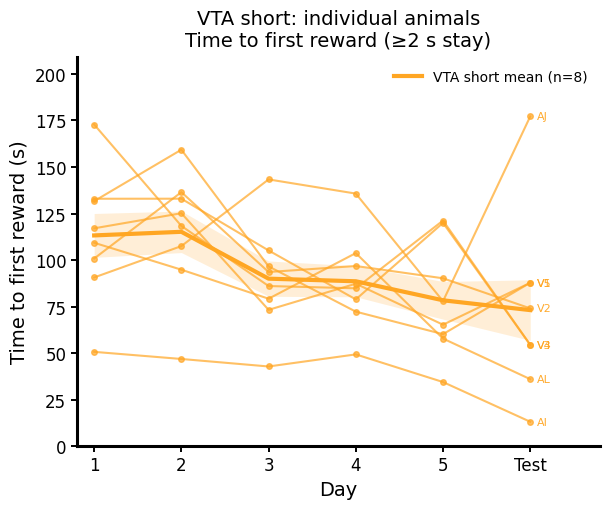

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Individual animal lines: ChR2_short
# Time to first reward across L1-L5 + Test
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
USE_LONG_VISITS = True        # False -> t_to_trigger ; True -> t_to_trigger_long
REQUIRE_COMPLETE = False      # True -> only animals with all L1-L5 + Test
EXCLUDE_ID = ['AS', 'AN']     # manually exclude animals by id; use [] for none
SHOW_ANIMAL_IDS = True        # label each animal line
SHOW_GROUP_MEAN = True        # overlay group mean ± SEM

GROUP_TO_PLOT = 'ChR2_short'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
}

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all entries'

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ------------------------------------------------------------
# 1. Filter metadata
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GROUP_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

# ------------------------------------------------------------
# 2. Assign plot_day: learning = 1–5, first post-learning test = 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep learning days 1–5 only
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3. Build animal × day matrix
# ------------------------------------------------------------
rows = []
subs = []
animal_ids = []

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub].copy()

    mean_by_day = ms.groupby('plot_day')[TIME_COL].mean()

    vals = np.array(
        [mean_by_day.get(d, np.nan) for d in plot_days],
        dtype=float
    )

    if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
        continue

    if np.all(np.isnan(vals)):
        continue

    rows.append(vals)
    subs.append(sub)

    if 'id' in ms.columns and ms['id'].notna().any():
        animal_ids.append(str(ms['id'].dropna().iloc[0]))
    else:
        animal_ids.append(str(sub))

if len(rows) == 0:
    print(f"No animals found for {GROUP_TO_PLOT} using {TIME_COL}.")
else:
    mat = np.vstack(rows)

    print("Using:", TIME_COL, f"({STAY_TAG})")
    print(f"{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)} animals plotted: n = {len(subs)}")
    print("Animal IDs:", animal_ids)

    # --------------------------------------------------------
    # 4. Plot individual animal lines clearly
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    col = get_genotype_color(GROUP_TO_PLOT)

    for i, row in enumerate(mat):
        y = row / 1000.0

        ax.plot(
            x_vals,
            y,
            '-o',
            color=col,
            alpha=0.70,
            linewidth=1.5,
            markersize=4,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            finite_idx = np.where(np.isfinite(y))[0]
            if len(finite_idx) > 0:
                last_i = finite_idx[-1]
                ax.text(
                    x_vals[last_i] + 0.08,
                    y[last_i],
                    animal_ids[i],
                    fontsize=8,
                    color=col,
                    alpha=0.95,
                    ha='left',
                    va='center'
                )

    # --------------------------------------------------------
    # Optional group mean ± SEM
    # --------------------------------------------------------
    if SHOW_GROUP_MEAN:
        mean_ms = np.nanmean(mat, axis=0)

        n_per_day = np.sum(~np.isnan(mat), axis=0)
        sem_ms = np.nanstd(mat, axis=0) / np.sqrt(n_per_day)
        sem_ms[n_per_day <= 1] = 0

        mean_s = mean_ms / 1000.0
        sem_s = sem_ms / 1000.0

        ax.fill_between(
            x_vals,
            mean_s - sem_s,
            mean_s + sem_s,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

        ax.plot(
            x_vals,
            mean_s,
            '-',
            color=col,
            linewidth=3.0,
            alpha=1.0,
            label=f'{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)} mean (n={len(subs)})',
            zorder=4
        )

    # --------------------------------------------------------
    # Axes + style
    # --------------------------------------------------------
    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward (s)', fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.4)

    ax.set_title(
        f'{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)}: individual animals\n'
        f'Time to first reward ({STAY_TAG})',
        fontsize=14,
        pad=8
    )

    if SHOW_GROUP_MEAN:
        ax.legend(frameon=False)

    # auto y-limit
    all_vals_s = mat[np.isfinite(mat)].ravel() / 1000.0
    if len(all_vals_s) > 0:
        ymax = np.nanmax(all_vals_s)
        ax.set_ylim(0, ymax * 1.18)

    # leave space for labels
    if SHOW_ANIMAL_IDS:
        ax.set_xlim(-0.2, 5.8)
    else:
        ax.set_xlim(-0.2, 5.2)

    plt.tight_layout()
    plt.show()

# forgetting/extinction



############################################################
RUNNING TIME-TO-REWARD ANALYSIS: ALL VISITS
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Time conversion: metadata ms × 0.001 = seconds
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger
0     1   A       ChR2  extinction               1        5182.0
1     1   A       ChR2  extinction               2       11546.0
2     1   A       ChR2  extinction               3       10349.0
3     6  AB       ChR2  extinction               1        7985.0
4     6  AB       ChR2  extinction               2        5069.0
..  ...  ..        ...         ...             ...           ...

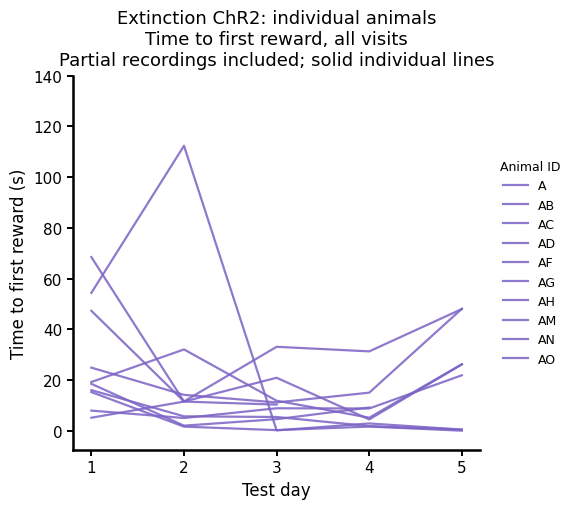


Individual ChR2 lines: Forgetting
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


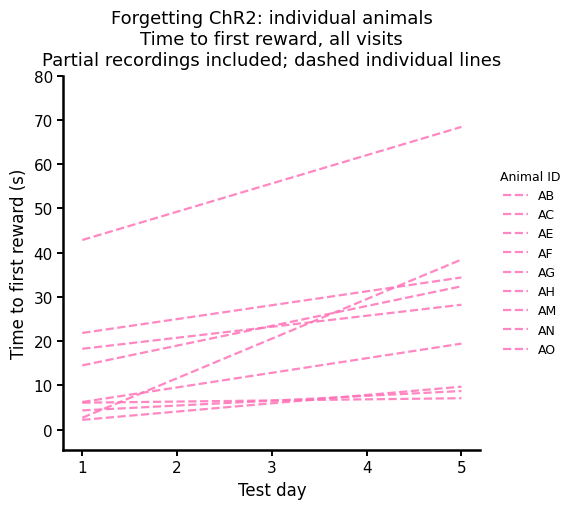


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


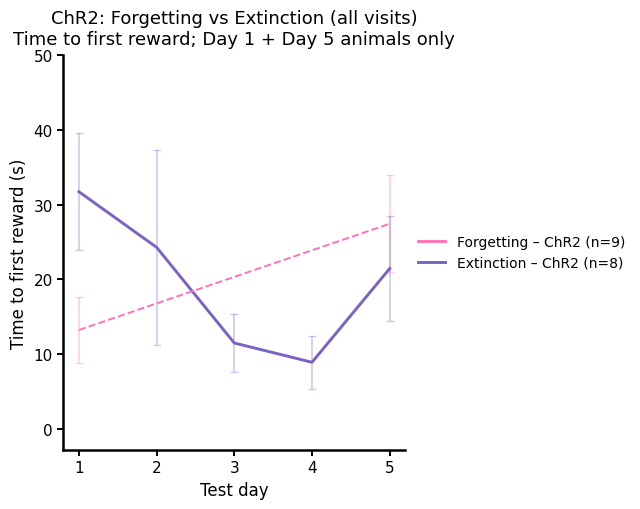


Ordinary boxplot: Test day 1
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 7.985 15.29  68.507 54.409 16.059 47.32  24.921 19.261]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [25.393  3.213]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 6.098   4.357  21.8625 42.87    6.259   2.218  14.531  18.285   2.691 ]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [187.296   2.288]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=31.719 vs 14.303 s, median=22.091 vs 14.303 s, U=11.0, rank-biserial=0.375, p=0.53333
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=13.241 vs 94.792 s, median=6.

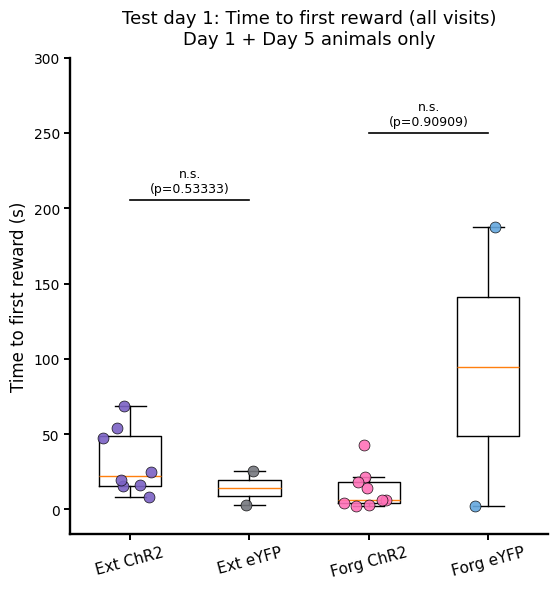


Ordinary boxplot: Test day 2
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [  5.069   1.675  11.553 112.389   5.732  11.603  14.201  32.104]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


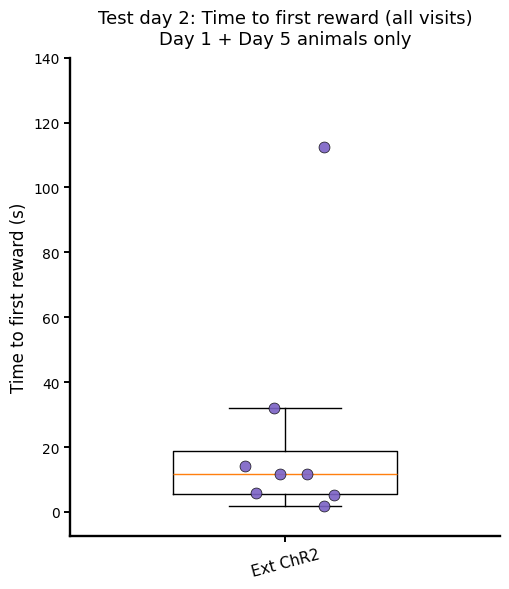


Ordinary boxplot: Test day 3
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 8.909  0.291 20.935  0.205  5.472 33.142 11.205 11.88 ]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


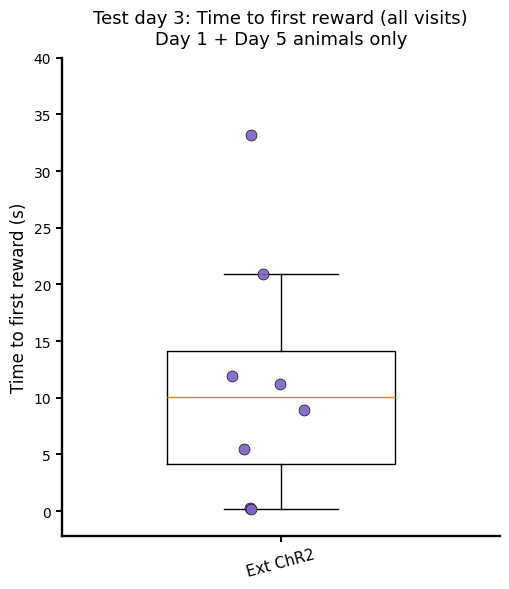


Ordinary boxplot: Test day 4
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 8.825  1.69   4.515  2.92   1.873 31.338 15.063  5.19 ]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


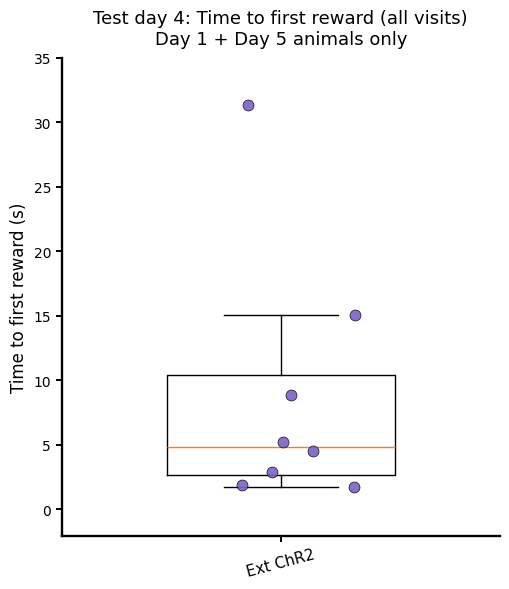


Ordinary boxplot: Test day 5
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [21.921   0.081  26.2115  0.525   0.482  48.032  48.129  26.271 ]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [72.281  0.398]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [ 7.113   8.745  34.3985 68.43   19.45    9.72   32.41   28.237  38.45  ]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [24.743  0.   ]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=21.457 vs 36.340 s, median=24.066 vs 36.340 s, U=7.0, rank-biserial=-0.125, p=0.88889
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=27.439 vs 12.372 s, med

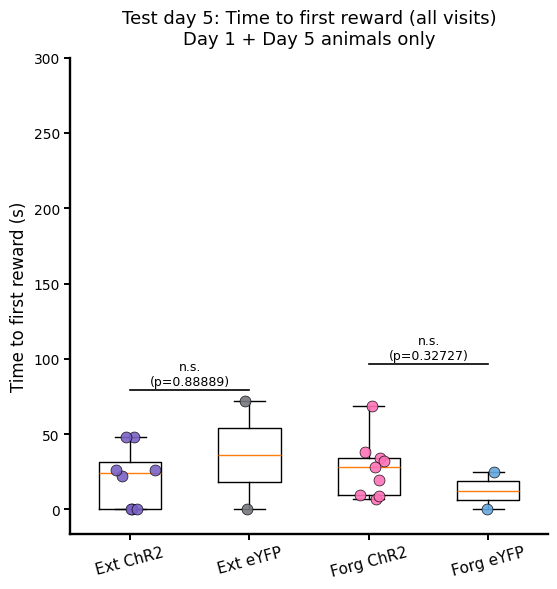


Paired ChR2 Extinction vs Forgetting, test day 1
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB      7.985       6.098
1    7  AC     15.290       4.357
2   10  AF     54.409      42.870
3   11  AG     16.059       6.259
4   16  AM     47.320      14.531
5   17  AN     24.921      18.285
6   18  AO     19.261       2.691
Wilcoxon paired test: n=7, Ext mean=26.464 s, Forg mean=13.584 s, Ext median=19.261 s, Forg median=6.259 s, stat=0.000, p=0.01562


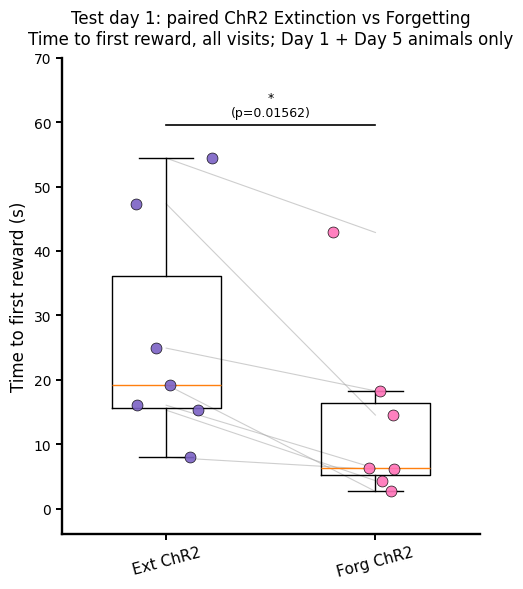


Paired ChR2 Extinction vs Forgetting, test day 5
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB     21.921       7.113
1    7  AC      0.081       8.745
2   10  AF      0.525      68.430
3   11  AG      0.482      19.450
4   16  AM     48.032      32.410
5   17  AN     48.129      28.237
6   18  AO     26.271      38.450
Wilcoxon paired test: n=7, Ext mean=20.777 s, Forg mean=28.976 s, Ext median=21.921 s, Forg median=28.237 s, stat=13.000, p=0.93750


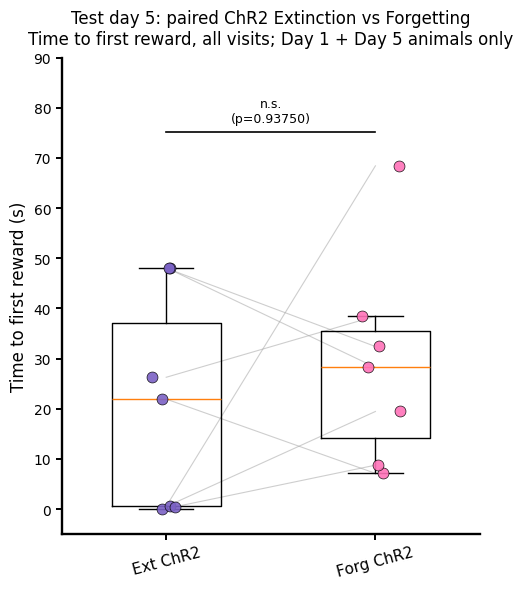


Paired ChR2 extinction: Day 1 vs Day 5
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB       7.985     21.9210
1    7  AC      15.290      0.0810
2    8  AD      68.507     26.2115
3   10  AF      54.409      0.5250
4   11  AG      16.059      0.4820
5   16  AM      47.320     48.0320
6   17  AN      24.921     48.1290
7   18  AO      19.261     26.2710
Wilcoxon paired test: n=8, Day1 mean=31.719 s, Day5 mean=21.457 s, Day1 median=22.091 s, Day5 median=24.066 s, stat=12.000, p=0.46094


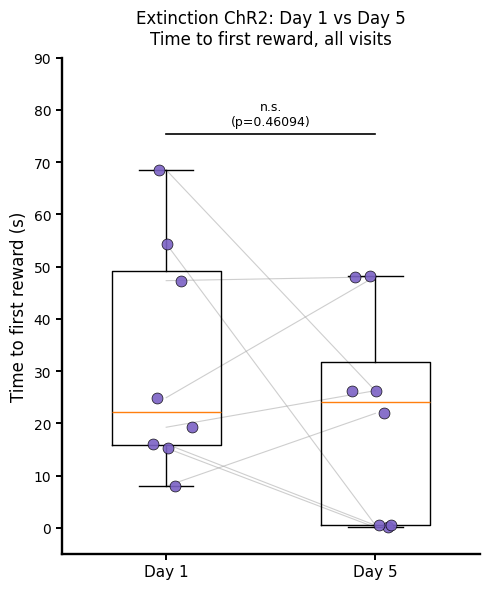


Paired ChR2 forgetting: Day 1 vs Day 5
Time column: t_to_trigger
Y-axis label: Time to first reward (s)
Computed using: all visits
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB      6.0980      7.1130
1    7  AC      4.3570      8.7450
2    9  AE     21.8625     34.3985
3   10  AF     42.8700     68.4300
4   11  AG      6.2590     19.4500
5   12  AH      2.2180      9.7200
6   16  AM     14.5310     32.4100
7   17  AN     18.2850     28.2370
8   18  AO      2.6910     38.4500
Wilcoxon paired test: n=9, Day1 mean=13.241 s, Day5 mean=27.439 s, Day1 median=6.259 s, Day5 median=28.237 s, stat=0.000, p=0.00391


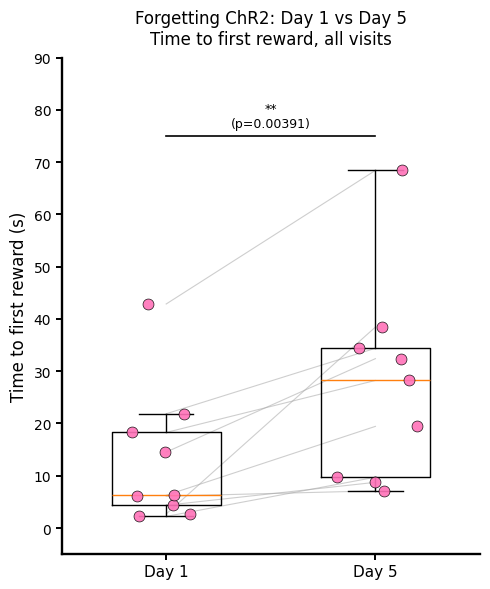



############################################################
RUNNING TIME-TO-REWARD ANALYSIS: ≥2 S STAY
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Time conversion: metadata ms × 0.001 = seconds
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Line plot genotypes: ['ChR2']
Endpoint ordinary boxplot controls: eYFP_ChR2
SEM style: bar
############################################################

All valid TEST rows before aggregate-cohort restriction:
    sub  id   genotype   test_type  trial_type_day  t_to_trigger_long
0     1   A       ChR2  extinction               1             5182.0
1     1   A       ChR2  extinction               2            38283.0
2     1   A       ChR2  extinction               3            24930.0
3     6  AB       ChR2  extinction               1             7985.0
4     6  AB       ChR2  extinction               2            64538.0
..  ...  ..        ...         

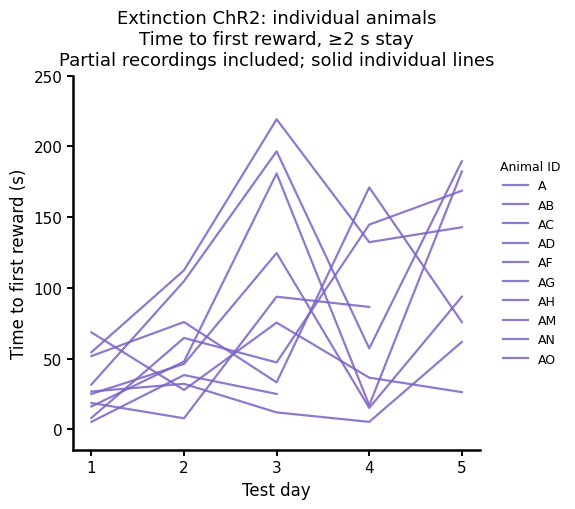


Individual ChR2 lines: Forgetting
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort restriction applied: NO
Animals with any available test day are included.
   sub  id available_days  n_days
0    6  AB         [1, 5]       2
1    7  AC         [1, 5]       2
2    9  AE         [1, 5]       2
3   10  AF         [1, 5]       2
4   11  AG         [1, 5]       2
5   12  AH         [1, 5]       2
6   16  AM         [1, 5]       2
7   17  AN         [1, 5]       2
8   18  AO         [1, 5]       2


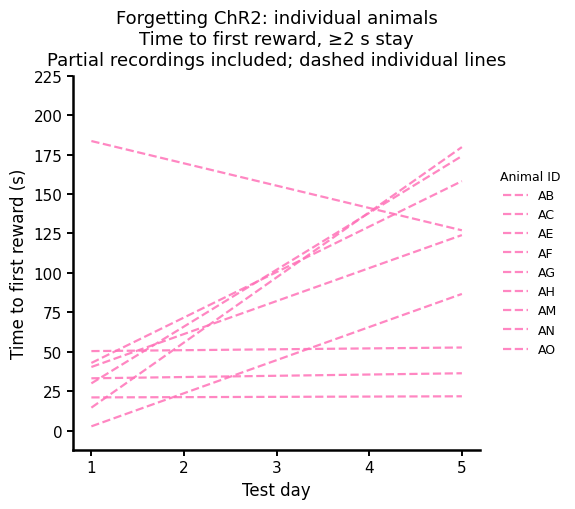


Animals included in ChR2-only aggregate line plot:
  Forgetting – ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
  Extinction – ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], subs = [np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(16), np.int64(17), np.int64(18)]


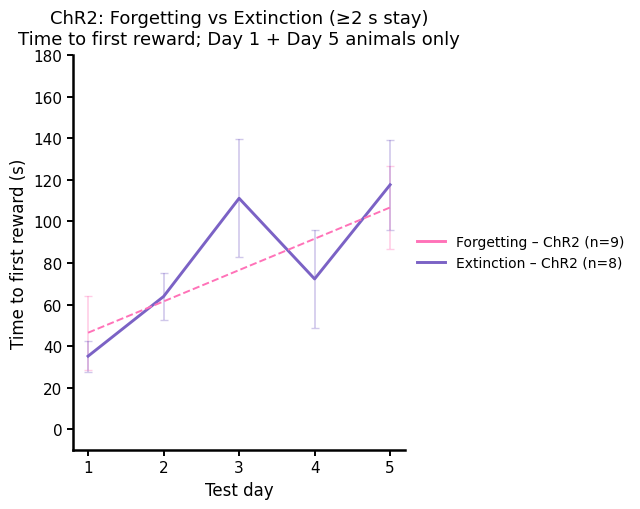


Ordinary boxplot: Test day 1
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 7.985 31.591 68.507 54.409 16.059 51.713 24.921 26.664]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [101.325 172.455]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [183.586  33.15   50.398  42.87   21.022  40.314  14.531  29.932   2.691]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [187.296 180.073]

Mann–Whitney U tests, test day 1:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=35.231 vs 136.890 s, median=29.128 vs 136.890 s, U=0.0, rank-biserial=-1.000, p=0.04444
  Forg ChR2 vs Forg eYFP: n=9 vs 2, mean=46.499 vs 183.685 s, 

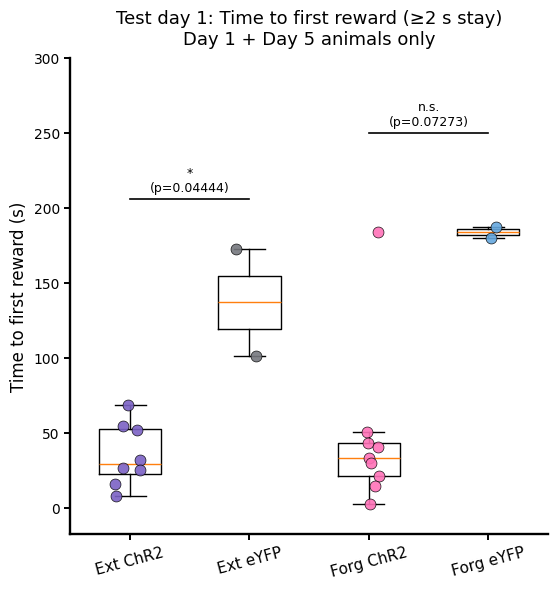


Ordinary boxplot: Test day 2
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 64.538 104.698  27.759 112.389  47.843  75.784  46.142  32.104]

Mann–Whitney U tests, test day 2:
  No between-group comparison specified for this plot.


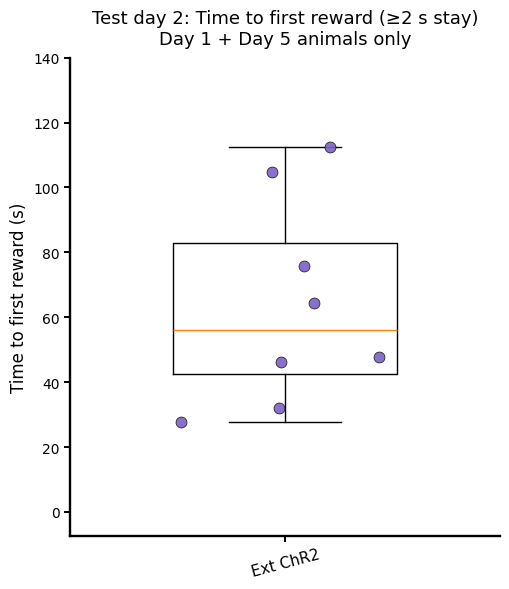


Ordinary boxplot: Test day 3
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [ 47.23  196.508  75.364 219.185 180.878  33.142 124.618  11.88 ]

Mann–Whitney U tests, test day 3:
  No between-group comparison specified for this plot.


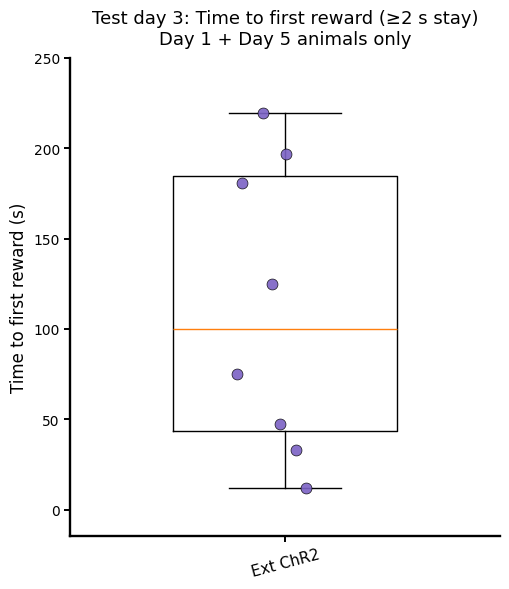


Ordinary boxplot: Test day 4
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
Day 2-4 plot: Extinction ChR2 only; eYFP not included.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [144.697   57.152   36.4435 132.268   16.93   171.005   15.063    5.19  ]

Mann–Whitney U tests, test day 4:
  No between-group comparison specified for this plot.


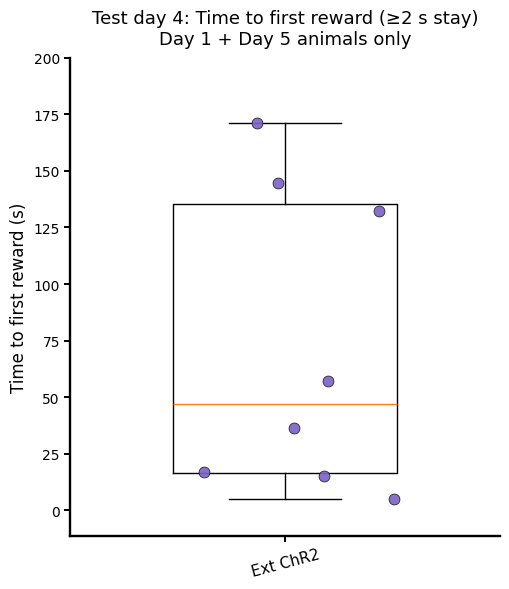


Ordinary boxplot: Test day 5
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort mode: day1_day5
Aggregate cohort description: Day 1 + Day 5 animals only
eYFP control included for endpoint comparisons only.
Comparisons: Ext ChR2 vs Ext eYFP; Forg ChR2 vs Forg eYFP.
  Ext ChR2: n = 8, ids = ['AB', 'AC', 'AD', 'AF', 'AG', 'AM', 'AN', 'AO'], values_s = [168.664  189.566   26.2115 142.843  182.255   75.756   93.742   61.753 ]
  Ext eYFP: n = 2, ids = ['EE', 'EF'], values_s = [208.252 186.397]
  Forg ChR2: n = 9, ids = ['AB', 'AC', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values_s = [126.983   36.332   52.6705 158.158   21.733  123.95   179.746  174.058
  86.63  ]
  Forg eYFP: n = 2, ids = ['EE', 'EF'], values_s = [120.716 186.122]

Mann–Whitney U tests, test day 5:
  Ext ChR2 vs Ext eYFP: n=8 vs 2, mean=117.599 vs 197.325 s, median=118.292 vs 197.325 s, U=1.0, rank-biserial=-0.875, p=0.08889
  Forg ChR2 vs Forg eYFP: n=9 vs 2,

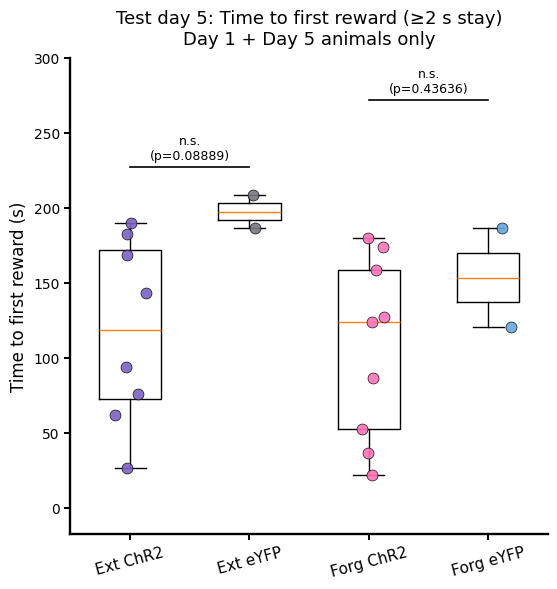


Paired ChR2 Extinction vs Forgetting, test day 1
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB      7.985     183.586
1    7  AC     31.591      33.150
2   10  AF     54.409      42.870
3   11  AG     16.059      21.022
4   16  AM     51.713      14.531
5   17  AN     24.921      29.932
6   18  AO     26.664       2.691
Wilcoxon paired test: n=7, Ext mean=30.477 s, Forg mean=46.826 s, Ext median=26.664 s, Forg median=29.932 s, stat=13.000, p=0.93750


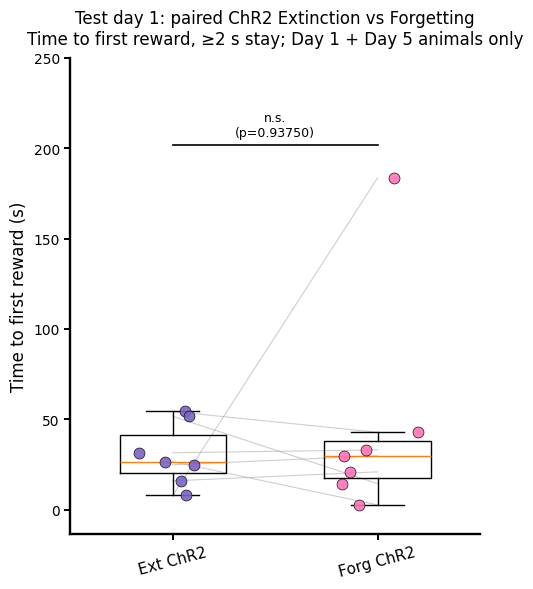


Paired ChR2 Extinction vs Forgetting, test day 5
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  ext_value  forg_value
0    6  AB    168.664     126.983
1    7  AC    189.566      36.332
2   10  AF    142.843     158.158
3   11  AG    182.255      21.733
4   16  AM     75.756     179.746
5   17  AN     93.742     174.058
6   18  AO     61.753      86.630
Wilcoxon paired test: n=7, Ext mean=130.654 s, Forg mean=111.949 s, Ext median=142.843 s, Forg median=126.983 s, stat=12.000, p=0.81250


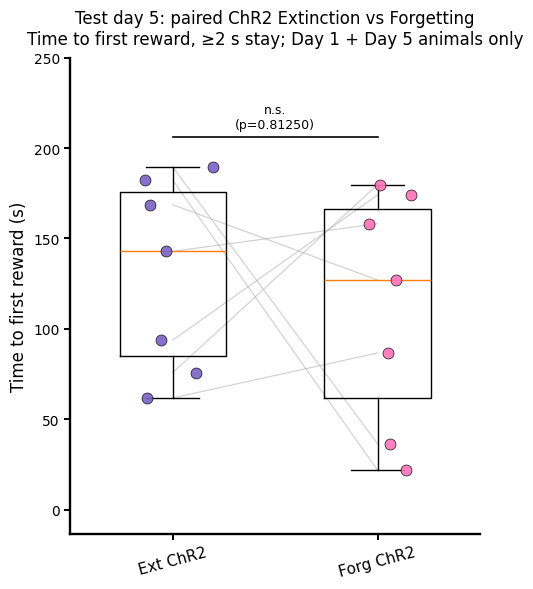


Paired ChR2 extinction: Day 1 vs Day 5
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB       7.985    168.6640
1    7  AC      31.591    189.5660
2    8  AD      68.507     26.2115
3   10  AF      54.409    142.8430
4   11  AG      16.059    182.2550
5   16  AM      51.713     75.7560
6   17  AN      24.921     93.7420
7   18  AO      26.664     61.7530
Wilcoxon paired test: n=8, Day1 mean=35.231 s, Day5 mean=117.599 s, Day1 median=29.128 s, Day5 median=118.292 s, stat=3.000, p=0.03906


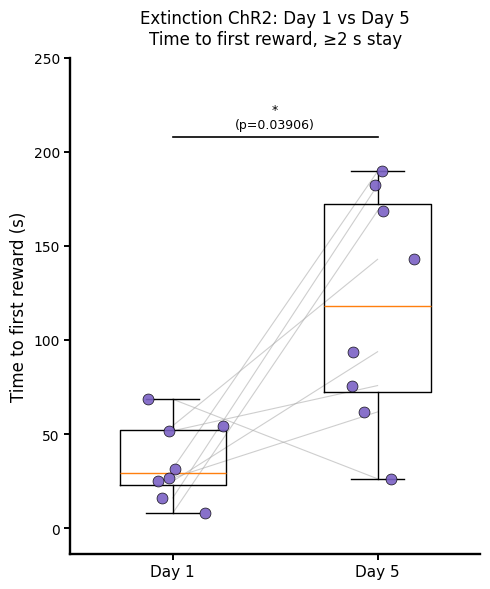


Paired ChR2 forgetting: Day 1 vs Day 5
Time column: t_to_trigger_long
Y-axis label: Time to first reward (s)
Computed using: ≥2 s stay
Aggregate cohort description: Day 1 + Day 5 animals only

Paired animals:
   sub  id  day1_value  day5_value
0    6  AB     183.586    126.9830
1    7  AC      33.150     36.3320
2    9  AE      50.398     52.6705
3   10  AF      42.870    158.1580
4   11  AG      21.022     21.7330
5   12  AH      40.314    123.9500
6   16  AM      14.531    179.7460
7   17  AN      29.932    174.0580
8   18  AO       2.691     86.6300
Wilcoxon paired test: n=9, Day1 mean=46.499 s, Day5 mean=106.696 s, Day1 median=33.150 s, Day5 median=123.950 s, stat=4.000, p=0.02734


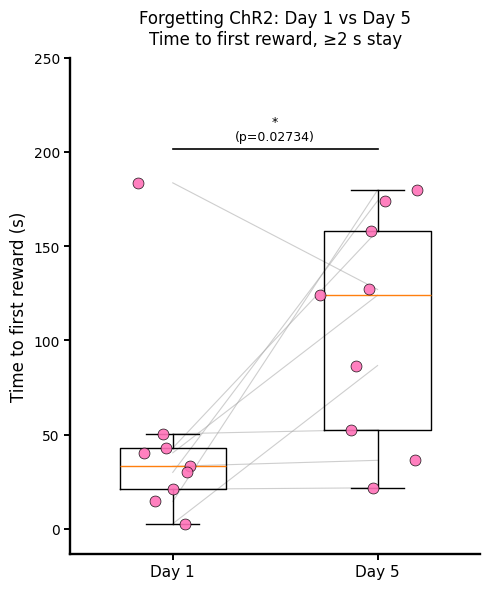

In [348]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon

# ============================================================
# Forgetting / Extinction TEST trials across test days 1-5
#
# Metric:
#   Time to first reward zone, plotted in seconds.
#
# Produces the complete figure set for BOTH:
#
#   1) t_to_trigger
#        = all visits
#
#   2) t_to_trigger_long
#        = visits satisfying the ≥2 s stay criterion
#
# Figure set produced for each visit criterion:
#
#   1) Aggregate mean ± SEM line plot:
#        - ChR2 ONLY
#        - Forgetting ChR2 vs Extinction ChR2
#
#   2) Individual ChR2 extinction lines:
#        - ChR2 ONLY
#        - solid individual lines
#        - partial recordings included
#
#   3) Individual ChR2 forgetting lines:
#        - ChR2 ONLY
#        - dashed individual lines
#        - partial recordings included
#
#   4) Ordinary day boxplots:
#        - Test Day 1 and Test Day 5:
#             Ext ChR2, Ext eYFP, Forg ChR2, Forg eYFP
#             Comparisons:
#                 Ext ChR2 vs Ext eYFP
#                 Forg ChR2 vs Forg eYFP
#
#        - Test Day 2, 3 and 4:
#             Ext ChR2 ONLY
#             No eYFP plotted
#             No between-group comparison
#
#   5) Paired ChR2 Extinction vs Forgetting boxplots:
#        - Day 1 and Day 5
#        - ChR2 ONLY
#
#   6) Paired Day 1 vs Day 5 boxplots:
#        - ChR2 Extinction
#        - ChR2 Forgetting
#
# IMPORTANT:
#   - This code does not recompute time-to-reward variables.
#   - It assumes:
#         metadata['t_to_trigger']
#         metadata['t_to_trigger_long']
#     already exist.
#   - These columns are assumed to be stored in milliseconds,
#     as in your previous time-to-trigger plotting code.
#   - Values are converted to seconds only for plotting/statistics.
#   - short_duration is NOT filtered anywhere in this code.
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

# ------------------------------------------------------------
# Time-to-reward definitions to plot
# ------------------------------------------------------------
# The code loops over both definitions and generates the complete
# set of figures separately for each one.
# ------------------------------------------------------------

TIME_DEFINITIONS_TO_PLOT = [
    {
        'value_col': 't_to_trigger',
        'stay_tag': 'all visits',
        'run_label': 'ALL VISITS',
    },
    {
        'value_col': 't_to_trigger_long',
        'stay_tag': '≥2 s stay',
        'run_label': '≥2 S STAY',
    },
]

# Existing time variables are assumed to be stored in ms.
# Conversion to seconds happens only inside this plotting code.
TIME_SCALE_TO_SECONDS = 1.0 / 1000.0

TIME_LABEL = 'Time to first reward (s)'
TIME_TITLE = 'Time to first reward'

# ------------------------------------------------------------
# Genotypes used for each plot type
# ------------------------------------------------------------

# Aggregate line plots and individual-animal plots use ChR2 only.
LINE_GENOTYPES = ['ChR2']

# Endpoint ordinary boxplots additionally use eYFP control.
ENDPOINT_CONTROL_GENOTYPE = 'eYFP_ChR2'
INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS = True

# All genotypes required to be loaded from metadata.
GENOTYPES_TO_LOAD = ['ChR2']

if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
    GENOTYPES_TO_LOAD.append(ENDPOINT_CONTROL_GENOTYPE)

GENOTYPES_TO_LOAD = sorted(set(GENOTYPES_TO_LOAD))

EXCLUDE_ID = []
EXCLUDE_SUBS = []

max_day = 5
day_values = np.arange(1, max_day + 1)

# ------------------------------------------------------------
# Aggregate/statistical cohort rule
# ------------------------------------------------------------
# Options:
#
#   'all'
#       Use all animals with at least one finite value.
#
#   'day1_day5'
#       Use only animals with finite values on both Day 1 and Day 5
#       within each genotype × test_type group.
#
#   'all_five'
#       Use only animals with finite values on Days 1-5.
#
# This rule applies independently to:
#   ChR2 extinction
#   ChR2 forgetting
#   eYFP extinction
#   eYFP forgetting
#
# Individual ChR2 trajectory plots ignore this restriction and show
# all animals with any available data.
# ------------------------------------------------------------

GROUP_PLOT_COHORT_MODE = 'day1_day5'
# GROUP_PLOT_COHORT_MODE = 'all'
# GROUP_PLOT_COHORT_MODE = 'all_five'

VALID_COHORT_MODES = ['all', 'day1_day5', 'all_five']

if GROUP_PLOT_COHORT_MODE not in VALID_COHORT_MODES:
    raise ValueError(
        f"GROUP_PLOT_COHORT_MODE must be one of {VALID_COHORT_MODES}."
    )

# ------------------------------------------------------------
# Colours
# ------------------------------------------------------------

COL_FORG_CHR2 = "#FF72B8"      # pink
COL_EXT_CHR2 = "#7b62c5ff"     # purple
COL_FORG_YFP = "#65a8deff"     # blue
COL_EXT_YFP = "#76787EC1"      # grey

GROUP_STYLE = {
    ('ChR2', 'forgetting'): {
        'key': 'f_ChR2',
        'label': 'Forg ChR2',
        'long_label': 'Forgetting – ChR2',
        'color': COL_FORG_CHR2,
    },
    ('ChR2', 'extinction'): {
        'key': 'e_ChR2',
        'label': 'Ext ChR2',
        'long_label': 'Extinction – ChR2',
        'color': COL_EXT_CHR2,
    },
    ('eYFP_ChR2', 'forgetting'): {
        'key': 'f_YFP',
        'label': 'Forg eYFP',
        'long_label': 'Forgetting – eYFP',
        'color': COL_FORG_YFP,
    },
    ('eYFP_ChR2', 'extinction'): {
        'key': 'e_YFP',
        'label': 'Ext eYFP',
        'long_label': 'Extinction – eYFP',
        'color': COL_EXT_YFP,
    },
}

DISPLAY_NAME = {
    'ChR2': 'ChR2',
    'eYFP_ChR2': 'eYFP',
}

# ------------------------------------------------------------
# Aggregate ChR2-only line plot options
# ------------------------------------------------------------

# 'bar' or 'shaded'
SEM_STYLE = 'bar'
# SEM_STYLE = 'shaded'

LINE_FIGSIZE = (8.0, 5.2)

LINE_ZERO_PAD_FRAC = 0.06
LINE_TOP_PAD_FRAC = 0.18

LINE_YMIN = None
LINE_YMAX = None
LINE_Y_TICK_STEP = None

# ------------------------------------------------------------
# Individual ChR2 line plot options
# ------------------------------------------------------------

RUN_INDIVIDUAL_CHR2_LINE_PLOTS = True
INDIVIDUAL_CHR2_TEST_TYPES = ['extinction', 'forgetting']

INDIVIDUAL_FIGSIZE = (7.0, 5.2)
INDIVIDUAL_LINEWIDTH = 1.6
INDIVIDUAL_ALPHA = 0.85
INDIVIDUAL_SHOW_LEGEND = True

INDIVIDUAL_YMIN = None
INDIVIDUAL_YMAX = None
INDIVIDUAL_Y_TICK_STEP = None

INDIVIDUAL_ZERO_PAD_FRAC = 0.06
INDIVIDUAL_TOP_PAD_FRAC = 0.12

# ------------------------------------------------------------
# Ordinary boxplot options
# ------------------------------------------------------------

RUN_DAY_BOXPLOTS = True
BOXPLOT_DAYS = [1, 2, 3, 4, 5]

# Match ordinary Day 1 and Day 5 y-axis limits.
MATCH_DAY1_DAY5_BOXPLOT_YAXIS = True

# ------------------------------------------------------------
# Paired ChR2-only boxplot options
# ------------------------------------------------------------

# Paired ChR2 Extinction vs Forgetting on the same day
RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS = True
PAIRED_CHR2_DAYS = [1, 5]

# Paired Day 1 vs Day 5 within ChR2 extinction/forgetting
RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS = True
DAY1_VS_DAY5_GENOTYPE = 'ChR2'
DAY1_VS_DAY5_TEST_TYPES = ['extinction', 'forgetting']

SHOW_PAIRED_LINES = True
SHOW_ANIMAL_IDS = False

# ------------------------------------------------------------
# Dot / annotation / box-axis options
# ------------------------------------------------------------

JITTER = 0.10
DOT_SIZE = 62
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

BOX_FIG_HEIGHT = 6.0

P_DECIMALS = 5

# Compact p-value spacing
P_LINE_START_FRAC = 0.10
P_LINE_STEP_FRAC = 0.24
P_TEXT_OFFSET_FRAC = 0.018
BOX_ANNOTATION_TOP_FRAC = 0.08

BOX_Y_ZERO_PAD_FRAC = 0.06
BOX_Y_TOP_PAD_FRAC = 0.10

BOX_YMIN = None
BOX_Y_TICK_STEP = None

np.random.seed(1)


# ============================================================
# General helper functions
# ============================================================

def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def test_type_display_name(test_type):
    if test_type == 'extinction':
        return 'Extinction'
    if test_type == 'forgetting':
        return 'Forgetting'
    return str(test_type)


def cohort_description():
    if GROUP_PLOT_COHORT_MODE == 'all':
        return 'All available animals'
    if GROUP_PLOT_COHORT_MODE == 'day1_day5':
        return 'Day 1 + Day 5 animals only'
    if GROUP_PLOT_COHORT_MODE == 'all_five':
        return 'Animals with all Days 1–5 only'
    return GROUP_PLOT_COHORT_MODE


def empty_day_value_dataframe():
    """
    Empty dataframe with expected downstream columns.
    """
    return pd.DataFrame(
        columns=[
            'sub',
            'id',
            'genotype',
            'test_type',
            'day',
            'value',
        ]
    )


def convert_time_to_seconds(value):
    """
    Convert time-to-first-reward value from ms to seconds.
    """
    return value * TIME_SCALE_TO_SECONDS


def mean_and_sem(mat):
    """
    Robust mean and SEM across animals for each test day.

    Input matrix is already in seconds.
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]

    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = np.isfinite(col)
        n = valid.sum()

        if n == 0:
            continue

        mean[j] = col[valid].mean()

        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
        else:
            sem[j] = 0.0

    return mean, sem


def run_wilcoxon(a, b):
    """
    Safe paired Wilcoxon signed-rank test.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    """
    Draw compact horizontal significance bar and p-value annotation.
    """
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# Cohort selection helpers
# ============================================================

def get_group_subject_summary(meta_df, genotype, test_type, value_col):
    """
    Build one inclusion-summary row per animal within one
    genotype × test_type group.

    Inclusion is evaluated using the selected time-to-reward
    definition, so all-visits and ≥2 s-stay plots can correctly
    have different included cohorts when long-visit values are missing.
    """
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'].isin(day_values)) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    summary_rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        per_day = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        finite_by_day = {
            d: bool(d in per_day.index and np.isfinite(per_day.loc[d]))
            for d in day_values
        }

        has_any_day = any(finite_by_day.values())
        has_day1_day5 = finite_by_day[1] and finite_by_day[5]
        has_all_five = all(finite_by_day[d] for d in day_values)

        if GROUP_PLOT_COHORT_MODE == 'all':
            included = has_any_day

        elif GROUP_PLOT_COHORT_MODE == 'day1_day5':
            included = has_day1_day5

        elif GROUP_PLOT_COHORT_MODE == 'all_five':
            included = has_all_five

        else:
            raise ValueError(
                f"Unknown GROUP_PLOT_COHORT_MODE: {GROUP_PLOT_COHORT_MODE}"
            )

        summary_rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'has_day1': finite_by_day[1],
            'has_day2': finite_by_day[2],
            'has_day3': finite_by_day[3],
            'has_day4': finite_by_day[4],
            'has_day5': finite_by_day[5],
            'has_day1_day5': has_day1_day5,
            'has_all_five': has_all_five,
            'included_group_plots': included,
        })

    return pd.DataFrame(summary_rows)


def select_group_plot_data(meta_df, value_col):
    """
    Apply GROUP_PLOT_COHORT_MODE independently within all loaded
    genotype × test_type groups.

    Although eYFP data are selected here, they are subsequently used
    only for ordinary endpoint boxplots on Day 1 and Day 5.
    """
    kept_parts = []
    summary_parts = []

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:

            summary = get_group_subject_summary(
                meta_df=meta_df,
                genotype=genotype,
                test_type=test_type,
                value_col=value_col
            )

            if len(summary) == 0:
                continue

            summary_parts.append(summary)

            included_subs = summary.loc[
                summary['included_group_plots'],
                'sub'
            ].tolist()

            part = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type'] == test_type) &
                (meta_df['sub'].isin(included_subs))
            ].copy()

            if len(part) > 0:
                kept_parts.append(part)

    if len(kept_parts) > 0:
        selected_df = pd.concat(kept_parts, ignore_index=False).copy()
    else:
        selected_df = meta_df.iloc[0:0].copy()

    if len(summary_parts) > 0:
        inclusion_summary = pd.concat(summary_parts, ignore_index=True)
    else:
        inclusion_summary = pd.DataFrame()

    return selected_df, inclusion_summary


def print_day_sample_sizes(meta_df, value_col, heading):
    """
    Print contributing animal n on each test day for each loaded group.
    """
    print(f"\n{heading}")

    for genotype in GENOTYPES_TO_LOAD:
        for test_type in ['forgetting', 'extinction']:

            m = meta_df[
                (meta_df['genotype'] == genotype) &
                (meta_df['test_type'] == test_type)
            ].copy()

            n_by_day = {}

            for d in day_values:
                md = m[
                    (m['trial_type_day'] == d) &
                    (m[value_col].notna()) &
                    (np.isfinite(m[value_col]))
                ].copy()

                n_by_day[d] = int(md['sub'].nunique())

            print(
                f"  {test_type_display_name(test_type)} "
                f"{DISPLAY_NAME.get(genotype, genotype)}: {n_by_day}"
            )


# ============================================================
# Data extraction and matrix helpers
# ============================================================

def build_subject_matrix(meta_group, value_col):
    """
    Build subject × test-day matrix.

    One value per animal per day is the mean of all available
    T trials on that day.

    Input metadata values are in ms.
    Output matrix values are in seconds.
    """
    performance_mat = []
    subjects = []
    animal_ids = []

    for sub in sorted(meta_group['sub'].unique()):
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_d = (
            ms.groupby('trial_type_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vec = np.full(max_day, np.nan)

        for i, d in enumerate(day_values):
            if d in mean_d.index and np.isfinite(mean_d.loc[d]):
                vec[i] = convert_time_to_seconds(mean_d.loc[d])

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)
        animal_ids.append(get_animal_id(ms, sub))

    if len(performance_mat) == 0:
        return None, [], []

    return np.vstack(performance_mat), subjects, animal_ids


def day_values_from_metadata(meta_df, genotype, test_type, day, value_col):
    """
    Extract one value per animal on one selected test day.

    One value per animal = mean of all available T trials on that day.

    Input metadata values are in ms.
    Returned 'value' values are in seconds.

    Always returns expected columns, even when no rows are present.
    """
    output_cols = [
        'sub',
        'id',
        'genotype',
        'test_type',
        'day',
        'value',
    ]

    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['test_type'] == test_type) &
        (meta_df['trial_type_day'] == day) &
        (meta_df[value_col].notna()) &
        (np.isfinite(meta_df[value_col]))
    ].copy()

    rows = []

    for sub in sorted(m['sub'].unique()):
        ms = m[m['sub'] == sub].copy()

        value_ms = ms[value_col].mean()

        if not np.isfinite(value_ms):
            continue

        value_s = convert_time_to_seconds(value_ms)

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'genotype': genotype,
            'test_type': test_type,
            'day': day,
            'value': float(value_s),
        })

    return pd.DataFrame(rows, columns=output_cols)


def paired_ext_vs_forg_chr2_df(meta_df, test_day, value_col):
    """
    Build paired dataframe for ChR2 animals that have both:
      - extinction value
      - forgetting value
    on the same selected test day.

    Returned values are in seconds.
    """
    df_ext = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='extinction',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value': 'ext_value',
        'id': 'ext_id',
    })

    df_forg = day_values_from_metadata(
        meta_df=meta_df,
        genotype='ChR2',
        test_type='forgetting',
        day=test_day,
        value_col=value_col
    ).rename(columns={
        'value': 'forg_value',
        'id': 'forg_id',
    })

    if len(df_ext) == 0 or len(df_forg) == 0:
        return pd.DataFrame(
            columns=['sub', 'id', 'ext_value', 'forg_value']
        )

    paired = df_ext[['sub', 'ext_id', 'ext_value']].merge(
        df_forg[['sub', 'forg_id', 'forg_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['ext_id'].fillna(paired['forg_id'])

    paired = paired[
        paired['ext_value'].notna() &
        paired['forg_value'].notna() &
        np.isfinite(paired['ext_value']) &
        np.isfinite(paired['forg_value'])
    ].copy()

    return paired[['sub', 'id', 'ext_value', 'forg_value']]


def paired_day1_vs_day5_df(meta_df, genotype, test_type, value_col):
    """
    Build paired dataframe for Day 1 vs Day 5 within one
    genotype × test_type group.

    Returned values are in seconds.
    """
    df_day1 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=1,
        value_col=value_col
    ).rename(columns={
        'value': 'day1_value',
        'id': 'day1_id',
    })

    df_day5 = day_values_from_metadata(
        meta_df=meta_df,
        genotype=genotype,
        test_type=test_type,
        day=5,
        value_col=value_col
    ).rename(columns={
        'value': 'day5_value',
        'id': 'day5_id',
    })

    if len(df_day1) == 0 or len(df_day5) == 0:
        return pd.DataFrame(
            columns=['sub', 'id', 'day1_value', 'day5_value']
        )

    paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
        df_day5[['sub', 'day5_id', 'day5_value']],
        on='sub',
        how='inner'
    )

    paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

    paired = paired[
        paired['day1_value'].notna() &
        paired['day5_value'].notna() &
        np.isfinite(paired['day1_value']) &
        np.isfinite(paired['day5_value'])
    ].copy()

    return paired[['sub', 'id', 'day1_value', 'day5_value']]


# ============================================================
# Y-axis helpers
# ============================================================

def apply_line_y_axis(ax, all_vals):
    """
    Apply y-axis limits to aggregate ChR2-only mean ± SEM line plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top_data = 1.0
    else:
        y_top_data = np.nanmax(all_vals)

        if not np.isfinite(y_top_data) or y_top_data <= 0:
            y_top_data = 1.0

    if LINE_YMAX is not None:
        y_top = float(LINE_YMAX)
    else:
        y_top = y_top_data * (1 + LINE_TOP_PAD_FRAC)

    if LINE_YMIN is not None:
        if LINE_YMIN >= 0:
            y_bottom = -LINE_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(LINE_YMIN)
    else:
        y_bottom = -LINE_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if LINE_Y_TICK_STEP is not None:
        ticks = np.arange(0, y_top + 1e-9, LINE_Y_TICK_STEP)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def apply_individual_y_axis(ax, all_vals):
    """
    Apply y-axis limits to individual ChR2 plots.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top_data = 1.0
    else:
        y_top_data = np.nanmax(all_vals)

        if not np.isfinite(y_top_data) or y_top_data <= 0:
            y_top_data = 1.0

    if INDIVIDUAL_YMAX is not None:
        y_top = float(INDIVIDUAL_YMAX)
    else:
        y_top = y_top_data * (1 + INDIVIDUAL_TOP_PAD_FRAC)

    if INDIVIDUAL_YMIN is not None:
        if INDIVIDUAL_YMIN >= 0:
            y_bottom = -INDIVIDUAL_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(INDIVIDUAL_YMIN)
    else:
        y_bottom = -INDIVIDUAL_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if INDIVIDUAL_Y_TICK_STEP is not None:
        ticks = np.arange(0, y_top + 1e-9, INDIVIDUAL_Y_TICK_STEP)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def calculate_box_y_top(
    all_vals,
    highest_annotation_y=None,
    yrng=None
):
    """
    Calculate compact automatic boxplot y-axis top.
    """
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)

        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    y_top = data_top * (1 + BOX_Y_TOP_PAD_FRAC)

    if highest_annotation_y is not None and np.isfinite(highest_annotation_y):

        if yrng is None or not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(data_top), 1.0)

        annotation_required_top = (
            highest_annotation_y +
            BOX_ANNOTATION_TOP_FRAC * yrng
        )

        y_top = max(y_top, annotation_required_top)

    return float(y_top)


def apply_box_y_axis(ax, y_top):
    """
    Apply an already-calculated y-axis top to a boxplot.
    """
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    if BOX_YMIN is not None:
        if BOX_YMIN >= 0:
            y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top
        else:
            y_bottom = float(BOX_YMIN)
    else:
        y_bottom = -BOX_Y_ZERO_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        ticks = np.arange(0, y_top + 1e-9, BOX_Y_TICK_STEP)
        ax.set_yticks(ticks)
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


# ============================================================
# Aggregate ChR2-only line plot helpers
# ============================================================

def plot_group(ax, mat, color, label):
    """
    Plot aggregate mean ± SEM for one ChR2 group.

    Matrix values are already in seconds.

    Returns mean ± SEM values for automatic y-axis selection.
    """
    if mat is None or mat.size == 0:
        return []

    mean_, sem_ = mean_and_sem(mat)

    if mean_ is None:
        return []

    ax.plot(
        day_values,
        mean_,
        '-',
        color=color,
        linewidth=2.1,
        label=label,
        zorder=3
    )

    if SEM_STYLE == 'bar':
        ax.errorbar(
            day_values,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=0.35,
            elinewidth=1.2,
            capsize=3,
            zorder=2
        )

    elif SEM_STYLE == 'shaded':
        ax.fill_between(
            day_values,
            mean_ - sem_,
            mean_ + sem_,
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

    else:
        raise ValueError("SEM_STYLE must be 'bar' or 'shaded'.")

    valid = np.isfinite(mean_) & np.isfinite(sem_)

    plotted_vals = []

    if np.any(valid):
        plotted_vals.extend((mean_ - sem_)[valid])
        plotted_vals.extend((mean_ + sem_)[valid])

    return plotted_vals


def plot_forgetting_trend(ax, mat, color):
    """
    Draw dashed endpoint trend from Day 1 to Day 5 for ChR2 forgetting.
    """
    if mat is None or mat.size == 0:
        return

    mean_, _ = mean_and_sem(mat)

    if mean_ is None:
        return

    if not np.isfinite(mean_[0]) or not np.isfinite(mean_[-1]):
        return

    ax.plot(
        [1, 5],
        [mean_[0], mean_[-1]],
        '--',
        color=color,
        alpha=1,
        linewidth=1.4,
        zorder=4
    )


# ============================================================
# Individual ChR2 plots
# ============================================================

def plot_individual_chr2_lines(
    meta_T_raw,
    test_type,
    value_col,
    stay_tag,
    color
):
    """
    Plot individual ChR2 trajectories only.

    Uses raw valid TEST data before aggregate cohort restriction.

    Styling:
      - extinction: solid line
      - forgetting: dashed line
      - no markers
      - no mean or SEM line
      - partial recordings included
    """
    m = meta_T_raw[
        (meta_T_raw['genotype'] == 'ChR2') &
        (meta_T_raw['test_type'] == test_type)
    ].copy()

    mat, subs, ids = build_subject_matrix(
        meta_group=m,
        value_col=value_col
    )

    print("\n============================================================")
    print(f"Individual ChR2 lines: {test_type_display_name(test_type)}")
    print("Time column:", value_col)
    print("Y-axis label:", TIME_LABEL)
    print("Computed using:", stay_tag)
    print("Aggregate cohort restriction applied: NO")
    print("Animals with any available test day are included.")

    if mat is None or len(subs) == 0:
        print("No ChR2 animal data available.")
        return

    summary_rows = []

    for i, sub in enumerate(subs):
        finite_days = list(day_values[np.isfinite(mat[i, :])])

        summary_rows.append({
            'sub': sub,
            'id': ids[i],
            'available_days': finite_days,
            'n_days': len(finite_days),
        })

    print(pd.DataFrame(summary_rows))

    fig, ax = plt.subplots(figsize=INDIVIDUAL_FIGSIZE)

    linestyle = '--' if test_type == 'forgetting' else '-'
    all_vals = []

    for i, animal_id in enumerate(ids):

        vals = mat[i, :]
        finite = np.isfinite(vals)

        if not np.any(finite):
            continue

        x_this_animal = day_values[finite]
        y_this_animal = vals[finite]

        all_vals.extend(y_this_animal)

        ax.plot(
            x_this_animal,
            y_this_animal,
            linestyle=linestyle,
            color=color,
            linewidth=INDIVIDUAL_LINEWIDTH,
            alpha=INDIVIDUAL_ALPHA,
            label=str(animal_id),
            zorder=2
        )

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(TIME_LABEL, fontsize=12)

    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    line_description = (
        'Partial recordings included; dashed individual lines'
        if test_type == 'forgetting'
        else 'Partial recordings included; solid individual lines'
    )

    ax.set_title(
        f'{test_type_display_name(test_type)} ChR2: individual animals\n'
        f'{TIME_TITLE}, {stay_tag}\n'
        f'{line_description}',
        fontsize=13,
        pad=8
    )

    style_nature(ax, linewidth=1.8)
    apply_individual_y_axis(ax, all_vals)

    if INDIVIDUAL_SHOW_LEGEND:
        ax.legend(
            frameon=False,
            fontsize=9,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            title='Animal ID',
            title_fontsize=9
        )

        plt.tight_layout(rect=[0, 0, 0.84, 1])
    else:
        plt.tight_layout()

    plt.show()


# ============================================================
# Main plotting function for one time-to-reward definition
# ============================================================

def run_plots_for_time_metric(VALUE_COL, STAY_TAG, RUN_LABEL):

    # --------------------------------------------------------
    # 1. Restrict to valid TEST rows.
    #
    # eYFP is loaded here only because endpoint ordinary boxplots
    # require it. It is not automatically plotted elsewhere.
    # --------------------------------------------------------

    needed_cols = [
        'trial_type',
        'genotype',
        'trial_type_day',
        'sub',
        VALUE_COL,
        'test_type',
    ]

    missing_cols = [
        c for c in needed_cols
        if c not in metadata.columns
    ]

    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in metadata for {VALUE_COL}: {missing_cols}"
        )

    meta_T_raw = metadata[
        (metadata['trial_type'] == 'T') &
        (metadata['genotype'].isin(GENOTYPES_TO_LOAD)) &
        (metadata['test_type'].isin(['forgetting', 'extinction'])) &
        (metadata['trial_type_day'].isin(day_values)) &
        (metadata[VALUE_COL].notna()) &
        (np.isfinite(metadata[VALUE_COL]))
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta_T_raw.columns:
        meta_T_raw = meta_T_raw[
            ~meta_T_raw['id'].astype(str).isin(
                [str(x) for x in EXCLUDE_ID]
            )
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta_T_raw = meta_T_raw[
            ~meta_T_raw['sub'].astype(str).isin(
                [str(x) for x in EXCLUDE_SUBS]
            )
        ].copy()

    print("\n\n############################################################")
    print(f"RUNNING TIME-TO-REWARD ANALYSIS: {RUN_LABEL}")
    print("Time column:", VALUE_COL)
    print("Y-axis label:", TIME_LABEL)
    print("Computed using:", STAY_TAG)
    print("Time conversion: metadata ms ×", TIME_SCALE_TO_SECONDS, "= seconds")
    print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Aggregate cohort description:", cohort_description())
    print("Line plot genotypes:", LINE_GENOTYPES)
    print(
        "Endpoint ordinary boxplot controls:",
        ENDPOINT_CONTROL_GENOTYPE
        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
        else "None"
    )
    print("SEM style:", SEM_STYLE)
    print("############################################################")

    if len(meta_T_raw) == 0:
        print("No rows left after filtering.")
        return

    cols_to_print = ['sub']

    if 'id' in meta_T_raw.columns:
        cols_to_print.append('id')

    cols_to_print += [
        'genotype',
        'test_type',
        'trial_type_day',
        VALUE_COL,
    ]

    print("\nAll valid TEST rows before aggregate-cohort restriction:")
    print(
        meta_T_raw[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    print_day_sample_sizes(
        meta_df=meta_T_raw,
        value_col=VALUE_COL,
        heading=(
            "Animals with available data by day "
            "BEFORE aggregate-cohort restriction:"
        )
    )

    # --------------------------------------------------------
    # 2. Apply aggregate/statistical cohort selection.
    # --------------------------------------------------------

    meta_T_group, inclusion_summary = select_group_plot_data(
        meta_df=meta_T_raw,
        value_col=VALUE_COL
    )

    print("\n============================================================")
    print("Aggregate/statistical cohort inclusion")
    print("Time column:", VALUE_COL)
    print("Computed using:", STAY_TAG)
    print("Cohort mode:", GROUP_PLOT_COHORT_MODE)
    print("Description:", cohort_description())

    if len(inclusion_summary) > 0:
        print("\nPer-animal inclusion summary:")
        print(
            inclusion_summary
            .sort_values(['genotype', 'test_type', 'sub'])
            .reset_index(drop=True)
        )

        excluded = inclusion_summary[
            ~inclusion_summary['included_group_plots']
        ].copy()

        print("\nExcluded from aggregate/statistical plots:")

        if len(excluded) > 0:
            print(
                excluded[
                    [
                        'sub',
                        'id',
                        'genotype',
                        'test_type',
                        'has_day1',
                        'has_day2',
                        'has_day3',
                        'has_day4',
                        'has_day5',
                        'has_day1_day5',
                        'has_all_five',
                    ]
                ].reset_index(drop=True)
            )
        else:
            print("None.")

    if len(meta_T_group) == 0:
        print("No rows remain for aggregate/statistical plots.")
    else:
        print_day_sample_sizes(
            meta_df=meta_T_group,
            value_col=VALUE_COL,
            heading=(
                "Animals contributing by day "
                "AFTER aggregate-cohort restriction:"
            )
        )

    # --------------------------------------------------------
    # 3. Individual ChR2 plots:
    #    raw ChR2 data only; no eYFP; partial recordings included.
    # --------------------------------------------------------

    if RUN_INDIVIDUAL_CHR2_LINE_PLOTS:

        for test_type in INDIVIDUAL_CHR2_TEST_TYPES:

            color = (
                COL_EXT_CHR2
                if test_type == 'extinction'
                else COL_FORG_CHR2
            )

            plot_individual_chr2_lines(
                meta_T_raw=meta_T_raw,
                test_type=test_type,
                value_col=VALUE_COL,
                stay_tag=STAY_TAG,
                color=color
            )

    if len(meta_T_group) == 0:
        return

    # --------------------------------------------------------
    # 4. Build ChR2-only matrices for aggregate line plot.
    #    eYFP is intentionally excluded here.
    # --------------------------------------------------------

    aggregate_group_data = {}

    for test_type in ['forgetting', 'extinction']:

        m = meta_T_group[
            (meta_T_group['genotype'] == 'ChR2') &
            (meta_T_group['test_type'] == test_type)
        ].copy()

        mat, subs, ids = build_subject_matrix(
            meta_group=m,
            value_col=VALUE_COL
        )

        aggregate_group_data[test_type] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

    print("\nAnimals included in ChR2-only aggregate line plot:")

    for test_type in ['forgetting', 'extinction']:

        dat = aggregate_group_data[test_type]
        style = GROUP_STYLE[('ChR2', test_type)]

        print(
            f"  {style['long_label']}: "
            f"n = {len(dat['subs'])}, "
            f"ids = {dat['ids']}, "
            f"subs = {dat['subs']}"
        )

    # --------------------------------------------------------
    # 5. Aggregate line plot: ChR2 only.
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    all_y = []

    dat_f = aggregate_group_data['forgetting']
    dat_e = aggregate_group_data['extinction']

    all_y += plot_group(
        ax=ax,
        mat=dat_f['mat'],
        color=COL_FORG_CHR2,
        label=f"Forgetting – ChR2 (n={len(dat_f['subs'])})"
    )

    all_y += plot_group(
        ax=ax,
        mat=dat_e['mat'],
        color=COL_EXT_CHR2,
        label=f"Extinction – ChR2 (n={len(dat_e['subs'])})"
    )

    # Forgetting normally has Day 1 and Day 5 endpoints only.
    plot_forgetting_trend(
        ax=ax,
        mat=dat_f['mat'],
        color=COL_FORG_CHR2
    )

    style_nature(ax, linewidth=1.8)

    ax.set_xlabel('Test day', fontsize=12)
    ax.set_ylabel(TIME_LABEL, fontsize=12)

    ax.set_xticks(day_values)
    ax.set_xticklabels([str(d) for d in day_values], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'ChR2: Forgetting vs Extinction ({STAY_TAG})\n'
        f'{TIME_TITLE}; {cohort_description()}',
        fontsize=13,
        pad=8
    )

    handles, labels = ax.get_legend_handles_labels()

    if len(handles) > 0:
        ax.legend(
            frameon=False,
            fontsize=10,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.
        )

    apply_line_y_axis(ax, all_y)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    # ========================================================
    # 6. Ordinary day boxplots
    # ========================================================

    def build_day_boxplot_spec(test_day):
        """
        Prepare one ordinary day boxplot.

        Day 1 and Day 5:
          Groups:
            Ext ChR2, Ext eYFP, Forg ChR2, Forg eYFP

          Comparisons:
            Ext ChR2 vs Ext eYFP
            Forg ChR2 vs Forg eYFP

        Day 2, Day 3 and Day 4:
          Groups:
            Ext ChR2 only

          eYFP is intentionally excluded.
          No between-group comparison is run.
        """

        df_e_ChR2 = day_values_from_metadata(
            meta_df=meta_T_group,
            genotype='ChR2',
            test_type='extinction',
            day=test_day,
            value_col=VALUE_COL
        )

        df_f_ChR2 = day_values_from_metadata(
            meta_df=meta_T_group,
            genotype='ChR2',
            test_type='forgetting',
            day=test_day,
            value_col=VALUE_COL
        )

        box_groups = []
        comparisons = []

        if test_day in [1, 5]:

            box_groups.extend([
                {
                    'key': 'e_ChR2',
                    'label': 'Ext ChR2',
                    'df': df_e_ChR2,
                    'color': COL_EXT_CHR2,
                },
                {
                    'key': 'e_YFP',
                    'label': 'Ext eYFP',
                    'df': (
                        day_values_from_metadata(
                            meta_df=meta_T_group,
                            genotype=ENDPOINT_CONTROL_GENOTYPE,
                            test_type='extinction',
                            day=test_day,
                            value_col=VALUE_COL
                        )
                        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                        else empty_day_value_dataframe()
                    ),
                    'color': COL_EXT_YFP,
                },
                {
                    'key': 'f_ChR2',
                    'label': 'Forg ChR2',
                    'df': df_f_ChR2,
                    'color': COL_FORG_CHR2,
                },
                {
                    'key': 'f_YFP',
                    'label': 'Forg eYFP',
                    'df': (
                        day_values_from_metadata(
                            meta_df=meta_T_group,
                            genotype=ENDPOINT_CONTROL_GENOTYPE,
                            test_type='forgetting',
                            day=test_day,
                            value_col=VALUE_COL
                        )
                        if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS
                        else empty_day_value_dataframe()
                    ),
                    'color': COL_FORG_YFP,
                },
            ])

            if INCLUDE_EYFP_IN_DAY1_DAY5_BOXPLOTS:
                comparisons.extend([
                    ('e_ChR2', 'e_YFP'),
                    ('f_ChR2', 'f_YFP'),
                ])

        else:

            # Day 2-4: ChR2 extinction only.
            # No eYFP appears in these boxplots.
            box_groups.append({
                'key': 'e_ChR2',
                'label': 'Ext ChR2',
                'df': df_e_ChR2,
                'color': COL_EXT_CHR2,
            })

        group_index = {
            g['key']: i for i, g in enumerate(box_groups)
        }

        group_lookup = {
            g['key']: g for g in box_groups
        }

        vals_groups = [
            g['df']['value'].values.astype(float)
            for g in box_groups
        ]

        stats_print_rows = []
        stats_to_draw = []

        for g1, g2 in comparisons:

            vals1 = group_lookup[g1]['df']['value'].values.astype(float)
            vals2 = group_lookup[g2]['df']['value'].values.astype(float)

            vals1 = vals1[np.isfinite(vals1)]
            vals2 = vals2[np.isfinite(vals2)]

            if len(vals1) > 0 and len(vals2) > 0:

                stat, p = mannwhitneyu(
                    vals1,
                    vals2,
                    alternative='two-sided'
                )

                rank_biserial = (
                    (2 * stat) / (len(vals1) * len(vals2)) - 1
                )

            else:
                stat = np.nan
                p = np.nan
                rank_biserial = np.nan

            stats_print_rows.append({
                'label1': group_lookup[g1]['label'],
                'label2': group_lookup[g2]['label'],
                'vals1': vals1,
                'vals2': vals2,
                'stat': stat,
                'p': p,
                'rank_biserial': rank_biserial,
            })

            if np.isfinite(p):
                stats_to_draw.append((
                    group_index[g1],
                    group_index[g2],
                    p
                ))

        nonempty_vals = [
            vals[np.isfinite(vals)]
            for vals in vals_groups
            if len(vals) > 0 and np.any(np.isfinite(vals))
        ]

        if len(nonempty_vals) > 0:

            all_vals = np.concatenate(nonempty_vals)

            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            stat_bar_positions = []

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                stat_bar_positions.append((x1, x2, current_y, p))
                current_y += y_step

            if len(stat_bar_positions) > 0:
                highest_annotation_y = (
                    stat_bar_positions[-1][2] +
                    P_TEXT_OFFSET_FRAC * yrng
                )
            else:
                highest_annotation_y = None

            automatic_y_top = calculate_box_y_top(
                all_vals=all_vals,
                highest_annotation_y=highest_annotation_y,
                yrng=yrng
            )

        else:

            all_vals = np.array([])
            yrng = 1.0
            stat_bar_positions = []

            automatic_y_top = calculate_box_y_top(
                all_vals=all_vals
            )

        return {
            'test_day': test_day,
            'box_groups': box_groups,
            'vals_groups': vals_groups,
            'stats_print_rows': stats_print_rows,
            'stat_bar_positions': stat_bar_positions,
            'all_vals': all_vals,
            'yrng': yrng,
            'automatic_y_top': automatic_y_top,
            'final_y_top': automatic_y_top,
        }


    def render_day_boxplot(spec):
        """
        Render one ordinary day boxplot from a prepared specification.
        """
        test_day = spec['test_day']
        box_groups = spec['box_groups']
        vals_groups = spec['vals_groups']
        stats_print_rows = spec['stats_print_rows']
        stat_bar_positions = spec['stat_bar_positions']
        yrng = spec['yrng']
        final_y_top = spec['final_y_top']

        print("\n============================================================")
        print(f"Ordinary boxplot: Test day {test_day}")
        print("Time column:", VALUE_COL)
        print("Y-axis label:", TIME_LABEL)
        print("Computed using:", STAY_TAG)
        print("Aggregate cohort mode:", GROUP_PLOT_COHORT_MODE)
        print("Aggregate cohort description:", cohort_description())

        if test_day in [1, 5]:
            print(
                "eYFP control included for endpoint comparisons only."
            )
            print(
                "Comparisons: Ext ChR2 vs Ext eYFP; "
                "Forg ChR2 vs Forg eYFP."
            )
        else:
            print(
                "Day 2-4 plot: Extinction ChR2 only; "
                "eYFP not included."
            )

        for g in box_groups:
            print(
                f"  {g['label']}: "
                f"n = {len(g['df'])}, "
                f"ids = {list(g['df']['id'])}, "
                f"values_s = "
                f"{np.round(g['df']['value'].values.astype(float), 4)}"
            )

        print(f"\nMann–Whitney U tests, test day {test_day}:")

        if len(stats_print_rows) == 0:
            print("  No between-group comparison specified for this plot.")

        for result in stats_print_rows:

            vals1 = result['vals1']
            vals2 = result['vals2']
            stat = result['stat']
            p = result['p']
            rank_biserial = result['rank_biserial']

            if np.isfinite(p):
                print(
                    f"  {result['label1']} vs {result['label2']}: "
                    f"n={len(vals1)} vs {len(vals2)}, "
                    f"mean={np.nanmean(vals1):.3f} vs "
                    f"{np.nanmean(vals2):.3f} s, "
                    f"median={np.nanmedian(vals1):.3f} vs "
                    f"{np.nanmedian(vals2):.3f} s, "
                    f"U={stat:.1f}, "
                    f"rank-biserial={rank_biserial:.3f}, "
                    f"p={format_p(p)}"
                )
            else:
                print(
                    f"  {result['label1']} vs {result['label2']}: "
                    f"p = NaN"
                )

        fig_width = max(5.2, 1.42 * len(box_groups))

        fig, ax = plt.subplots(
            figsize=(fig_width, BOX_FIG_HEIGHT)
        )

        positions = np.arange(len(box_groups))

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        for i, g in enumerate(box_groups):

            df_g = g['df'].copy()
            finite_mask = np.isfinite(df_g['value'].values.astype(float))

            vals = df_g.loc[finite_mask, 'value'].values.astype(float)
            animal_ids = df_g.loc[finite_mask, 'id'].values

            if len(vals) == 0:
                continue

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=g['color'],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, animal_ids):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=g['color'],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        for x1, x2, y, p in stat_bar_positions:
            draw_sig_bar(
                ax=ax,
                x1=x1,
                x2=x2,
                y=y,
                p=p,
                yrng=yrng
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            [g['label'] for g in box_groups],
            fontsize=11,
            rotation=15
        )

        ax.set_ylabel(TIME_LABEL, fontsize=12)

        ax.set_title(
            f'Test day {test_day}: {TIME_TITLE} ({STAY_TAG})\n'
            f'{cohort_description()}',
            fontsize=13,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            y_top=final_y_top
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # Prepare and render ordinary day boxplots
    # --------------------------------------------------------

    day_box_specs = {
        d: build_day_boxplot_spec(d)
        for d in BOXPLOT_DAYS
    }

    # Match Day 1 and Day 5 y-axis limits.
    if (
        MATCH_DAY1_DAY5_BOXPLOT_YAXIS and
        1 in day_box_specs and
        5 in day_box_specs
    ):

        matched_y_top = max(
            day_box_specs[1]['automatic_y_top'],
            day_box_specs[5]['automatic_y_top']
        )

        day_box_specs[1]['final_y_top'] = matched_y_top
        day_box_specs[5]['final_y_top'] = matched_y_top

    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            render_day_boxplot(day_box_specs[d])

    # ========================================================
    # 7. Paired ChR2 Extinction vs Forgetting on same day
    # ========================================================

    def plot_paired_chr2_ext_vs_forg_boxplot(test_day):

        paired_df = paired_ext_vs_forg_chr2_df(
            meta_df=meta_T_group,
            test_day=test_day,
            value_col=VALUE_COL
        )

        print("\n============================================================")
        print(f"Paired ChR2 Extinction vs Forgetting, test day {test_day}")
        print("Time column:", VALUE_COL)
        print("Y-axis label:", TIME_LABEL)
        print("Computed using:", STAY_TAG)
        print("Aggregate cohort description:", cohort_description())

        if len(paired_df) == 0:
            print(
                "No paired ChR2 animals with both extinction "
                "and forgetting values."
            )
            return

        ext_vals = paired_df['ext_value'].values.astype(float)
        forg_vals = paired_df['forg_value'].values.astype(float)

        stat, p = run_wilcoxon(ext_vals, forg_vals)

        print("\nPaired animals:")
        print(
            paired_df[
                ['sub', 'id', 'ext_value', 'forg_value']
            ].reset_index(drop=True)
        )

        print(
            f"Wilcoxon paired test: "
            f"n={len(paired_df)}, "
            f"Ext mean={np.nanmean(ext_vals):.3f} s, "
            f"Forg mean={np.nanmean(forg_vals):.3f} s, "
            f"Ext median={np.nanmedian(ext_vals):.3f} s, "
            f"Forg median={np.nanmedian(forg_vals):.3f} s, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        fig, ax = plt.subplots(figsize=(5.0, BOX_FIG_HEIGHT))

        vals_groups = [ext_vals, forg_vals]
        positions = np.arange(2)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES:
            for ext_value, forg_value in zip(ext_vals, forg_vals):
                ax.plot(
                    positions,
                    [ext_value, forg_value],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, (vals, col) in enumerate([
            (ext_vals, COL_EXT_CHR2),
            (forg_vals, COL_FORG_CHR2),
        ]):

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    paired_df['id'].values
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[ext_vals, forg_vals]
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        y_top = calculate_box_y_top(
            all_vals=all_vals,
            highest_annotation_y=y + P_TEXT_OFFSET_FRAC * yrng,
            yrng=yrng
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            ['Ext ChR2', 'Forg ChR2'],
            fontsize=11,
            rotation=15
        )

        ax.set_ylabel(TIME_LABEL, fontsize=12)

        ax.set_title(
            f'Test day {test_day}: paired ChR2 Extinction vs Forgetting\n'
            f'{TIME_TITLE}, {STAY_TAG}; {cohort_description()}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            y_top=y_top
        )

        plt.tight_layout()
        plt.show()


    # ========================================================
    # 8. Paired Day 1 vs Day 5 within each ChR2 test type
    # ========================================================

    def plot_day1_vs_day5_within_test_type_boxplot(test_type):

        paired_df = paired_day1_vs_day5_df(
            meta_df=meta_T_group,
            genotype=DAY1_VS_DAY5_GENOTYPE,
            test_type=test_type,
            value_col=VALUE_COL
        )

        print("\n============================================================")
        print(f"Paired {DAY1_VS_DAY5_GENOTYPE} {test_type}: Day 1 vs Day 5")
        print("Time column:", VALUE_COL)
        print("Y-axis label:", TIME_LABEL)
        print("Computed using:", STAY_TAG)
        print("Aggregate cohort description:", cohort_description())

        if len(paired_df) == 0:
            print(
                f"No paired animals with both Day 1 and Day 5 "
                f"values for {test_type}."
            )
            return

        day1_vals = paired_df['day1_value'].values.astype(float)
        day5_vals = paired_df['day5_value'].values.astype(float)

        stat, p = run_wilcoxon(day1_vals, day5_vals)

        print("\nPaired animals:")
        print(
            paired_df[
                ['sub', 'id', 'day1_value', 'day5_value']
            ].reset_index(drop=True)
        )

        print(
            f"Wilcoxon paired test: "
            f"n={len(paired_df)}, "
            f"Day1 mean={np.nanmean(day1_vals):.3f} s, "
            f"Day5 mean={np.nanmean(day5_vals):.3f} s, "
            f"Day1 median={np.nanmedian(day1_vals):.3f} s, "
            f"Day5 median={np.nanmedian(day5_vals):.3f} s, "
            f"stat={stat:.3f}, "
            f"p={format_p(p)}"
        )

        if test_type == 'extinction':
            col = COL_EXT_CHR2
            title_test_type = 'Extinction'
        elif test_type == 'forgetting':
            col = COL_FORG_CHR2
            title_test_type = 'Forgetting'
        else:
            col = '0.35'
            title_test_type = str(test_type)

        fig, ax = plt.subplots(figsize=(5.0, BOX_FIG_HEIGHT))

        vals_groups = [day1_vals, day5_vals]
        positions = np.arange(2)

        ax.boxplot(
            vals_groups,
            positions=positions,
            widths=0.52,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES:
            for day1_value, day5_value in zip(day1_vals, day5_vals):
                ax.plot(
                    positions,
                    [day1_value, day5_value],
                    '-',
                    color='0.65',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(vals_groups):

            x = np.random.normal(positions[i], JITTER, size=len(vals))

            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=col,
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(
                    x,
                    vals,
                    paired_df['id'].values
                ):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=col,
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[day1_vals, day5_vals]
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin

        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng

        draw_sig_bar(
            ax=ax,
            x1=positions[0],
            x2=positions[1],
            y=y,
            p=p,
            yrng=yrng
        )

        y_top = calculate_box_y_top(
            all_vals=all_vals,
            highest_annotation_y=y + P_TEXT_OFFSET_FRAC * yrng,
            yrng=yrng
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            ['Day 1', 'Day 5'],
            fontsize=11,
            rotation=0
        )

        ax.set_ylabel(TIME_LABEL, fontsize=12)

        ax.set_title(
            f'{title_test_type} {DAY1_VS_DAY5_GENOTYPE}: Day 1 vs Day 5\n'
            f'{TIME_TITLE}, {STAY_TAG}',
            fontsize=12,
            pad=10
        )

        style_nature(ax, linewidth=1.7)

        apply_box_y_axis(
            ax=ax,
            y_top=y_top
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # 9. Run paired ChR2-only boxplots
    # --------------------------------------------------------

    if RUN_PAIRED_CHR2_EXT_VS_FORG_BOXPLOTS:
        for d in PAIRED_CHR2_DAYS:
            plot_paired_chr2_ext_vs_forg_boxplot(d)

    if RUN_DAY1_VS_DAY5_WITHIN_TEST_TYPE_BOXPLOTS:
        for test_type in DAY1_VS_DAY5_TEST_TYPES:
            plot_day1_vs_day5_within_test_type_boxplot(test_type)


# ============================================================
# Run complete figure set for both time-to-reward definitions
# ============================================================

for time_definition in TIME_DEFINITIONS_TO_PLOT:

    run_plots_for_time_metric(
        VALUE_COL=time_definition['value_col'],
        STAY_TAG=time_definition['stay_tag'],
        RUN_LABEL=time_definition['run_label']
    )


Extra learning EL vs L5
Genotype: ChR2 (VTA)
Using: t_to_trigger (all visits)
EL day mode: pooled
EL1 vs EL2 metric: avg
Stat test: wilcoxon
EL progress SEM style: shaded
Trial column used: trial_id
Filter short duration: False

Rows after filtering:
     sub  id genotype trial_type  trial_type_day  ses  trial_in_day  \
0      1   A     ChR2          L               5    8             1   
1      1   A     ChR2          L               5    8             2   
2      1   A     ChR2          L               5    8             3   
3      1   A     ChR2          L               5    8             4   
4      1   A     ChR2          L               5    8             5   
..   ...  ..      ...        ...             ...  ...           ...   
242   18  AO     ChR2          L               5   33             4   
243   18  AO     ChR2          L               5   33             5   
244   18  AO     ChR2          L               5   33             6   
245   18  AO     ChR2          L      

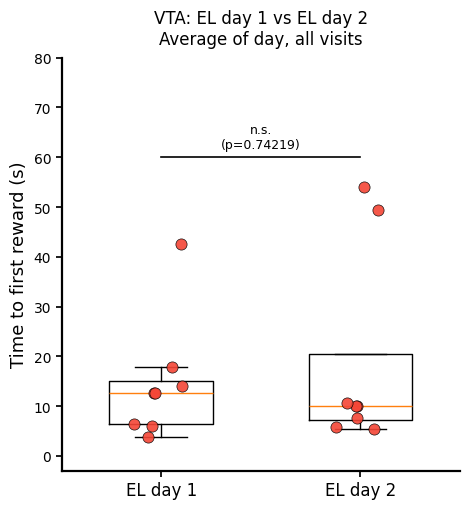


Boxplot: Average of day, EL mode = pooled
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=9.502, EL mean=15.568, L day 5 median=8.475, EL median=9.890, stat=11.000, p=0.10547


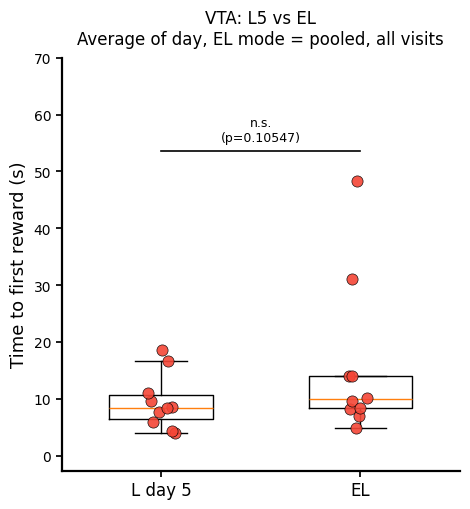


Boxplot: Best trial of day, EL mode = pooled
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=1.140, EL mean=0.582, L day 5 median=0.863, EL median=0.644, stat=18.000, p=0.37500


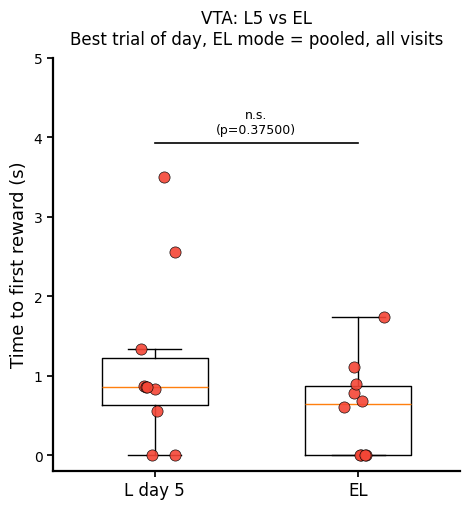


Boxplot: Final trial, trial 8, EL mode = pooled
Animals/observations included:
['AB pooled EL', 'AC pooled EL', 'AD pooled EL', 'AE pooled EL', 'AF pooled EL', 'AG pooled EL', 'AH pooled EL', 'AM pooled EL', 'AN pooled EL', 'AO pooled EL']
wilcoxon: n=10, L day 5 mean=6.153, EL mean=10.359, L day 5 median=3.639, EL median=6.527, stat=14.000, p=0.19336


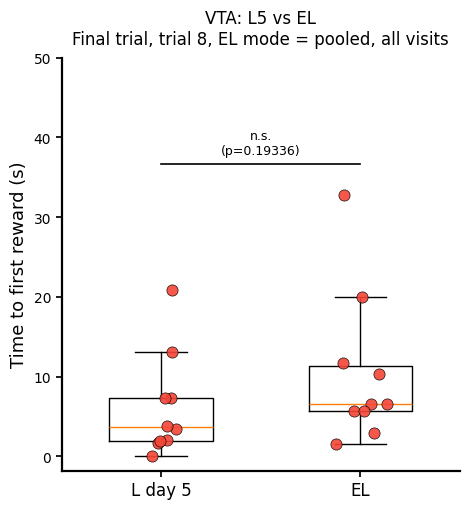


EL trial-by-trial progress plot
EL day mode: pooled
SEM style: shaded
Using: t_to_trigger (all visits)
  Pooled EL day 1+2: n = 10, ids = ['AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


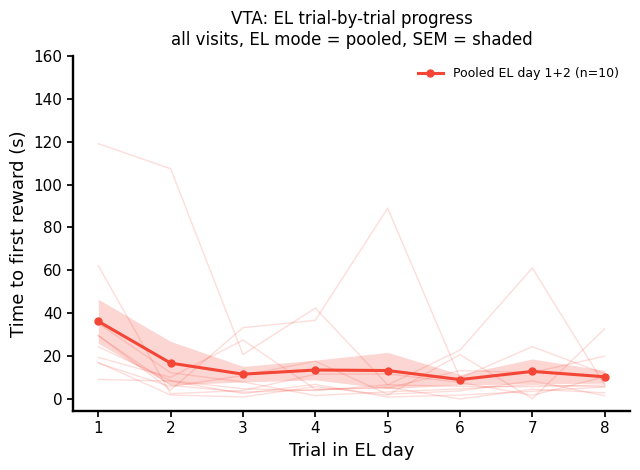

In [321]:
# ============================================================
# Extra learning EL vs last learning day L5
# Genotype: ChR2
#
# Produces:
#   0) Boxplot: EL day 1 vs EL day 2
#      Default metric = average of EL day
#
#   1) Boxplot: average EL day vs average L day 5
#   2) Boxplot: best EL trial vs best L day 5 trial
#   3) Boxplot: final EL trial 8 vs final L day 5 trial 8
#
#   4) EL trial-by-trial progress plot across trials 1-8
#      This follows EL_DAY_MODE:
#         'day1'     -> EL day 1 only
#         'day2'     -> EL day 2 only
#         'separate' -> EL day 1 and EL day 2 separately
#         'pooled'   -> EL day 1 and EL day 2 pooled per animal/trial
#
# EL trial_type_day can be 1 or 2.
#
# EL_DAY_MODE:
#   'separate'
#       EL day 1 and EL day 2 are treated as separate observations.
#
#   'day1'
#       only EL trial_type_day == 1
#
#   'day2'
#       only EL trial_type_day == 2
#
#   'pooled'
#       EL day 1 and EL day 2 are averaged per animal first.
#       One EL value per animal.
#
# Visit criterion:
#   USE_LONG_VISITS = False -> t_to_trigger      = all visits
#   USE_LONG_VISITS = True  -> t_to_trigger_long = ≥2 s stay
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

USE_LONG_VISITS = False
# USE_LONG_VISITS = False

EL_DAY_MODE = 'pooled'
# EL_DAY_MODE = 'day1'
# EL_DAY_MODE = 'day2'
# EL_DAY_MODE = 'separate'
# EL_DAY_MODE = 'pooled'

FILTER_SHORT_DURATION = False

EXCLUDE_ID = ['BQ', 'BP']
EXCLUDE_SUBS = []

SHOW_ANIMAL_IDS = False

# No paired lines by default
SHOW_PAIRED_LINES = False

FINAL_TRIAL_N = 8

# If True, require each paired comparison to have both values.
REQUIRE_PAIRED = True

# Stats:
#   wilcoxon is paired and best for same-animal comparisons.
#   mannwhitney is unpaired.
STAT_TEST = 'wilcoxon'
# STAT_TEST = 'mannwhitney'

# EL1 vs EL2 boxplot metric:
#   'avg'   -> average of all 8 trials
#   'best'  -> best trial = minimum time
#   'final' -> final trial = trial 8
EL1_VS_EL2_METRIC = 'avg'
# EL1_VS_EL2_METRIC = 'best'
# EL1_VS_EL2_METRIC = 'final'

# ------------------------------------------------------------
# EL trial-by-trial progress plot options
# ------------------------------------------------------------
RUN_EL_TRIAL_PROGRESS_PLOT = True
PLOT_EL_INDIVIDUAL_LINES = True

# New option:
#   'bar'    -> SEM error bars
#   'shaded' -> shaded SEM area
#   'none'   -> mean line only
EL_PROGRESS_SEM_STYLE = 'shaded'
# EL_PROGRESS_SEM_STYLE = 'shaded' or 'bar'
# EL_PROGRESS_SEM_STYLE = 'none'

EL_TRIAL_YMIN = None
EL_TRIAL_YMAX = None
EL_TRIAL_Y_ZERO_PAD_FRAC = 0.04
EL_TRIAL_Y_TOP_PAD_FRAC = 0.18

# Plot styling
JITTER = 0.06
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5
P_DECIMALS = 5

BOX_YMIN = None
BOX_YMAX = None
BOX_Y_BOTTOM_PAD_FRAC = 0.04
BOX_Y_TICK_STEP = None

P_LINE_START_FRAC = 0.12
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.22

np.random.seed(1)

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'NAc': 'NAc',
    'ArchT': 'ArchT',
    'eYFP_ArchT': 'eYFP ArchT',
    'WT': 'WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

if EL_DAY_MODE not in ['separate', 'day1', 'day2', 'pooled']:
    raise ValueError("EL_DAY_MODE must be 'separate', 'day1', 'day2', or 'pooled'")

if STAT_TEST not in ['wilcoxon', 'mannwhitney']:
    raise ValueError("STAT_TEST must be 'wilcoxon' or 'mannwhitney'")

if EL1_VS_EL2_METRIC not in ['avg', 'best', 'final']:
    raise ValueError("EL1_VS_EL2_METRIC must be 'avg', 'best', or 'final'")

if EL_PROGRESS_SEM_STYLE not in ['bar', 'shaded', 'none']:
    raise ValueError("EL_PROGRESS_SEM_STYLE must be 'bar', 'shaded', or 'none'")


# ============================================================
# Helper functions
# ============================================================

def get_plot_color(genotype):
    try:
        return get_genotype_color(genotype)
    except Exception:
        return '0.3'


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.7):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.25)
    ax.grid(False)


def apply_box_y_axis(ax, all_vals, stat_y=None):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        y_top = 1.0
    else:
        y_top = np.nanmax(all_vals)

        if stat_y is not None and np.isfinite(stat_y):
            y_top = max(y_top, stat_y)

        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if BOX_YMAX is not None:
        y_top = BOX_YMAX
    else:
        y_top = y_top * (1 + P_TOP_PAD_FRAC)

    if BOX_YMIN is not None:
        y_bottom = BOX_YMIN
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        ax.set_yticks(np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)


def add_trial_in_day(meta_df):
    """
    Adds trial_in_day = 1..8.

    Uses existing trial column if present.
    Otherwise infers from sub/ses order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
        'trial_id',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        meta_df = meta_df.sort_values(['sub', 'ses']).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    meta_df = meta_df[meta_df['trial_in_day'].between(1, 8)].copy()

    return meta_df, trial_col


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def trial_summary(ms, value_col):
    """
    Returns:
      average value across trials
      best value = minimum time
      final trial value = trial_in_day == FINAL_TRIAL_N
    """
    if len(ms) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    by_trial = (
        ms.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return {
            'avg': np.nan,
            'best': np.nan,
            'final': np.nan,
        }

    avg_val = float(np.nanmean(by_trial.values))
    best_val = float(np.nanmin(by_trial.values))

    if FINAL_TRIAL_N in by_trial.index:
        final_val = float(by_trial.loc[FINAL_TRIAL_N])
    else:
        final_val = np.nan

    return {
        'avg': avg_val,
        'best': best_val,
        'final': final_val,
    }


def run_stat(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)

    if STAT_TEST == 'wilcoxon':
        a = a[ok]
        b = b[ok]

        if len(a) == 0:
            return np.nan, np.nan

        # Wilcoxon fails if all paired differences are exactly zero.
        if np.allclose(a, b, equal_nan=False):
            return np.nan, 1.0

        stat, p = wilcoxon(a, b, alternative='two-sided')
        return stat, p

    if STAT_TEST == 'mannwhitney':
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]

        if len(a) == 0 or len(b) == 0:
            return np.nan, np.nan

        stat, p = mannwhitneyu(a, b, alternative='two-sided')
        return stat, p

    return np.nan, np.nan


def add_sig_bar(ax, positions, p, all_vals):
    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    if len(all_vals) == 0:
        return

    ymax = np.nanmax(all_vals)
    ymin = np.nanmin(all_vals)
    yrng = ymax - ymin

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(ymax), 1.0)

    y = ymax + P_LINE_START_FRAC * yrng

    ax.plot(
        [positions[0], positions[1]],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        np.mean(positions),
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    apply_box_y_axis(ax, all_vals, stat_y=y)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


# ============================================================
# 1. Filter metadata
# ============================================================

needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    TIME_COL,
]

if FILTER_SHORT_DURATION:
    needed_cols.append('short_duration')

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'EL'])) &
    (metadata[TIME_COL].notna()) &
    (np.isfinite(metadata[TIME_COL]))
].copy()

if FILTER_SHORT_DURATION:
    meta = meta[meta['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
    meta = meta[
        ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta = meta[
        ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# Keep L5 and EL1/EL2 only
meta_L5 = meta[
    (meta['trial_type'] == 'L') &
    (meta['trial_type_day'] == 5)
].copy()

meta_EL = meta[
    (meta['trial_type'] == 'EL') &
    (meta['trial_type_day'].isin([1, 2]))
].copy()

if EL_DAY_MODE == 'day1':
    meta_EL = meta_EL[meta_EL['trial_type_day'] == 1].copy()

elif EL_DAY_MODE == 'day2':
    meta_EL = meta_EL[meta_EL['trial_type_day'] == 2].copy()

meta_L5, trial_col_L5 = add_trial_in_day(meta_L5)
meta_EL, trial_col_EL = add_trial_in_day(meta_EL)

# This keeps all EL days for EL1-vs-EL2 and progress plot,
# regardless of whether meta_EL was restricted by EL_DAY_MODE above.
meta_EL_all = meta[
    (meta['trial_type'] == 'EL') &
    (meta['trial_type_day'].isin([1, 2]))
].copy()
meta_EL_all, trial_col_EL_all = add_trial_in_day(meta_EL_all)

trial_col_used = trial_col_EL if trial_col_EL is not None else trial_col_L5

print("\n============================================================")
print("Extra learning EL vs L5")
print("Genotype:", GENOTYPE_TO_PLOT, f"({GROUP_LABEL})")
print("Using:", TIME_COL, f"({STAY_TAG})")
print("EL day mode:", EL_DAY_MODE)
print("EL1 vs EL2 metric:", EL1_VS_EL2_METRIC)
print("Stat test:", STAT_TEST)
print("EL progress SEM style:", EL_PROGRESS_SEM_STYLE)
print("Trial column used:", trial_col_used if trial_col_used is not None else "inferred from sub/ses order")
print("Filter short duration:", FILTER_SHORT_DURATION)

print("\nRows after filtering:")
cols_to_print = ['sub']
if 'id' in meta.columns:
    cols_to_print.append('id')
cols_to_print += ['genotype', 'trial_type', 'trial_type_day', 'ses', 'trial_in_day', TIME_COL]

rows_to_print = pd.concat([meta_L5, meta_EL], ignore_index=True)

if len(rows_to_print) > 0:
    print(
        rows_to_print[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")


# ============================================================
# 2. Build paired comparison dataframe: L5 vs EL
# ============================================================

rows = []

for sub in sorted(set(meta_L5['sub'].unique()).intersection(set(meta_EL['sub'].unique()))):
    ms_L5 = meta_L5[meta_L5['sub'] == sub].copy()

    if len(ms_L5) == 0:
        continue

    animal_id = get_animal_label(ms_L5, sub)
    l5_summary = trial_summary(ms_L5, TIME_COL)

    ms_EL_sub = meta_EL[meta_EL['sub'] == sub].copy()

    if EL_DAY_MODE in ['separate', 'day1', 'day2']:
        for el_day in sorted(ms_EL_sub['trial_type_day'].dropna().unique()):
            ms_EL_day = ms_EL_sub[ms_EL_sub['trial_type_day'] == el_day].copy()

            if len(ms_EL_day) == 0:
                continue

            el_summary = trial_summary(ms_EL_day, TIME_COL)

            rows.append({
                'sub': sub,
                'id': animal_id,
                'el_day': int(el_day),
                'obs_label': f'{animal_id} EL{int(el_day)}',
                'L5_avg_ms': l5_summary['avg'],
                'EL_avg_ms': el_summary['avg'],
                'L5_best_ms': l5_summary['best'],
                'EL_best_ms': el_summary['best'],
                'L5_final_ms': l5_summary['final'],
                'EL_final_ms': el_summary['final'],
            })

    elif EL_DAY_MODE == 'pooled':
        el_day_summaries = []

        for el_day in sorted(ms_EL_sub['trial_type_day'].dropna().unique()):
            ms_EL_day = ms_EL_sub[ms_EL_sub['trial_type_day'] == el_day].copy()
            el_summary = trial_summary(ms_EL_day, TIME_COL)
            el_day_summaries.append(el_summary)

        if len(el_day_summaries) == 0:
            continue

        el_summary_pooled = {
            'avg': np.nanmean([d['avg'] for d in el_day_summaries]),
            'best': np.nanmin([d['best'] for d in el_day_summaries]),
            'final': np.nanmean([d['final'] for d in el_day_summaries]),
        }

        rows.append({
            'sub': sub,
            'id': animal_id,
            'el_day': 'pooled',
            'obs_label': f'{animal_id} pooled EL',
            'L5_avg_ms': l5_summary['avg'],
            'EL_avg_ms': el_summary_pooled['avg'],
            'L5_best_ms': l5_summary['best'],
            'EL_best_ms': el_summary_pooled['best'],
            'L5_final_ms': l5_summary['final'],
            'EL_final_ms': el_summary_pooled['final'],
        })

compare_df = pd.DataFrame(rows)

if REQUIRE_PAIRED and len(compare_df) > 0:
    metric_pairs = [
        ('L5_avg_ms', 'EL_avg_ms'),
        ('L5_best_ms', 'EL_best_ms'),
        ('L5_final_ms', 'EL_final_ms'),
    ]

    keep = np.ones(len(compare_df), dtype=bool)

    for l5_col, el_col in metric_pairs:
        keep = keep & compare_df[l5_col].notna().values & compare_df[el_col].notna().values

    compare_df = compare_df[keep].copy()

print("\nComparison table, values in seconds:")
if len(compare_df) > 0:
    print_df = compare_df.copy()

    for col in [
        'L5_avg_ms', 'EL_avg_ms',
        'L5_best_ms', 'EL_best_ms',
        'L5_final_ms', 'EL_final_ms'
    ]:
        print_df[col.replace('_ms', '_s')] = print_df[col] / 1000.0

    print(
        print_df[
            [
                'sub', 'id', 'el_day', 'obs_label',
                'L5_avg_s', 'EL_avg_s',
                'L5_best_s', 'EL_best_s',
                'L5_final_s', 'EL_final_s',
            ]
        ].reset_index(drop=True)
    )
else:
    print("No paired L5/EL observations available.")


# ============================================================
# 2b. Build paired dataframe: EL day 1 vs EL day 2
# ============================================================

el12_rows = []

for sub in sorted(meta_EL_all['sub'].unique()):
    ms_sub = meta_EL_all[meta_EL_all['sub'] == sub].copy()

    ms_el1 = ms_sub[ms_sub['trial_type_day'] == 1].copy()
    ms_el2 = ms_sub[ms_sub['trial_type_day'] == 2].copy()

    if len(ms_el1) == 0 or len(ms_el2) == 0:
        continue

    animal_id = get_animal_label(ms_sub, sub)

    el1_summary = trial_summary(ms_el1, TIME_COL)
    el2_summary = trial_summary(ms_el2, TIME_COL)

    el12_rows.append({
        'sub': sub,
        'id': animal_id,
        'EL1_avg_ms': el1_summary['avg'],
        'EL2_avg_ms': el2_summary['avg'],
        'EL1_best_ms': el1_summary['best'],
        'EL2_best_ms': el2_summary['best'],
        'EL1_final_ms': el1_summary['final'],
        'EL2_final_ms': el2_summary['final'],
    })

el12_df = pd.DataFrame(el12_rows)

print("\nEL day 1 vs EL day 2 table, values in seconds:")
if len(el12_df) > 0:
    print_el12 = el12_df.copy()

    for col in [
        'EL1_avg_ms', 'EL2_avg_ms',
        'EL1_best_ms', 'EL2_best_ms',
        'EL1_final_ms', 'EL2_final_ms',
    ]:
        print_el12[col.replace('_ms', '_s')] = print_el12[col] / 1000.0

    print(
        print_el12[
            [
                'sub', 'id',
                'EL1_avg_s', 'EL2_avg_s',
                'EL1_best_s', 'EL2_best_s',
                'EL1_final_s', 'EL2_final_s',
            ]
        ].reset_index(drop=True)
    )
else:
    print("No animals with both EL day 1 and EL day 2.")


# ============================================================
# 3. Boxplot helpers
# ============================================================

def plot_two_condition_boxplot(
    plot_df,
    left_col,
    right_col,
    left_label,
    right_label,
    title_main,
    title_suffix,
    obs_label_col='obs_label'
):
    if len(plot_df) == 0:
        print(f"\nSkipping {title_suffix}: no data.")
        return

    plot_df = plot_df[
        plot_df[left_col].notna() &
        plot_df[right_col].notna()
    ].copy()

    if len(plot_df) == 0:
        print(f"\nSkipping {title_suffix}: no finite paired values.")
        return

    left_vals_s = plot_df[left_col].values.astype(float) / 1000.0
    right_vals_s = plot_df[right_col].values.astype(float) / 1000.0

    vals_groups = [left_vals_s, right_vals_s]
    positions = np.arange(2)

    stat, p = run_stat(left_vals_s, right_vals_s)

    if obs_label_col in plot_df.columns:
        obs_labels = list(plot_df[obs_label_col])
    else:
        obs_labels = list(plot_df['id'])

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print("Animals/observations included:")
    print(obs_labels)

    print(
        f"{STAT_TEST}: "
        f"n={len(left_vals_s)}, "
        f"{left_label} mean={np.nanmean(left_vals_s):.3f}, "
        f"{right_label} mean={np.nanmean(right_vals_s):.3f}, "
        f"{left_label} median={np.nanmedian(left_vals_s):.3f}, "
        f"{right_label} median={np.nanmedian(right_vals_s):.3f}, "
        f"stat={stat:.3f}, "
        f"p={format_p(p)}"
    )

    fig, ax = plt.subplots(figsize=(4.8, 5.2))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.52,
        patch_artist=False,
        showfliers=False
    )

    col = get_plot_color(GENOTYPE_TO_PLOT)

    if SHOW_PAIRED_LINES:
        for left_y, right_y in zip(left_vals_s, right_vals_s):
            ax.plot(
                positions,
                [left_y, right_y],
                '-',
                color='0.65',
                linewidth=0.8,
                alpha=0.55,
                zorder=1
            )

    for i, vals in enumerate(vals_groups):
        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=col,
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, obs_labels):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=col,
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    all_vals = np.r_[left_vals_s, right_vals_s]
    add_sig_bar(ax, positions, p, all_vals)

    ax.set_xticks(positions)
    ax.set_xticklabels([left_label, right_label], fontsize=12)

    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_title(
        f'{title_main}\n'
        f'{title_suffix}, {STAY_TAG}',
        fontsize=12,
        pad=10
    )

    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


def plot_l5_vs_el_boxplot(l5_col, el_col, title_suffix):
    plot_two_condition_boxplot(
        plot_df=compare_df,
        left_col=l5_col,
        right_col=el_col,
        left_label='L day 5',
        right_label='EL',
        title_main=f'{GROUP_LABEL}: L5 vs EL',
        title_suffix=f'{title_suffix}, EL mode = {EL_DAY_MODE}',
        obs_label_col='obs_label'
    )


def plot_el1_vs_el2_boxplot():
    metric_to_cols = {
        'avg': ('EL1_avg_ms', 'EL2_avg_ms', 'Average of day'),
        'best': ('EL1_best_ms', 'EL2_best_ms', 'Best trial of day'),
        'final': ('EL1_final_ms', 'EL2_final_ms', f'Final trial, trial {FINAL_TRIAL_N}'),
    }

    left_col, right_col, metric_title = metric_to_cols[EL1_VS_EL2_METRIC]

    plot_two_condition_boxplot(
        plot_df=el12_df,
        left_col=left_col,
        right_col=right_col,
        left_label='EL day 1',
        right_label='EL day 2',
        title_main=f'{GROUP_LABEL}: EL day 1 vs EL day 2',
        title_suffix=metric_title,
        obs_label_col='id'
    )


# ============================================================
# 4. Produce boxplots
# ============================================================

plot_el1_vs_el2_boxplot()

plot_l5_vs_el_boxplot(
    l5_col='L5_avg_ms',
    el_col='EL_avg_ms',
    title_suffix='Average of day'
)

plot_l5_vs_el_boxplot(
    l5_col='L5_best_ms',
    el_col='EL_best_ms',
    title_suffix='Best trial of day'
)

plot_l5_vs_el_boxplot(
    l5_col='L5_final_ms',
    el_col='EL_final_ms',
    title_suffix=f'Final trial, trial {FINAL_TRIAL_N}'
)


# ============================================================
# 5. EL trial-by-trial progress plot
# ============================================================

def build_el_trial_matrix(meta_el, mode):
    """
    Returns a dictionary of matrices for EL trial-by-trial plotting.

    Each matrix is animal x trial_in_day, values in ms.

    mode:
      'day1':
          one matrix for EL day 1 only

      'day2':
          one matrix for EL day 2 only

      'separate':
          one matrix for EL day 1 and one matrix for EL day 2

      'pooled':
          one matrix where EL1/EL2 are averaged per animal per trial
    """
    trials = np.arange(1, 9)
    matrices = {}

    if len(meta_el) == 0:
        return matrices

    if mode == 'day1':
        days_to_plot = [1]
    elif mode == 'day2':
        days_to_plot = [2]
    elif mode == 'separate':
        days_to_plot = [1, 2]
    elif mode == 'pooled':
        days_to_plot = ['pooled']
    else:
        raise ValueError("mode must be 'day1', 'day2', 'separate', or 'pooled'")

    if mode in ['day1', 'day2', 'separate']:

        for el_day in days_to_plot:
            md = meta_el[meta_el['trial_type_day'] == el_day].copy()

            if len(md) == 0:
                continue

            rows = []
            ids = []

            for sub in sorted(md['sub'].unique()):
                ms = md[md['sub'] == sub].copy()

                by_trial = (
                    ms.groupby('trial_in_day', as_index=True)[TIME_COL]
                      .mean()
                      .sort_index()
                )

                vals = np.array(
                    [by_trial.get(t, np.nan) for t in trials],
                    dtype=float
                )

                if np.all(np.isnan(vals)):
                    continue

                rows.append(vals)
                ids.append(get_animal_label(ms, sub))

            if len(rows) > 0:
                label = f'EL day {el_day}'
                matrices[label] = {
                    'mat': np.vstack(rows),
                    'ids': ids,
                }

    elif mode == 'pooled':

        rows = []
        ids = []

        for sub in sorted(meta_el['sub'].unique()):
            ms = meta_el[meta_el['sub'] == sub].copy()

            # Average EL1/EL2 per trial_in_day for each animal.
            by_trial = (
                ms.groupby('trial_in_day', as_index=True)[TIME_COL]
                  .mean()
                  .sort_index()
            )

            vals = np.array(
                [by_trial.get(t, np.nan) for t in trials],
                dtype=float
            )

            if np.all(np.isnan(vals)):
                continue

            rows.append(vals)
            ids.append(get_animal_label(ms, sub))

        if len(rows) > 0:
            matrices['Pooled EL day 1+2'] = {
                'mat': np.vstack(rows),
                'ids': ids,
            }

    return matrices


def plot_el_trial_progress():
    if not RUN_EL_TRIAL_PROGRESS_PLOT:
        return

    trials = np.arange(1, 9)

    # For the progress plot, follow EL_DAY_MODE.
    # This uses the same filtered meta_EL when day1/day2 are selected,
    # and uses all EL1/EL2 for separate/pooled.
    if EL_DAY_MODE in ['day1', 'day2']:
        progress_meta = meta_EL.copy()
    else:
        progress_meta = meta_EL_all.copy()

    matrices = build_el_trial_matrix(progress_meta, EL_DAY_MODE)

    print("\n============================================================")
    print("EL trial-by-trial progress plot")
    print("EL day mode:", EL_DAY_MODE)
    print("SEM style:", EL_PROGRESS_SEM_STYLE)
    print("Using:", TIME_COL, f"({STAY_TAG})")

    if len(matrices) == 0:
        print("No EL trial-by-trial data available.")
        return

    for label, item in matrices.items():
        print(f"  {label}: n = {item['mat'].shape[0]}, ids = {item['ids']}")

    fig, ax = plt.subplots(figsize=(6.5, 4.8))

    base_col = get_plot_color(GENOTYPE_TO_PLOT)

    # Slightly different colours for EL1/EL2 when separate.
    plot_cols = {
        'EL day 1': base_col,
        'EL day 2': '0.45',
        'Pooled EL day 1+2': base_col,
    }

    all_y_s = []

    for label, item in matrices.items():
        mat_ms = item['mat']
        mat_s = mat_ms / 1000.0

        col = plot_cols.get(label, base_col)

        if PLOT_EL_INDIVIDUAL_LINES:
            for row in mat_s:
                ax.plot(
                    trials,
                    row,
                    '-',
                    color=col,
                    alpha=0.18,
                    linewidth=1.0,
                    zorder=1
                )

        mean_s = np.full(len(trials), np.nan)
        sem_s = np.full(len(trials), np.nan)

        for i in range(len(trials)):
            m, s = mean_sem(mat_s[:, i])
            mean_s[i] = m
            sem_s[i] = s

        all_y_s.extend(list(mat_s[np.isfinite(mat_s)].ravel()))

        # ----------------------------------------------------
        # SEM display option
        # ----------------------------------------------------
        if EL_PROGRESS_SEM_STYLE == 'shaded':
            ax.fill_between(
                trials,
                mean_s - sem_s,
                mean_s + sem_s,
                color=col,
                alpha=0.22,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            trials,
            mean_s,
            'o-',
            color=col,
            linewidth=2.2,
            markersize=5,
            label=f'{label} (n={mat_ms.shape[0]})',
            zorder=3
        )

        if EL_PROGRESS_SEM_STYLE == 'bar':
            ax.errorbar(
                trials,
                mean_s,
                yerr=sem_s,
                fmt='none',
                ecolor=col,
                alpha=0.55,
                elinewidth=1.2,
                capsize=3,
                zorder=4
            )

    ax.set_xlabel('Trial in EL day', fontsize=13)
    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_xticks(trials)
    ax.set_xticklabels([str(t) for t in trials], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_title(
        f'{GROUP_LABEL}: EL trial-by-trial progress\n'
        f'{STAY_TAG}, EL mode = {EL_DAY_MODE}, SEM = {EL_PROGRESS_SEM_STYLE}',
        fontsize=12,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(frameon=False, fontsize=9)

    all_y_s = np.asarray(all_y_s, dtype=float)
    all_y_s = all_y_s[np.isfinite(all_y_s)]

    if len(all_y_s) > 0:
        if EL_TRIAL_YMAX is not None:
            y_top = EL_TRIAL_YMAX
        else:
            y_top = np.nanmax(all_y_s)
            if not np.isfinite(y_top) or y_top <= 0:
                y_top = 1.0
            y_top = y_top * (1 + EL_TRIAL_Y_TOP_PAD_FRAC)

        if EL_TRIAL_YMIN is not None:
            y_bottom = EL_TRIAL_YMIN
        else:
            y_bottom = -EL_TRIAL_Y_ZERO_PAD_FRAC * y_top

        ax.set_ylim(y_bottom, y_top)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    plt.tight_layout()
    plt.show()


plot_el_trial_progress()

# time to arrive at separate triggers

In [278]:
# COMPUTE time to arrive for each trigger separately
# ----- COMPUTE TIME TO TRIGGER (ANY) + PER-TRIGGER TIMES -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # only recruit usable trials

# ------------------------------------------------------------------
# OPTION: minimum dwell time in trigger zone (in ms)
#   - 2000 → must stay ≥ 2 s
#   - 0    → any entry counts
# ------------------------------------------------------------------
DWELL_MIN_MS = 0   # <--- change here if you want to relax/tighten criterion

# Define columns in metadata
metadata['t_to_trigger'] = 0        # time to first trigger (any trigger) meeting criterion
metadata['learned']      = False      # ever met criterion in any trigger?

R_TRIGGER = (10/1.2)  # radius defining trigger zone

# store per-trigger times here
trigger_rows = []  # each row: {trial_id, trigger_id, t_to_trigger_trig}

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue

    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i+1
        )
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

        # per-trigger: if we know nothing, set all triggers to trial duration
        for trig_id in range(1, trigger_num + 1):
            trigger_rows.append({
                'trial_id': trial_id,
                'trigger_id': trig_id,
                't_to_trigger_trig': t_to_trigger
            })
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
    
    # ------------------------------------------------------------------
    # Apply dwell-time criterion here ONLY
    # ------------------------------------------------------------------
    if DWELL_MIN_MS > 0:
        df_all_triggers_long = df_all_triggers[df_all_triggers['duration'] >= DWELL_MIN_MS]
    else:
        df_all_triggers_long = df_all_triggers

    # ---- original "first reward anywhere" metric ----
    if len(df_all_triggers_long) == 0:
        # never met criterion in any trigger → use trial duration
        t_to_trigger = position_.iloc[-1]['t']
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True

    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

    # ---- per-trigger times (first entry meeting criterion in each trigger) ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers_long[df_all_triggers_long['trigger_id'] == trig_id]
        if len(df_t) == 0:
            # never met criterion in THIS trigger → use trial duration
            t_trig = position_.iloc[-1]['t']
        else:
            t_trig = df_t.iloc[0]['t_enter']

        trigger_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            't_to_trigger_trig': t_trig
        })

# Build long-format per-trigger DataFrame and attach metadata columns
df_trig = pd.DataFrame(trigger_rows)

meta_trig = df_trig.merge(
    metadata,
    left_on='trial_id',   # integer from the loop
    right_index=True,     # metadata index 0..len-1
    how='left'
)

 11%|█         | 709/6620 [00:08<01:05, 89.96it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1185/6620 [00:13<00:52, 103.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 40%|███▉      | 2617/6620 [00:28<00:29, 137.52it/s]

...

 81%|████████  | 5360/6620 [00:56<00:12, 98.28it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6493/6620 [01:07<00:01, 126.74it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6620/6620 [01:08<00:00, 96.40it/s] 


ChR2 – Reward zone 1: n animals plotted = 12
  Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
ChR2 – Reward zone 2: n animals plotted = 12
  Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


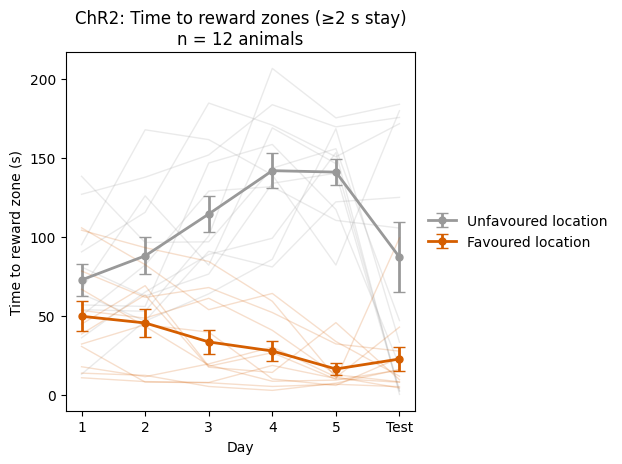

In [38]:

# ============================================================
# Time to reward zone (L1–L5 + first T as Test day 6)
#  - Genotype: choose 'ChR2', 'ChR2_short', or 'Hp'
#  - Zones: trigger_id 1 & 2
#  - Plot individual animals (faded) + group mean ± SEM
# ============================================================

# ---- choose genotype ----
GENOTYPE = 'ChR2'   # 'ChR2', 'ChR2_short', 'Hp'
genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ---- optional "≥2 s stay" tag in the title ----
SHOW_STAY_TAG = True   # set True if t_to_trigger_trig uses ≥2 s stay
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ------------------------------------------------------------
# 1) Filter meta_trig for chosen genotype, L/T, usable
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'].isin(['L', 'T'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# assign plot_day
mt['plot_day'] = np.nan

# L days: 1–5 from trial_type_day
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

# For each animal, find first T session AFTER last L session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)   # days 1–5 + Test(6)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Build subject × day matrices per reward zone
# ------------------------------------------------------------
def build_zone_matrix(mt_all, trigger_id):
    """
    For a given trigger_id, return:
      - matrix shape (n_animals, n_days)
      - list of subject IDs
    Animals are kept as long as they have SOME non-NaN across days.
    """
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]
    if mt_zone.empty:
        return None, []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days],
                        dtype=float)

        # keep animal if it has at least one valid day
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


zone_ids = [1, 2]  # only 2 reward zones

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"{genotype_label} – Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"  Animal IDs:", subs)
    print("-" * 50)

# ------------------------------------------------------------
# 3) Plot: per reward zone, individual + mean ± SEM
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Unfavoured location
    2: '#D55E00',  # Favoured location
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.size == 0:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,   # ms → s
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM (nan-aware)
    mean_vals = np.nanmean(mat, axis=0)
    n_per_day = np.sum(~np.isnan(mat), axis=0)
    sem_vals  = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(np.maximum(n_per_day, 1))

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

plt.xlabel('Day')
plt.ylabel('Time to reward zone (s)')
plt.title(
    f'{genotype_label}: Time to reward zones{STAY_TAG}\n'
    f'n = {n_animals} animals',
    fontsize=12
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

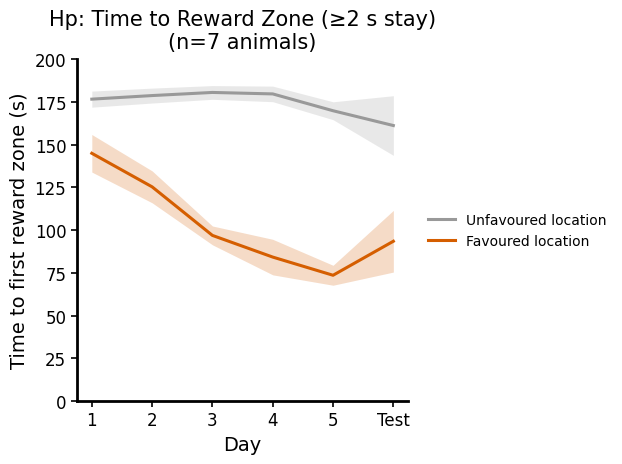

In [16]:
# ----- PLOT: ChR2, PER REWARD ZONE, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM (in seconds)
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )

    # ---- mean line (no individual traces) ----
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'Hp: Time to Reward Zone (≥2 s stay)\n'
    f'(n={n_animals} animals)',
    fontsize=15,
    pad=8
)
# (≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.ylim(0, 200)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Animals included:
  VTA (ChR2), Unfavoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA (ChR2), Favoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA short (ChR2_short), Unfavoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA short (ChR2_short), Favoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1), Unfavoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA1 (CA1), Favoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3), Unfavoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA3 (CA3), Favoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C

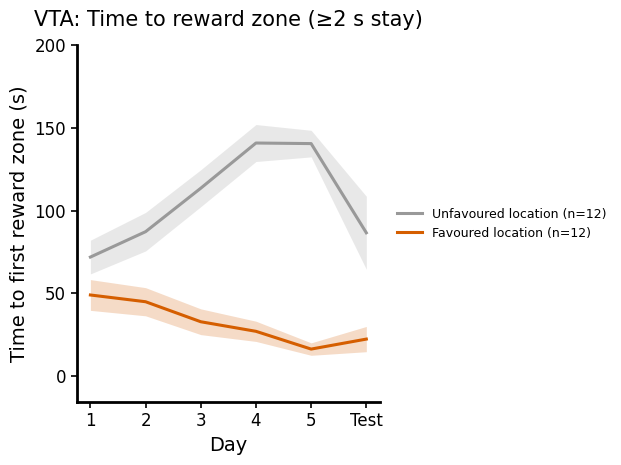

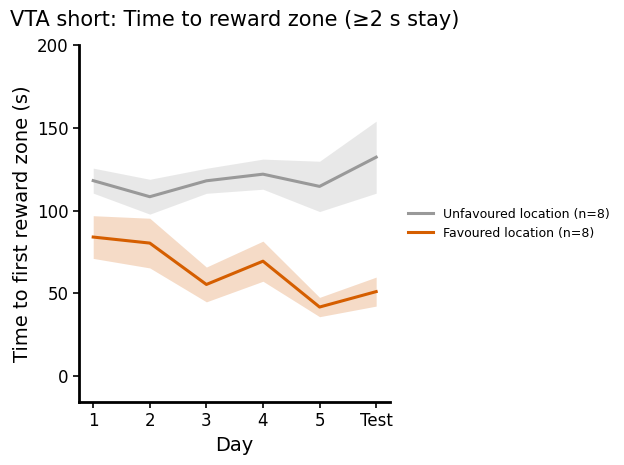

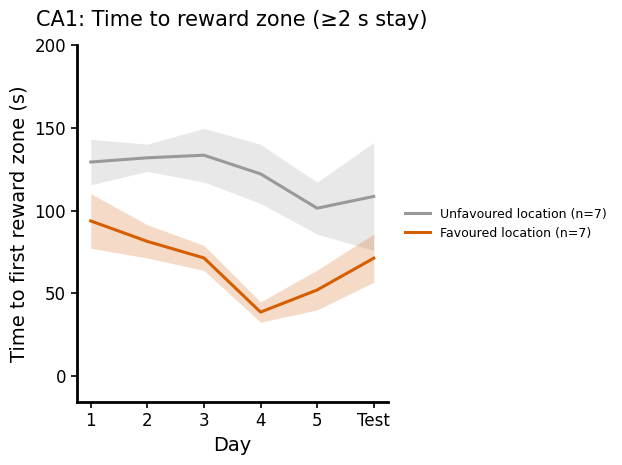

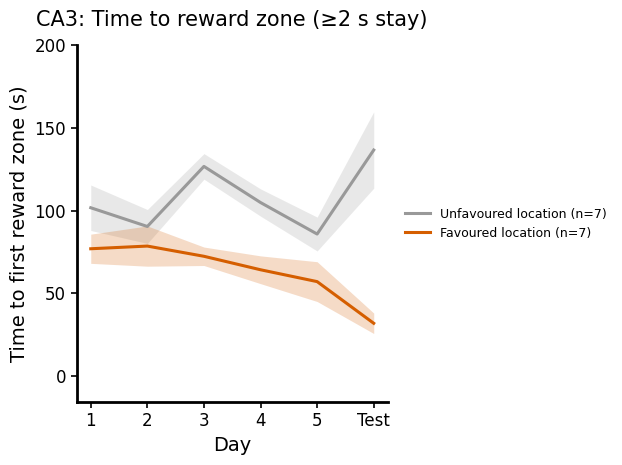

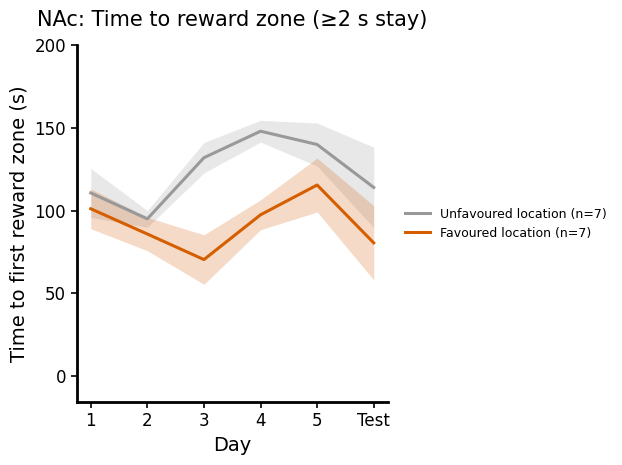

In [128]:
# ============================================================
# Time to reward zone across L1-L5 + Test
# Flexible groups
# Zones: trigger_id 1 & 2
# Plot group mean ± SEM, with optional shading and individual traces
# Requires meta_trig with:
#   - trigger_id
#   - t_to_trigger_trig
# ============================================================

# ============================================================
# OPTIONS
# ============================================================

GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'NAc']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['CA1', 'CA3', 'CA1_control']

EXCLUDE_ID = ['AS', 'AN']      # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []              # e.g. [43]

ZONE_IDS = [1, 2]

ZONE_LABELS = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

ZONE_COLORS = {
    1: '#999999',
    2: '#D55E00',
}

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

PLOT_MODE = 'separate_figures'   # 'separate_figures' or 'same_figure'

REQUIRE_COMPLETE = False         # True -> only animals with all L1-L5 + Test
PLOT_INDIVIDUAL = False          # True -> faded individual animal traces
SHOW_SEM_SHADING = True          # False -> no shaded SEM band
SHOW_SEM_ERRORBARS = False       # True -> SEM error bars on mean line

SHOW_STAY_TAG = True             # set True if t_to_trigger_trig uses ≥2 s stay
STAY_TAG = ' (≥2 s stay)' if SHOW_STAY_TAG else ''

# Y-axis options
YMIN = None                      # None -> automatically below 0
YMAX = 200                       # e.g. 200, or None for auto
Y_BOTTOM_PAD_FRAC = 0.08         # used if YMIN is None; larger raises 0 more
Y_TICK_STEP = 50                 # e.g. 20, 50, etc.

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1. Filter metadata
# ============================================================

mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'].isin(GROUPS)) &
    (meta_trig['trial_type'].isin(['L', 'T'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    mt = mt[
        ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    mt = mt[
        ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 2. Assign plot_day: L1-L5 + first post-learning T = Test day 6
# ============================================================

mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
mt = mt[
    (~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]

    mt.loc[idx, 'plot_day'] = 6

mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ============================================================
# 3. Helpers
# ============================================================

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.2)

def apply_y_axis(ax, ymax_candidates=None):
    if YMAX is not None:
        ymax = YMAX
    else:
        if ymax_candidates is None or len(ymax_candidates) == 0:
            ymax = 200
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 200
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    # integer tick labels
    yticks = np.arange(0, int(np.ceil(ymax)) + 1, Y_TICK_STEP)
    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)

def build_zone_matrix(mt_all, genotype, trigger_id):
    """
    Returns:
      - matrix: animal x day, in ms
      - subjects
      - animal_ids
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_zone = mt_all[
        (mt_all['genotype'] == genotype) &
        (mt_all['trigger_id'] == trigger_id)
    ].copy()

    if mt_zone.empty:
        return None, [], []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

# ============================================================
# 4. Build matrices
# ============================================================

zone_data = {}

print("Animals included:")
for g in GROUPS:
    zone_data[g] = {}

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_matrix(mt, g, zid)

        zone_data[g][zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {DISPLAY_NAME.get(g, g)} ({g}), {ZONE_LABELS.get(zid, f'Zone {zid}')}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

# ============================================================
# 5A. Plot: one figure per genotype, zone 1 vs zone 2
# ============================================================

if PLOT_MODE == 'separate_figures':

    for g in GROUPS:
        fig, ax = plt.subplots(figsize=(7.5, 5))

        ymax_candidates = []

        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            # ms -> s
            mean_ms = np.nanmean(mat, axis=0)
            sem_ms = sem_by_day(mat)

            mean_s = mean_ms / 1000.0
            sem_s = sem_ms / 1000.0

            col = ZONE_COLORS.get(zid, get_genotype_color(g))
            label = ZONE_LABELS.get(zid, f'Reward zone {zid}')

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row / 1000.0,
                        '-',
                        color=col,
                        alpha=0.12,
                        linewidth=1.0,
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_s - sem_s,
                    mean_s + sem_s,
                    color=col,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_s,
                '-',
                color=col,
                linewidth=2.2,
                label=f'{label} (n={len(subs)})',
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_s,
                    yerr=sem_s,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.2,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_s + sem_s))

        ax.set_xlabel('Day', fontsize=14)
        ax.set_ylabel('Time to first reward zone (s)', fontsize=14)

        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

        style_nature(ax)

        ax.set_title(
            f'{DISPLAY_NAME.get(g, g)}: Time to reward zone{STAY_TAG}',
            fontsize=15,
            pad=14
        )

        ax.legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=9
        )

        apply_y_axis(ax, ymax_candidates)

        plt.tight_layout(rect=[0, 0, 0.85, 0.95])
        plt.show()

# ============================================================
# 5B. Plot: all groups/zones on same figure
# ============================================================

elif PLOT_MODE == 'same_figure':

    fig, ax = plt.subplots(figsize=(8, 5.2))

    line_styles = {
        1: '-',
        2: '--',
    }

    ymax_candidates = []

    for g in GROUPS:
        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_ms = np.nanmean(mat, axis=0)
            sem_ms = sem_by_day(mat)

            mean_s = mean_ms / 1000.0
            sem_s = sem_ms / 1000.0

            col = get_genotype_color(g)
            label = (
                f'{DISPLAY_NAME.get(g, g)} '
                f'{ZONE_LABELS.get(zid, f"Zone {zid}")} '
                f'(n={len(subs)})'
            )

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row / 1000.0,
                        line_styles.get(zid, '-'),
                        color=col,
                        alpha=0.08,
                        linewidth=0.9,
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_s - sem_s,
                    mean_s + sem_s,
                    color=col,
                    alpha=0.08,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_s,
                line_styles.get(zid, '-'),
                color=col,
                linewidth=2.1,
                label=label,
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_s,
                    yerr=sem_s,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.0,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_s + sem_s))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward zone (s)', fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax)

    ax.set_title(
        f'Time to reward zone{STAY_TAG}',
        fontsize=15,
        pad=10
    )

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8
    )

    apply_y_axis(ax, ymax_candidates)

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()

else:
    raise ValueError("PLOT_MODE must be 'separate_figures' or 'same_figure'")

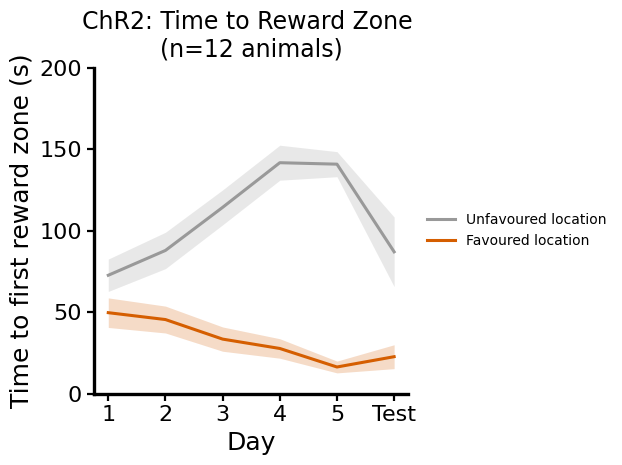

In [39]:
# ChR2 per reward zone - clean figure (larger axes, legend right, vector export)
import os

out_dir = "/Users/stella/Desktop/vector_files"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )
    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# Axes + style (bigger axis text)
ax.set_xlabel('Day', fontsize=18)
ax.set_ylabel('Time to first reward zone (s)', fontsize=18)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.4)
ax.spines['left'].set_linewidth(2.4)
ax.tick_params(direction='out', length=5, width=1.6)

ax.set_title(
    f'ChR2: Time to Reward Zone \n'
    f'(n={n_animals} animals)',
    fontsize=17,
    pad=8
 )
ax.set_ylim(0, 200)

# Legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.tight_layout(rect=[0, 0, 0.85, 0.95])
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_clean.svg'), bbox_inches='tight')
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_clean.pdf'), bbox_inches='tight')
plt.show()

Hp – animals included per reward zone (L days 1–5):
  Reward zone 1: 7 animals
  Reward zone 2: 7 animals

Total unique animals included (any zone): 7
Animal IDs: [np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]


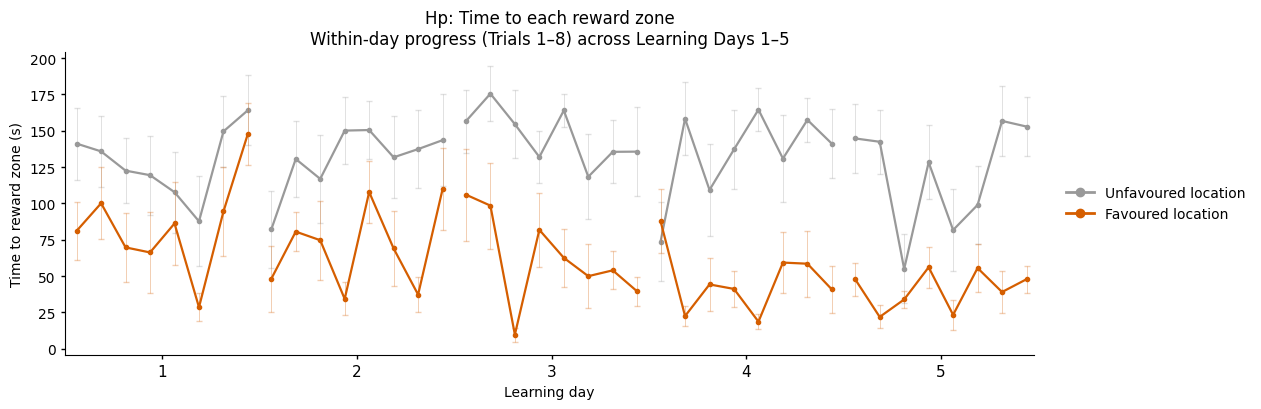

In [ ]:

from matplotlib.lines import Line2D

# ============================================================
# Trial-by-trial time to reward (L-only)
#  - Genotype: choose 'ChR2_short', 'ChR2', or 'Hp'
#  - 5 learning days (1–5)
#  - 8 trials per day
#  - Zones: trigger_id 1 & 2
# ============================================================

# ---- choose genotype ----
GENOTYPE = 'Hp'   # 'ChR2_short', 'ChR2', 'Hp'
genotype_label = {
    'ChR2_short': 'ChR2_short',
    'ChR2':       'ChR2',
    'Hp':         'Hp'
}[GENOTYPE]

# ---- toggle whether to display (≥2 s stay) ----
SHOW_STAY_TAG = False            # <--- change this
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

days   = np.arange(1, 6)
trials = np.arange(1, 9)
zone_ids = [1,2]


# ------------------------------------------------------------
# 1) Filter meta_trig for chosen genotype, L only, days 1–5
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have a per-trial index (trial_in_day = 1..8)
# ------------------------------------------------------------
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index': 'trial_id'})

trial_table = (
    mt[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

trial_table['trial_in_day'] = trial_table.groupby(
    ['sub', 'ses', 'trial_type_day']
).cumcount() + 1
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

mt = mt.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for one day & one zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id):
    md = mt_all[
        (mt_all['trial_type_day'] == day) &
        (mt_all['trigger_id'] == zone_id)
    ]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials],
                        dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, mt_all, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_ / 1000.0,     # ms → s
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_ / 1000.0, yerr=sem_ / 1000.0,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Plot for chosen genotype
# ------------------------------------------------------------
colors = {
    1: '#999999',  # Unfavoured location
    2: '#D55E00',  # Favoured location
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        mt,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

# ---- X/Y labels, ticks, style ----
ax.set_xlabel('Learning day')
ax.set_ylabel('Time to reward zone (s)')

# center ticks under each day block
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days], fontsize=11)

ax.set_xlim(1.0, 5.98)


ax.set_title(
    f'{genotype_label}: Time to each reward zone{STAY_TAG}\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

# journal / NN style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=3, width=1)
ax.grid(False)

legend_handles = [
    Line2D([0], [0], color=colors[1], lw=2, marker='o', label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=2, marker='o', label=labels[2]),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# animal counts (info)
subs_zone = {
    zid: sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}
print(f"{genotype_label} – animals included per reward zone (L days 1–5):")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Hp – First-choice analysis (L trials only)

Total L-trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 58 trials
  Day 5: 56 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1 (unfav)=35, Zone2 (fav)=21
  Day 2:  Zone1 (unfav)=30, Zone2 (fav)=26
  Day 3:  Zone1 (unfav)=17, Zone2 (fav)=39
  Day 4:  Zone1 (unfav)=10, Zone2 (fav)=48
  Day 5:  Zone1 (unfav)=10, Zone2 (fav)=46

Proportions (% of trials):
  Day 1:  Zone1 (unfav)=62.5%, Zone2 (fav)=37.5%
  Day 2:  Zone1 (unfav)=53.6%, Zone2 (fav)=46.4%
  Day 3:  Zone1 (unfav)=30.4%, Zone2 (fav)=69.6%
  Day 4:  Zone1 (unfav)=17.2%, Zone2 (fav)=82.8%
  Day 5:  Zone1 (unfav)=17.9%, Zone2 (fav)=82.1%



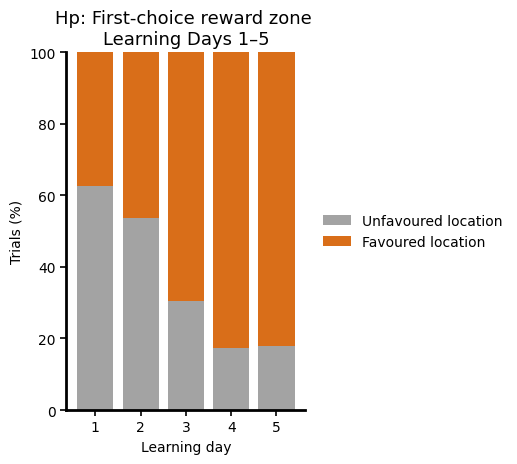

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# First-choice zone (% of trials) for L trials only
#  - Genotype: choose 'ChR2', 'ChR2_short', or 'Hp'
#  - Days: L1–L5 (trial_type_day 1–5)
#  - Zones: 1 = unfavoured, 2 = favoured
# ============================================================

# ---- choose genotype here ----
GENOTYPE = 'Hp'      # 'ChR2', 'ChR2_short', or 'Hp'

genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ---- toggle whether to display (≥2 s stay) ----
SHOW_STAY_TAG = False            # <--- change this
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ------------------------------------------------------------
# 1) Filter: chosen genotype, L only, not short
# ------------------------------------------------------------
days = np.arange(1, 6)   # L1–L5

mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# Use trial_type_day directly as "plot_day"
mt['plot_day'] = mt['trial_type_day'].astype(int)

plot_days = days  # [1..5]

# ------------------------------------------------------------
# 2) First-choice per trial: earliest t_to_trigger_trig
# ------------------------------------------------------------
mt_use = mt.copy()

# one row per trial = the trigger_id with minimal latency
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# ------------------------------------------------------------
# 3) Count choices per day × trigger
#    (only zones 1 & 2 – unfavoured / favoured)
# ------------------------------------------------------------
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2], fill_value=0)
)

# Total L trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)   # 0 if no trials that day

# ------------------------------------------------------------
# 4) Print summary
# ------------------------------------------------------------
print("====================================")
print(f"{genotype_label} – First-choice analysis (L trials only)")
print("====================================")

print("\nTotal L-trials per day:")
for d in plot_days:
    print(f"  Day {d}: {int(total_trials.loc[d])} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(
        f"  Day {d}:  "
        f"Zone1 (unfav)={int(row.get(1, 0))}, "
        f"Zone2 (fav)={int(row.get(2, 0))}"
    )

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(
        f"  Day {d}:  "
        f"Zone1 (unfav)={row[1]*100:.1f}%, "
        f"Zone2 (fav)={row[2]*100:.1f}%"
    )
print("====================================\n")

# ------------------------------------------------------------
# 5) Plot stacked bars (Zone1 vs Zone2)
# ------------------------------------------------------------
colors = {
    1: '#999999',   # unfavoured
    2: '#D55E00',   # favoured
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

fig, ax = plt.subplots(figsize=(6.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2]:
    vals = proportions[trig_id].values * 100  # to %
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.9,
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in plot_days])
ax.set_xlabel('Learning day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title(
    f'{genotype_label}: First-choice reward zone {STAY_TAG}\n'
    'Learning Days 1–5',
    fontsize=13
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

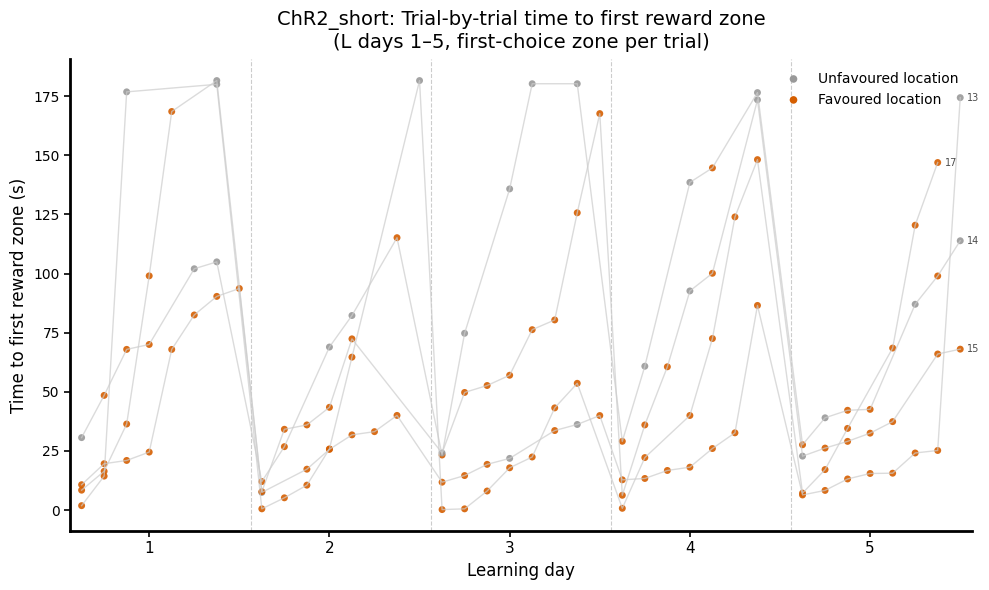

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Trial-by-trial time to first reward zone (L only)
# Genotype: 'ChR2', 'ChR2_short', or 'Hp'
# Zone 1 = unfavoured, Zone 2 = favoured
# Days: L1–L5, 8 trials/day → 40 trials total
# ============================================================

# ---- choose genotype here ----
GENOTYPE = 'ChR2_short'   # 'ChR2', 'ChR2_short', or 'Hp'

genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ------------------------------------------------------------
# 1) Filter: chosen genotype, L-only, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L')
].copy()

# Use L days 1–5 from trial_type_day
mt = mt[mt['trial_type_day'].isin([1, 2, 3, 4, 5])].copy()
mt['plot_day'] = mt['trial_type_day'].astype(int)

# Keep only zones 1 & 2 (unfavoured / favoured)
mt = mt[mt['trigger_id'].isin([1, 2])].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses) by time
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
group_key = 'trial_id'
if group_key not in mt.columns:
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..40)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (
    (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']
)

# Only L days 1–5 are used
mt_use = first_choice[first_choice['plot_day'].between(1, 5)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',   # unfavoured
    2: '#D55E00',   # favoured
}

zone_labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

# plot each animal
for sub in sorted(mt_use['sub'].unique()):
    ms = mt_use[mt_use['sub'] == sub].sort_values(['plot_day', 'trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0  # ms → s

    # grey animal-wise trajectory
    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    # coloured points by first-choice zone
    for zid in [1, 2]:
        ms_z = ms[ms['trigger_id'] == zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values) / 1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    # label animal at last trial
    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 L days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators between days
for d in range(1, max_day):
    ax.axvline(d * trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x-tick labels at center of each day block
day_centers = [(d - 0.5) * trials_per_day for d in range(1, max_day + 1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day + 1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Learning day', fontsize=12)
ax.set_ylabel('Time to first reward zone (s)', fontsize=12)

# legend for zones
handles = []
labels = []
for zid in [1, 2]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title(
    f'{genotype_label}: Trial-by-trial time to first reward zone\n'
    '(L days 1–5, first-choice zone per trial)',
    fontsize=14,
    pad=8
)

plt.tight_layout()
plt.show()

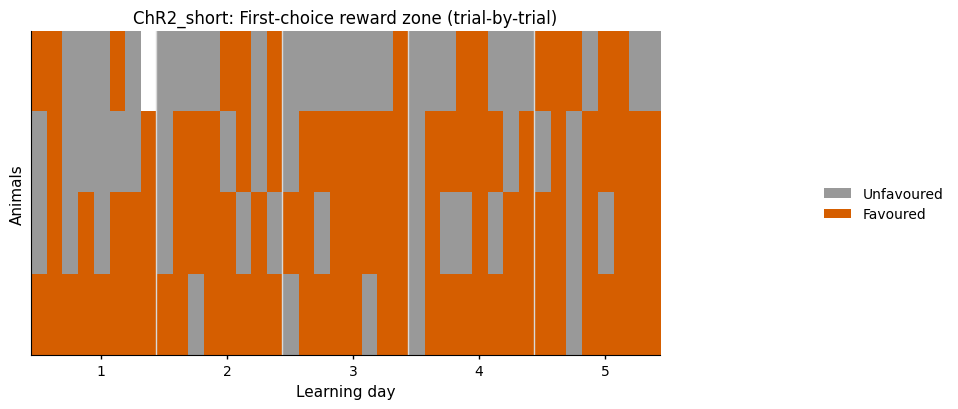

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

# =======================================
# SETTINGS
# =======================================
GENOTYPE = 'ChR2_short'   # 'ChR2', 'ChR2_short', 'Hp'
days = np.arange(1, 6)    # L1–L5
trials_per_day = 8

zone_colors = {
    1: '#999999',  # unfavoured
    2: '#D55E00',   # favoured
}

zone_labels = {
    1: 'Unfavoured',
    2: 'Favoured',
}

# =======================================
# 1) Filter L-only for genotype
# =======================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# =======================================
# 2) Per-trial index (1..8)
# =======================================
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index':'trial_id'})

trial_table = (
    mt[['trial_id','sub','ses','trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub','ses','trial_type_day','trial_id'])
)

trial_table['trial_in_day'] = trial_table.groupby(
    ['sub','ses','trial_type_day']
).cumcount() + 1

trial_table = trial_table[trial_table['trial_in_day'].between(1, trials_per_day)]
mt = mt.merge(trial_table[['trial_id','trial_in_day']], on='trial_id', how='inner')

# =======================================
# 3) first-choice zone = min t_to_trigger_trig per trial
# =======================================
idx_first = mt.groupby('trial_id')['t_to_trigger_trig'].idxmin()
fc = mt.loc[idx_first].copy()

fc = fc[fc['trigger_id'].isin([1,2])]   # only two zones

# global trial index = 1..40
fc['trial_idx_global'] = (
    (fc['trial_type_day'] - 1)*trials_per_day + fc['trial_in_day']
)

max_idx = len(days)*trials_per_day   # = 40

# =======================================
# 4) Build animal × trial matrix
# =======================================
animals = sorted(fc['sub'].unique())
n_animals = len(animals)

mat = np.zeros((n_animals, max_idx), dtype=int)

for i, sub in enumerate(animals):
    ms = fc[fc['sub'] == sub]
    for _, r in ms.iterrows():
        ti = int(r['trial_idx_global'])-1
        mat[i, ti] = int(r['trigger_id'])

# =======================================
# 5) sort animals by early preference
# =======================================
early = mat[:, :2*trials_per_day].astype(float)
late  = mat[:, -2*trials_per_day:].astype(float)
early[early==0]=np.nan
late[late==0]=np.nan
mE = np.nanmean(early, axis=1)
mL = np.nanmean(late, axis=1)

order = np.lexsort((mL, mE))
mat = mat[order]
animals_sorted = [animals[i] for i in order]

# =======================================
# 6) PLOT (publication style)
# =======================================
fig, ax = plt.subplots(figsize=(8, 4.2))

cmap = ListedColormap(['white', zone_colors[1], zone_colors[2]])
norm = BoundaryNorm([-0.5,0.5,1.5,2.5], cmap.N)

im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm)

# day separators
for d in range(1, len(days)):
    ax.axvline(d*trials_per_day-0.5, color='0.85', lw=1.0)

# x ticks centered on each day
centers = [(d-0.5)*trials_per_day for d in days]
ax.set_xticks(centers)
ax.set_xticklabels([str(d) for d in days], fontsize=10)

# y axis: small, no clutter
ax.set_yticks([])
ax.set_ylabel('Animals', fontsize=11)
ax.set_xlabel('Learning day', fontsize=11)

# title
ax.set_title(
    f'{GENOTYPE}: First-choice reward zone (trial-by-trial)',
    fontsize=12,
    pad=6
)

# spines minimal
for s in ['top','right']:
    ax.spines[s].set_visible(False)

ax.tick_params(direction='out', length=3, width=1)

# legend outside
handles = [
    Patch(facecolor=zone_colors[1], label=zone_labels[1]),
    Patch(facecolor=zone_colors[2], label=zone_labels[2]),
]
fig.legend(
    handles=handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,1])
plt.show()

/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_80366/2320800996.py:51: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(mat,0)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


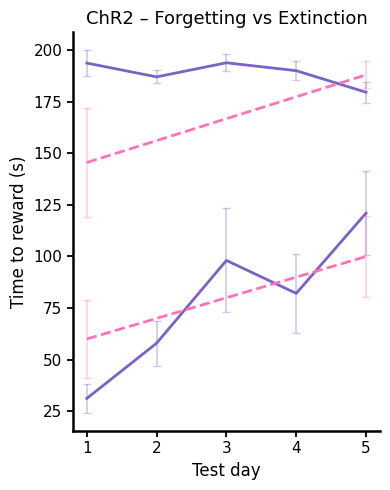

In [16]:
import numpy as np
import matplotlib.pyplot as plt

col_f = "#FF72B8"   # pink (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)

# ------------------------------------------------------------
# Filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction']))
].copy()

max_day = 5
day_values = np.arange(1, max_day+1)

# ------------------------------------------------------------
# helper: subject × day matrix per trigger
# ------------------------------------------------------------
def build_mat(df, trig):
    df = df[df['trigger_id']==trig]
    
    mats = []
    subs = []
    
    for sub in df['sub'].unique():
        ms = df[df['sub']==sub]
        m = ms.groupby('trial_type_day')['t_to_trigger_trig'].mean()
        
        # build 5-day vector (may contain NaNs)
        v = np.array([m.get(d, np.nan) for d in day_values], dtype=float)
        
        # NEW: keep animal if at least 1 valid day
        if np.isnan(v).all():
            continue
        
        mats.append(v)
        subs.append(sub)
    
    if len(mats)==0:
        return None, []
    
    return np.vstack(mats), subs

def mean_sem(mat):
    if mat is None or mat.size==0: return None,None
    mean = np.nanmean(mat,0)
    sem  = np.nanstd(mat,0)/np.sqrt(mat.shape[0])
    return mean, sem

# ------------------------------------------------------------
# Build matrices
# ------------------------------------------------------------
m_f_z1, s_f_z1 = build_mat(meta[meta['test_type']=='forgetting'],1)
m_f_z2, s_f_z2 = build_mat(meta[meta['test_type']=='forgetting'],2)

m_e_z1, s_e_z1 = build_mat(meta[meta['test_type']=='extinction'],1)
m_e_z2, s_e_z2 = build_mat(meta[meta['test_type']=='extinction'],2)

# ------------------------------------------------------------
# Plot single panel
# ------------------------------------------------------------
plt.figure(figsize=(4,5))

# extinction curves full 1-5
for mat,color,label in [(m_e_z1,col_e,'Zone1 extinction'),
                        (m_e_z2,col_e,'Zone2 extinction')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    mean_s = mean_ms/1000; sem_s=sem_ms/1000
    plt.plot(day_values, mean_s, '-', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(day_values, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

# forgetting dashed 1→5
for mat,color,label in [(m_f_z1,col_f,'Zone1 forgetting'),
                        (m_f_z2,col_f,'Zone2 forgetting')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    x = np.array([day_values[0], day_values[-1]])
    mean_s = np.array([mean_ms[0], mean_ms[-1]])/1000
    sem_s  = np.array([sem_ms[0], sem_ms[-1]])/1000
    plt.plot(x, mean_s, '--', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(x, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('Time to reward (s)', fontsize=12)
plt.xticks(day_values, fontsize=11)
plt.yticks(fontsize=11)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.title('ChR2 – Forgetting vs Extinction', fontsize=13, pad=6)
#(>2s stay)

plt.tight_layout()
plt.show()

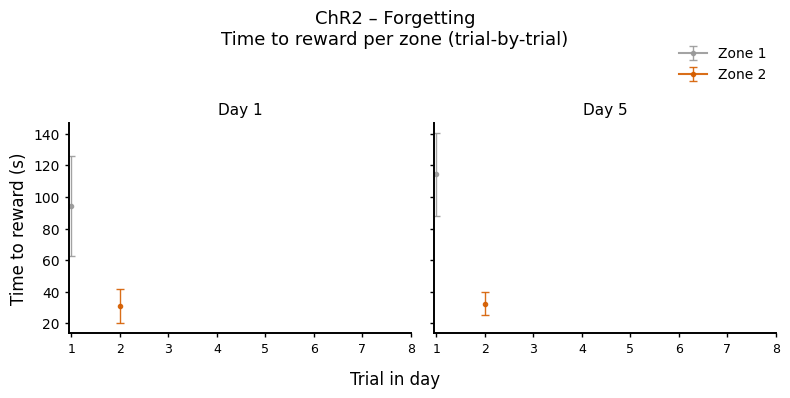

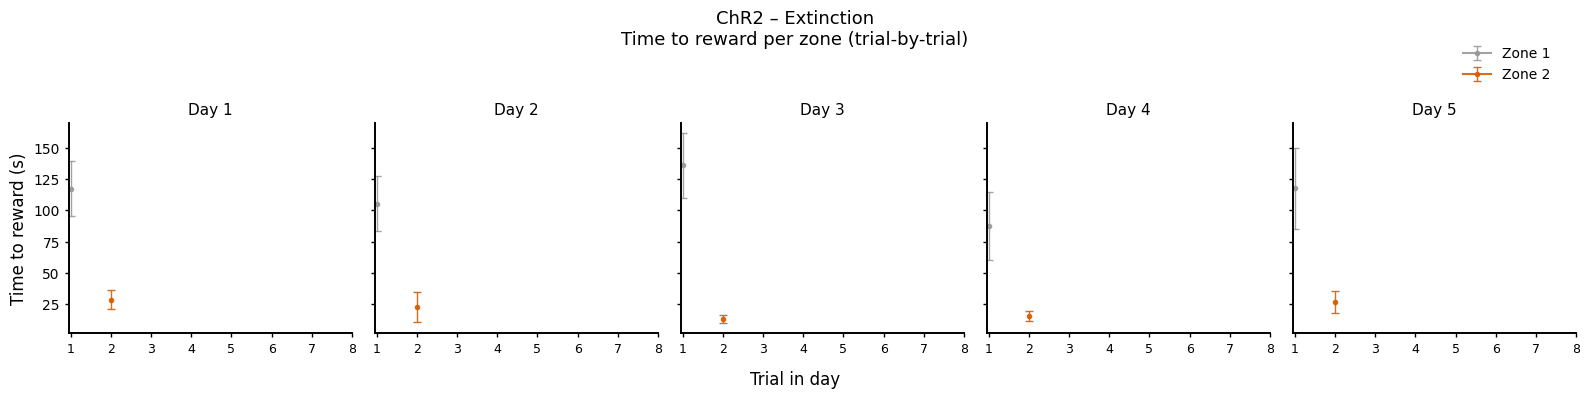

In [ ]:
# revise later - tried to plot for trial to trial progress

# ------------------------------------------------------------
# Base filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

max_day    = 5
day_values = np.arange(1, max_day + 1)
trial_vals = np.arange(1, 9)  # trials 1–8

# ------------------------------------------------------------
# Ensure trial_in_day exists (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta.columns), None)

if trial_col is not None:
    meta['trial_in_day'] = meta[trial_col].astype(int)
else:
    meta = meta.sort_values(['sub', 'ses']).copy()
    meta['trial_in_day'] = meta.groupby(['sub', 'ses']).cumcount() + 1

meta = meta[meta['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# Build mean ± SEM per (day, trial) for each trigger
# ------------------------------------------------------------
def build_day_trial_stats(meta_df, trigger_id):
    """
    For given meta subset (forgetting / extinction) and trigger_id,
    returns:
        stats[day] = (mean_s, sem_s)  # arrays of length = 8 trials
    where units are seconds.
    """
    stats = {}

    df_trig = meta_df[meta_df['trigger_id'] == trigger_id].copy()
    if df_trig.empty:
        return stats

    for day in day_values:
        df_day = df_trig[df_trig['trial_type_day'] == day]
        if df_day.empty:
            continue

        # 1) Average within each animal × trial_in_day
        #    (in case there are multiple T trials per day)
        per_sub_trial = (
            df_day
            .groupby(['sub', 'trial_in_day'])['t_to_trigger_trig']
            .mean()
            .reset_index()
        )

        if per_sub_trial.empty:
            continue

        # 2) Across animals: mean & SEM for each trial_in_day
        g = per_sub_trial.groupby('trial_in_day')['t_to_trigger_trig']
        mean_series = g.mean()
        std_series  = g.std(ddof=1)
        n_series    = g.count()

        mean_ms = np.full(len(trial_vals), np.nan)
        sem_ms  = np.full(len(trial_vals), np.nan)

        for i, t in enumerate(trial_vals):
            if t in mean_series.index:
                mean_ms[i] = mean_series.loc[t]
                n = n_series.loc[t]
                if (n > 1) and not np.isnan(std_series.loc[t]):
                    sem_ms[i] = std_series.loc[t] / np.sqrt(n)

        # store in seconds
        stats[day] = (mean_ms / 1000.0, sem_ms / 1000.0)

    return stats

# ------------------------------------------------------------
# Split forgetting vs extinction and compute stats per zone
# ------------------------------------------------------------
meta_f = meta[meta['test_type'] == 'forgetting'].copy()
meta_e = meta[meta['test_type'] == 'extinction'].copy()

stats_f_z1 = build_day_trial_stats(meta_f, trigger_id=1)
stats_f_z2 = build_day_trial_stats(meta_f, trigger_id=2)

stats_e_z1 = build_day_trial_stats(meta_e, trigger_id=1)
stats_e_z2 = build_day_trial_stats(meta_e, trigger_id=2)

colors = {
    1: '#999999',  # Zone 1 (grey)
    2: '#D55E00',  # Zone 2 (orange)
}

# ============================================================
# FIGURE 1 – FORGETTING: ONLY DAY 1 AND DAY 5
# ============================================================
forget_days = [1, 5]
fig_f, axes_f = plt.subplots(1, len(forget_days), figsize=(8, 3.5), sharey=True)

if len(forget_days) == 1:
    axes_f = [axes_f]

for ax, day in zip(axes_f, forget_days):
    # Zone 1
    if day in stats_f_z1:
        mean_s, sem_s = stats_f_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_f_z2:
        mean_s, sem_s = stats_f_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    # NN-style axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_f[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_f.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_f[0].get_legend_handles_labels()
if handles:
    fig_f.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_f.suptitle('ChR2 – Forgetting\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

# ============================================================
# FIGURE 2 – EXTINCTION: DAYS 1–5
# ============================================================
ext_days = day_values
fig_e, axes_e = plt.subplots(1, len(ext_days), figsize=(16, 3.5), sharey=True)

if len(ext_days) == 1:
    axes_e = [axes_e]

for ax, day in zip(axes_e, ext_days):
    # Zone 1
    if day in stats_e_z1:
        mean_s, sem_s = stats_e_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_e_z2:
        mean_s, sem_s = stats_e_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_e[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_e.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_e[0].get_legend_handles_labels()
if handles:
    fig_e.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_e.suptitle('ChR2 – Extinction\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

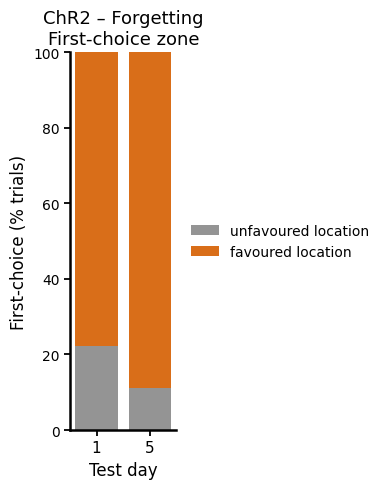

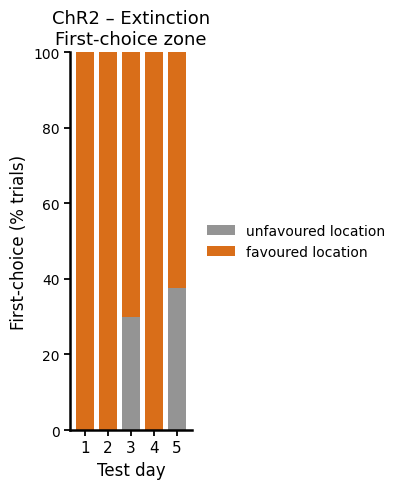

In [ ]:

# ============================================================
# Fade setting (0=transparent, 1=opaque)
# ============================================================
alpha = 0.9   # <-- adjust here

# ============================================================
# Base filter for first-choice analysis
# ============================================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

colors = {
    1: '#888888',   # zone 1 (unfavoured)
    2: '#D55E00',   # zone 2 (favoured)
}
labels = {
    1: 'unfavoured location',
    2: 'favoured location',
}

# ------------------------------------------------------------
# Helper: compute first-choice proportions
# ------------------------------------------------------------
def first_choice_props(mt_sub, day_vals):
    mt_sub = mt_sub[mt_sub['trial_type_day'].isin(day_vals)].copy()

    idx_first = mt_sub.groupby('trial_id')['t_to_trigger_trig'].idxmin()
    tmp = mt_sub.loc[idx_first].copy()

    total_trials = (
        tmp.groupby('trial_type_day').size()
           .reindex(day_vals, fill_value=0)
    )

    counts = (
        tmp.groupby(['trial_type_day','trigger_id']).size()
            .unstack('trigger_id')
            .reindex(index=day_vals, fill_value=0)
    )

    for zid in [1,2]:
        if zid not in counts.columns:
            counts[zid] = 0

    counts = counts[[1,2]]

    props = counts.div(total_trials.replace(0,np.nan),axis=0).fillna(0)*100

    return props, total_trials, counts


# ------------------------------------------------------------
# FIGURE 1 — FORGETTING: Days 1 & 5
# ------------------------------------------------------------
days_forget = [1,5]
mt_forget = mt[mt['test_type']=='forgetting']

props_f, total_f, counts_f = first_choice_props(mt_forget, days_forget)

plt.figure(figsize=(5,5))
x = np.arange(len(days_forget))
bottom = np.zeros(len(days_forget))

for zid in [1,2]:
    vals = props_f[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_forget],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Forgetting\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()


# ------------------------------------------------------------
# FIGURE 2 — EXTINCTION: Days 1–5
# ------------------------------------------------------------
days_ext = [1,2,3,4,5]
mt_ext = mt[mt['test_type']=='extinction']

props_e, total_e, counts_e = first_choice_props(mt_ext, days_ext)

plt.figure(figsize=(5.2,5))
x = np.arange(len(days_ext))
bottom = np.zeros(len(days_ext))

for zid in [1,2]:
    vals = props_e[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_ext],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Extinction\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()

First-choice analysis summary (RL/T)

Total trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 56 trials
  Day 5: 56 trials
  Day 6: 7 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1=2, Zone2=5, Zone3=49
  Day 2:  Zone1=5, Zone2=14, Zone3=37
  Day 3:  Zone1=11, Zone2=19, Zone3=26
  Day 4:  Zone1=12, Zone2=21, Zone3=23
  Day 5:  Zone1=11, Zone2=34, Zone3=11
  Day 6:  Zone1=1, Zone2=4, Zone3=2

Proportions (% of trials):
  Day 1:  Zone1=3.6%, Zone2=8.9%, Zone3=87.5%
  Day 2:  Zone1=8.9%, Zone2=25.0%, Zone3=66.1%
  Day 3:  Zone1=19.6%, Zone2=33.9%, Zone3=46.4%
  Day 4:  Zone1=21.4%, Zone2=37.5%, Zone3=41.1%
  Day 5:  Zone1=19.6%, Zone2=60.7%, Zone3=19.6%
  Day 6:  Zone1=14.3%, Zone2=57.1%, Zone3=28.6%



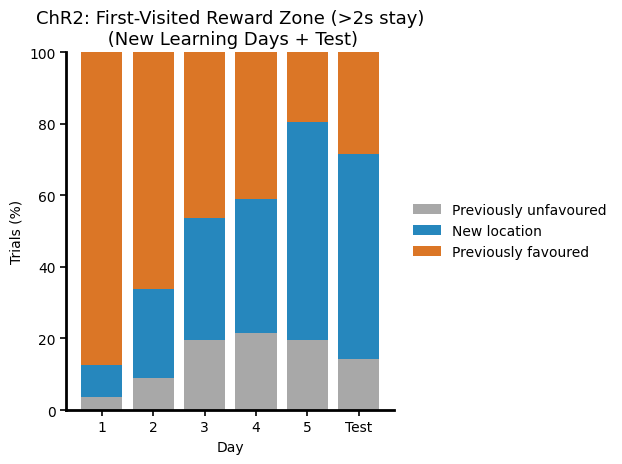

In [386]:

# ------------------------------------------------------------
# Filter: ChR2, RL/T, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5, T = 6
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign T=6 after last RL per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]

# ------------------------------------------------------------
# First-choice counting
# ------------------------------------------------------------
mt_use = mt.copy()

# Determine first trigger per trial
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# Count per day × trigger
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2, 3], fill_value=0)
)

# Total trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)

print("====================================")
print("First-choice analysis summary (RL/T)")
print("====================================")

print("\nTotal trials per day:")
for d in plot_days:
    print(f"  Day {d}: {total_trials.loc[d]} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(f"  Day {d}:  Zone1={row.get(1,0)}, Zone2={row.get(2,0)}, Zone3={row.get(3,0)}")

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(f"  Day {d}:  Zone1={row[1]*100:.1f}%, Zone2={row[2]*100:.1f}%, Zone3={row[3]*100:.1f}%")
print("====================================\n")

# ------------------------------------------------------------
# Plot stacked bars
# ------------------------------------------------------------
colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}
labels = {
    1: 'Previously unfavoured',
    2: 'New location',
    3: 'Previously favoured',
}

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2, 3]:
    vals = proportions[trig_id].values * 100
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.85, 
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(['1','2','3','4','5','Test'])
ax.set_xlabel('Day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title('ChR2: First-Visited Reward Zone (>2s stay)\n (New Learning Days + Test)', fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,0.95])
plt.show()

#  new learning


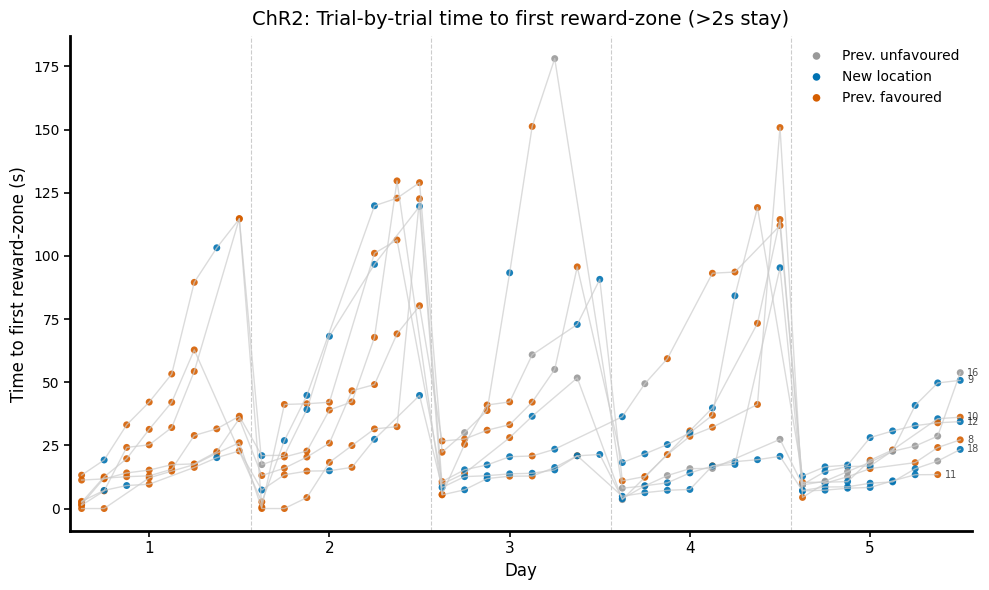

In [ ]:


# ------------------------------------------------------------
# 1) Filter: ChR2, RL/T, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5 from trial_type_day; T = 6 (first T after RL)
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL days 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign test day (6) as first T session after last RL session, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses)
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
# We assume 'trial_id' uniquely identifies a trial; if not, you can use
# ['sub','ses','trial_in_day'] as an alternative key.
group_key = 'trial_id'
if group_key not in mt.columns:
    # Fallback key if trial_id is not present
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..48)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']

# ---- Remove test day (plot_day = 6) ----
mt_noT = first_choice[first_choice['plot_day'] <= 5].copy()

# ---- Recompute global trial index for only RL days ----
mt_noT['trial_idx_global'] = (mt_noT['plot_day'] - 1) * 8 + mt_noT['trial_in_day']

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}

zone_labels = {
    1: 'Prev. unfavoured',
    2: 'New location',
    3: 'Prev. favoured',
}

# plot each animal as before
for sub in sorted(mt_noT['sub'].unique()):
    ms = mt_noT[mt_noT['sub'] == sub].sort_values(['plot_day','trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0

    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    for zid in [1,2,3]:
        ms_z = ms[ms['trigger_id']==zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values)/1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 RL days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators
for d in range(1, max_day):
    ax.axvline(d*trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x tick labels at center of each day block
day_centers = [(d-0.5)*trials_per_day for d in range(1, max_day+1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day+1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Time to first reward-zone (s)', fontsize=12)

# legend
handles = []
labels = []
for zid in [1,2,3]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title('ChR2: Trial-by-trial time to first reward-zone (>2s stay)', fontsize=14, pad=8)

plt.tight_layout()
plt.show()



############################################################
RUNNING: t_to_trigger_trig
Computed using: all visits
Using separate per-trigger values from meta_trig
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   21       1.0             1   
1      8  AD     ChR2         RL               1   21       1.0             1   
2      8  AD     ChR2         RL               1   21       1.0             1   
3      8  AD     ChR2         RL               1   21       1.0             2   
4      8  AD     ChR2         RL               1   21       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
976   18  AO     ChR2         RL               5   47       5.0             8   
977   18  AO     ChR2         RL               5   47       5.0             8   
978   18  AO     ChR

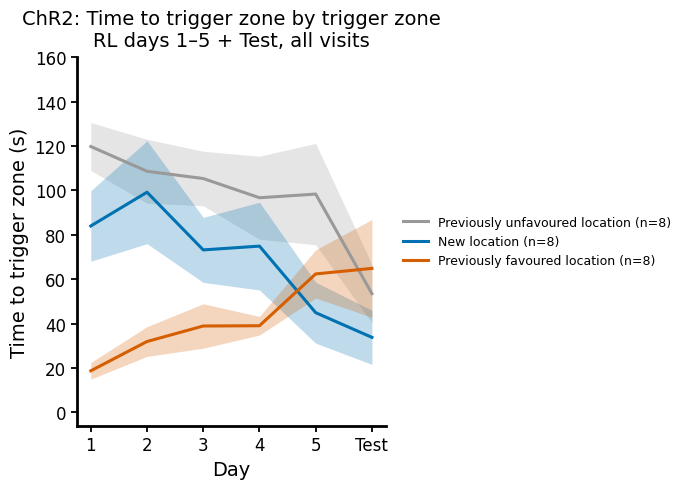


Boxplot: Time to trigger zone, plot_day 1
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[108.0132 157.6125 156.3958  67.3479 106.0555 105.4862 115.8606 141.0875]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[145.2015  91.7752 122.5876  68.3985  43.4966  54.6171 126.841   18.5779]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[13.588  11.7128 27.9389 11.1028  9.0732 33.3934 10.4366 32.4032]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=119.732 vs 83.937, median=111.937 vs 80.087, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=119.732 vs 18.706, median=111.937 vs 12.650, W=0.000, p=0.00781
  New location vs Previously favoured locat

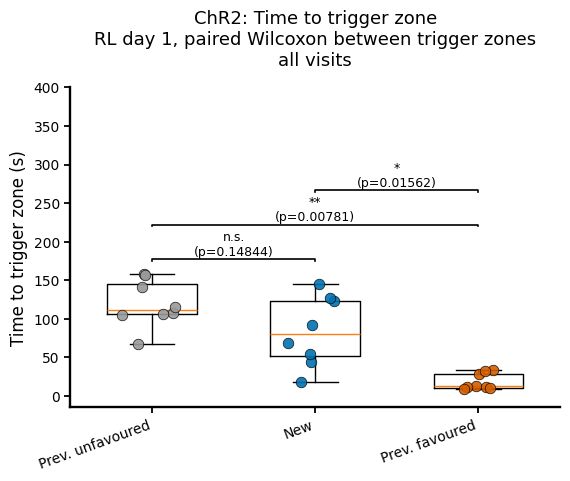


Boxplot: Time to trigger zone, plot_day 2
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[146.7569 127.2002 143.2956  41.6434  58.8822  90.8826 144.5533 115.4439]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[184.2714 178.1286 104.4974  63.2788  28.6889  73.0627 147.4769  13.7935]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[23.937  10.2888 65.6618 56.7592 23.6435 21.6504 25.7436 27.5489]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=108.582 vs 99.150, median=121.322 vs 88.780, W=16.000, p=0.84375
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=108.582 vs 31.904, median=121.322 vs 24.840, W=1.000, p=0.01562
  New location vs Previously favoured loca

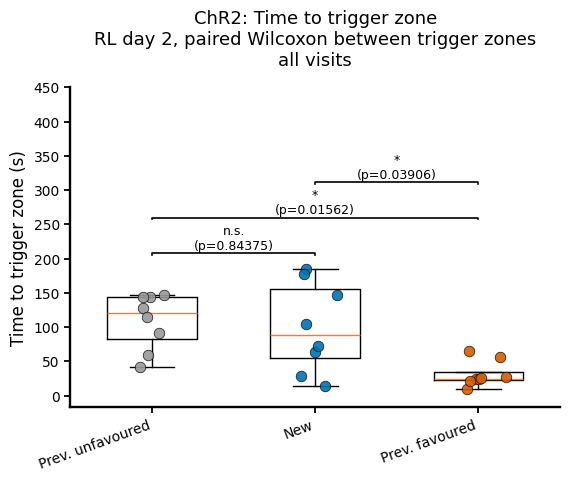


Boxplot: Time to trigger zone, plot_day 3
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[142.5492  93.4181 121.03    67.4798  61.3256  77.7138 149.2714 129.7439]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[115.7385 121.4342  66.5164  28.7149  56.3521  85.8911 104.2296   6.4506]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[69.9179 19.772  56.1692 15.4572 20.3611 21.4408 19.984  88.0249]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=105.316 vs 73.166, median=107.224 vs 76.204, W=6.000, p=0.10938
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=105.316 vs 38.891, median=107.224 vs 20.901, W=0.000, p=0.00781
  New location vs Previously favoured locat

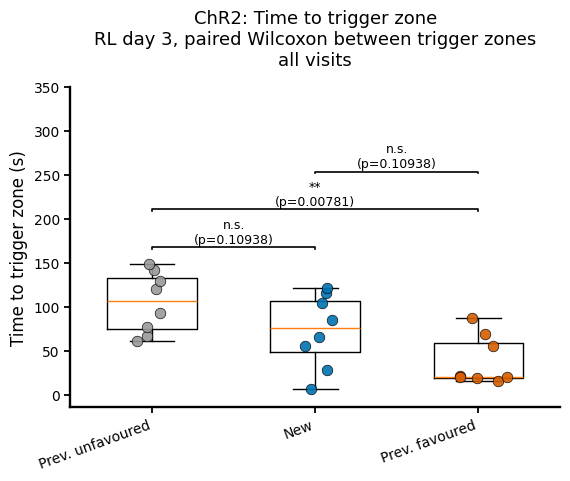


Boxplot: Time to trigger zone, plot_day 4
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[124.8822 114.8948 151.9231  56.8581  22.2976  30.5374 156.0381 115.8588]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[158.4444 103.0994  99.0286  11.1773  23.1943 127.2141  64.6639  12.1444]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[47.8639 49.9754 54.2626 45.249  23.5252 30.23   25.1395 35.8221]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=96.661 vs 74.871, median=115.377 vs 81.846, W=11.000, p=0.38281
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=96.661 vs 39.008, median=115.377 vs 40.536, W=2.000, p=0.02344
  New location vs Previously favoured locati

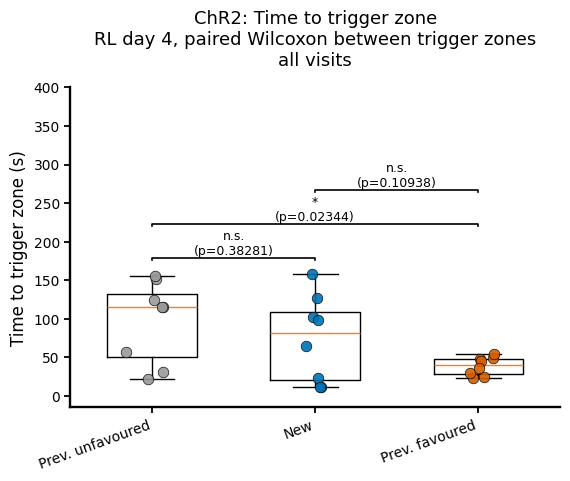


Boxplot: Time to trigger zone, plot_day 5
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[136.1896  85.0441 177.9465  48.3216  26.7928  15.0002 177.1886 120.0072]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 72.5421  27.7161  78.9785   8.9501  21.3952 114.165   28.5066   6.9004]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[28.5626 69.3368 96.2706 37.2913 24.003  54.0451 98.3428 90.9314]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=98.311 vs 44.894, median=102.526 vs 28.111, W=6.000, p=0.10938
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=98.311 vs 62.348, median=102.526 vs 61.691, W=5.000, p=0.07812
  New location vs Previously favoured locatio

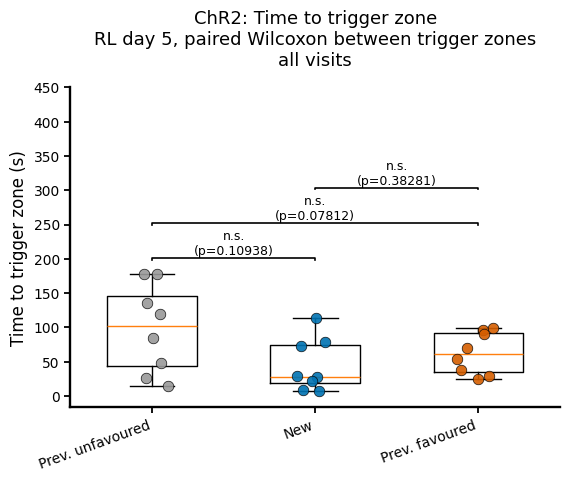


Boxplot: Time to trigger zone, plot_day 6
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[109.994  29.085  59.937  63.878  92.797   1.121  16.123  54.819]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[44.419  1.497  0.142  0.821 99.803 53.022 45.127 25.38 ]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[0.00000e+00 4.80000e-02 1.59801e+02 1.02805e+02 1.11704e+02 1.66610e+01
 2.02440e+01 1.07439e+02]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=53.469 vs 33.776, median=57.378 vs 34.900, W=9.000, p=0.25000
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=53.469 vs 64.838, median=57.378 vs 61.525, W=12.000, p=0.46094
  New location vs Previously favoured

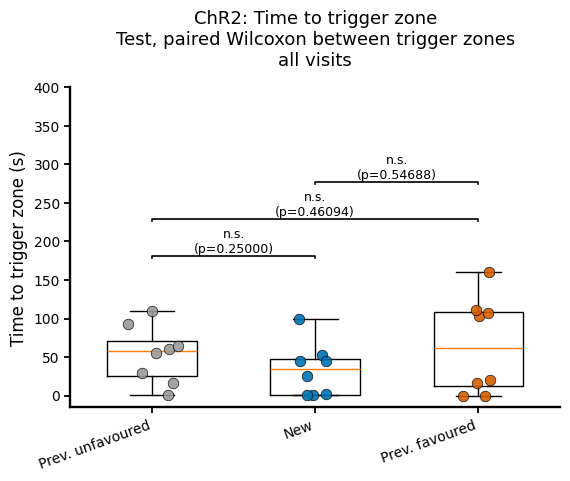


Trial-by-trial plot: Time to trigger zone
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig

Animals included per trigger zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


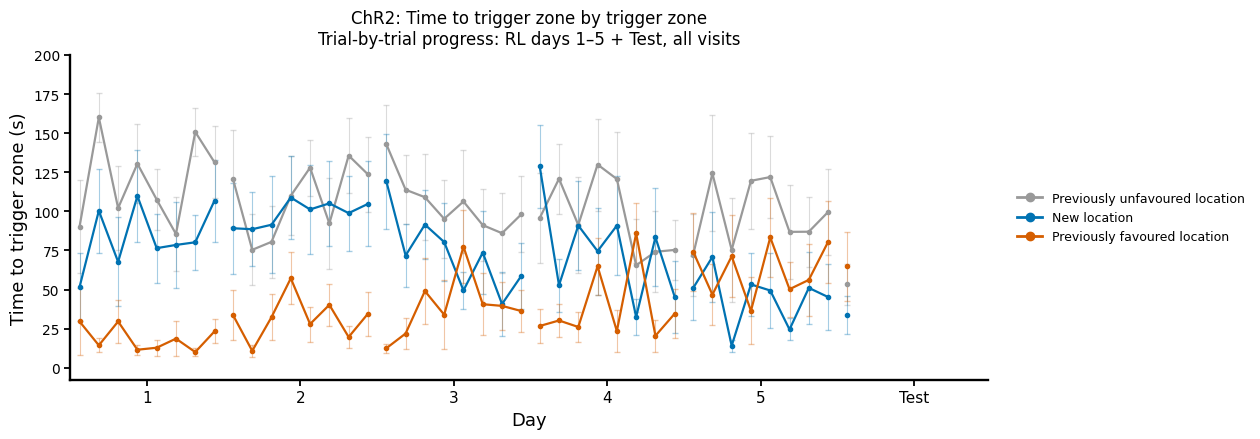


RL day 1 average vs RL day 5 average: Time to trigger zone
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=12.000, p=0.46094, Day1 mean=119.732, Day5 mean=98.311


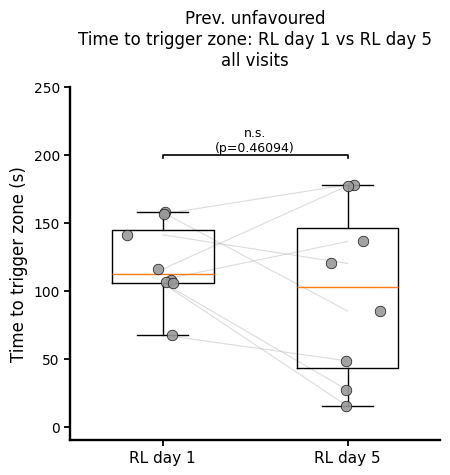


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=5.000, p=0.07812, Day1 mean=83.937, Day5 mean=44.894


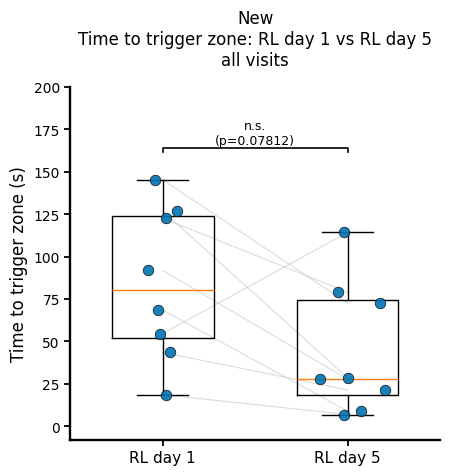


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=0.000, p=0.00781, Day1 mean=18.706, Day5 mean=62.348


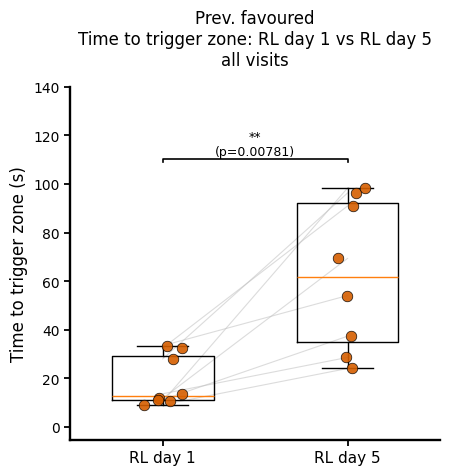


RL day 1 trial 1 vs Test-day average: Time to trigger zone
Using column: t_to_trigger_trig
Computed using: all visits
Plotting separate trigger zones from meta_trig

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=15.000, p=0.74219, Day1 trial1 mean=90.202, Test mean=53.469


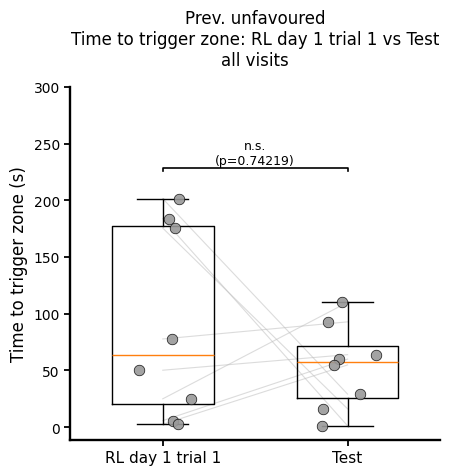


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=15.000, p=0.74219, Day1 trial1 mean=51.605, Test mean=33.776


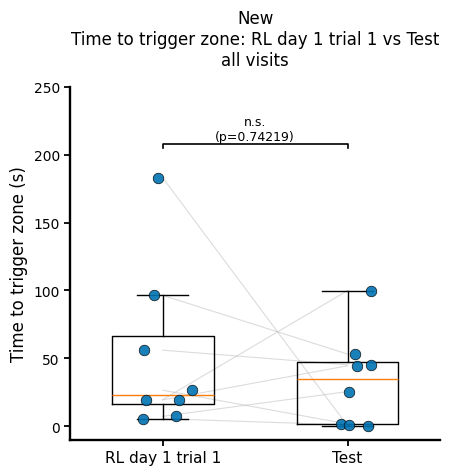


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=11.000, p=0.38281, Day1 trial1 mean=29.568, Test mean=64.838


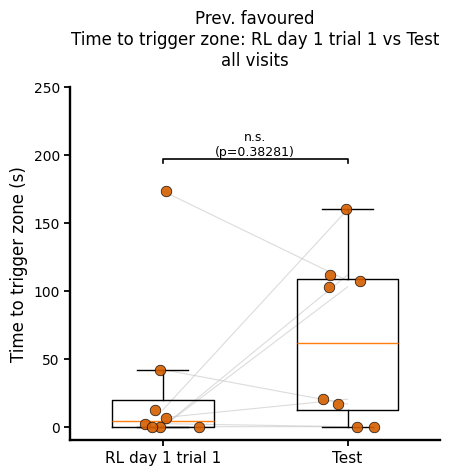



############################################################
RUNNING: t_to_trigger_trig_long
Computed using: ≥2 s stay
Using separate per-trigger values from meta_trig
############################################################

Filtered RL/Test rows:
     sub  id genotype trial_type  trial_type_day  ses  plot_day  trial_in_day  \
0      8  AD     ChR2         RL               1   21       1.0             1   
1      8  AD     ChR2         RL               1   21       1.0             1   
2      8  AD     ChR2         RL               1   21       1.0             1   
3      8  AD     ChR2         RL               1   21       1.0             2   
4      8  AD     ChR2         RL               1   21       1.0             2   
..   ...  ..      ...        ...             ...  ...       ...           ...   
976   18  AO     ChR2         RL               5   47       5.0             8   
977   18  AO     ChR2         RL               5   47       5.0             8   
978   18  AO    

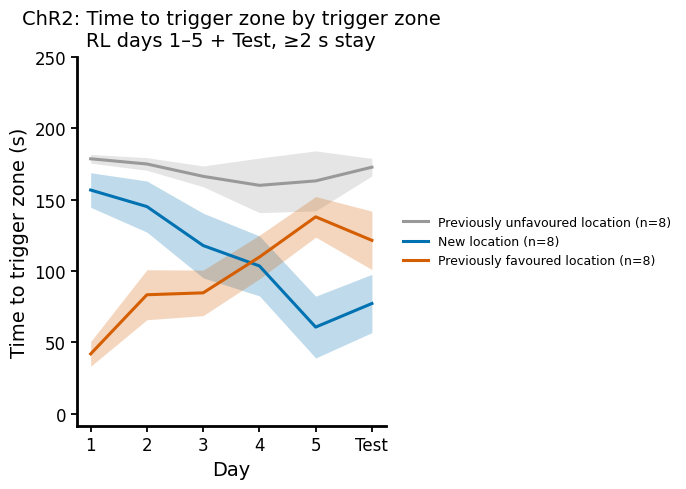


Boxplot: Time to trigger zone, plot_day 1
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[179.7231 169.2255 187.2544 186.5122 187.3711 182.4154 169.218  167.9454]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[155.6394 158.4419 173.6965 157.3979 187.3711 162.7214 181.9636  77.1299]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[84.0391 27.3774 48.5288 28.6055 18.1804 66.8674 14.3945 47.001 ]

Paired Wilcoxon tests, plot_day 1:
  Previously unfavoured location vs New location: paired n=8, mean=178.708 vs 156.795, median=181.069 vs 160.582, W=2.000, p=0.04252
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=178.708 vs 41.874, median=181.069 vs 37.803, W=0.000, p=0.00781
  New location vs Previously favoured

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


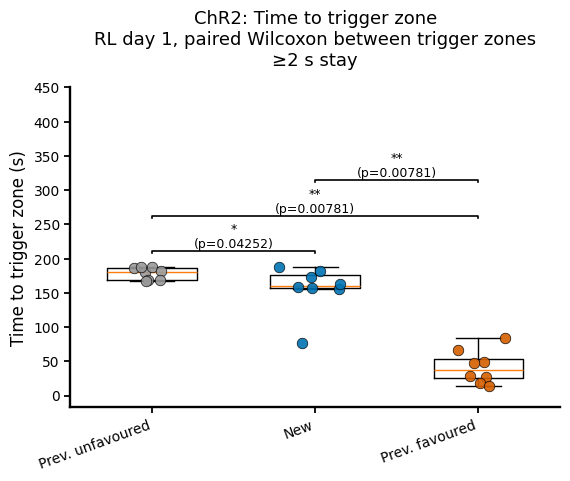


Boxplot: Time to trigger zone, plot_day 2
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[162.3481 187.4469 163.3576 158.2678 191.8892 177.2062 184.1637 175.7925]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[184.2714 178.1286 172.3083  99.6484 191.8892 126.9009 162.015   46.3575]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 85.9728  28.718   72.7476 156.4541  40.0555 146.4559  33.3233 103.1808]

Paired Wilcoxon tests, plot_day 2:
  Previously unfavoured location vs New location: paired n=8, mean=175.059 vs 145.190, median=176.499 vs 167.162, W=4.000, p=0.09097
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=175.059 vs 83.363, median=176.499 vs 79.360, W=0.000, p=0.00781
  New location vs Previously 

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


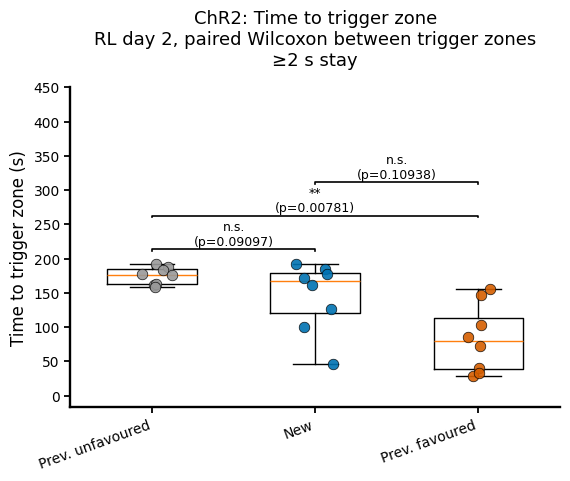


Boxplot: Time to trigger zone, plot_day 3
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[150.9086 127.1451 184.3869 190.8492 166.9492 161.7289 167.1784 181.948 ]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[156.8346 146.7095  66.5164  55.1841 183.9609 169.9846 153.3541  10.3624]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 86.9842  74.2511  57.9356  61.4036  69.061  139.8555  25.2911 162.8264]

Paired Wilcoxon tests, plot_day 3:
  Previously unfavoured location vs New location: paired n=8, mean=166.387 vs 117.863, median=167.064 vs 150.032, W=12.000, p=0.46094
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=166.387 vs 84.701, median=167.064 vs 71.656, W=0.000, p=0.00781
  New location vs Previously

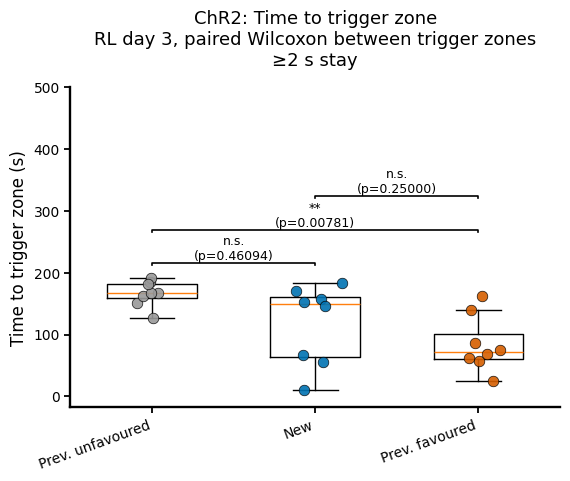


Boxplot: Time to trigger zone, plot_day 4
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[190.6606 140.8855 170.7786 194.1572 186.0088  32.7284 182.345  183.1346]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[171.6361 171.8675 130.0361  13.3329  90.482  141.8699  64.6639  44.729 ]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 60.765  102.5966 118.8991 132.6074 153.7179 100.6129  41.3454 167.8216]

Paired Wilcoxon tests, plot_day 4:
  Previously unfavoured location vs New location: paired n=8, mean=160.087 vs 103.577, median=182.740 vs 110.259, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=160.087 vs 109.796, median=182.740 vs 110.748, W=6.000, p=0.10938
  New location vs Previousl

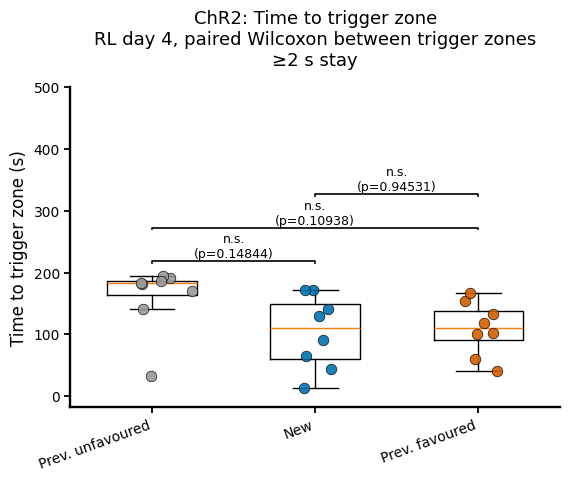


Boxplot: Time to trigger zone, plot_day 5
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[158.5254 201.4948 181.6681 190.3728 183.1778  20.6148 201.1548 168.5755]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 82.3332  27.7161  79.3606  12.1965  44.042  196.9333  28.5066  14.3298]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 72.3161 147.9962 100.7555 168.8498 161.6576 180.9928 102.7219 168.6336]

Paired Wilcoxon tests, plot_day 5:
  Previously unfavoured location vs New location: paired n=8, mean=163.198 vs 60.677, median=182.423 vs 36.274, W=7.000, p=0.14844
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=163.198 vs 137.990, median=182.423 vs 154.827, W=9.000, p=0.25000
  New location vs Previously 

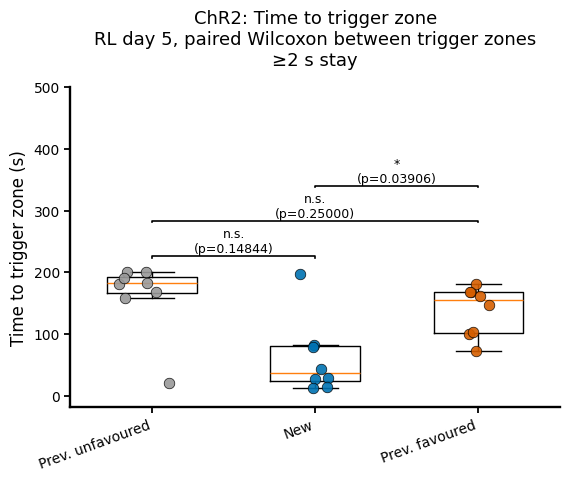


Boxplot: Time to trigger zone, plot_day 6
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig
  Previously unfavoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[187.33  185.334 181.712 146.407 174.603 144.323 182.66  180.266]
  New location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[ 44.419  42.556 110.734  23.233 124.813 188.251  45.127  38.767]
  Previously favoured location: n=8, ids=['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO'], values=[  0.    110.482 159.801 102.805 111.704 178.119 128.818 180.266]

Paired Wilcoxon tests, plot_day 6:
  Previously unfavoured location vs New location: paired n=8, mean=172.829 vs 77.238, median=180.989 vs 44.773, W=1.000, p=0.01562
  Previously unfavoured location vs Previously favoured location: paired n=8, mean=172.829 vs 121.499, median=180.989 vs 120.261, W=2.000, p=0.04252
  New location vs Previously favoured location: paire

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


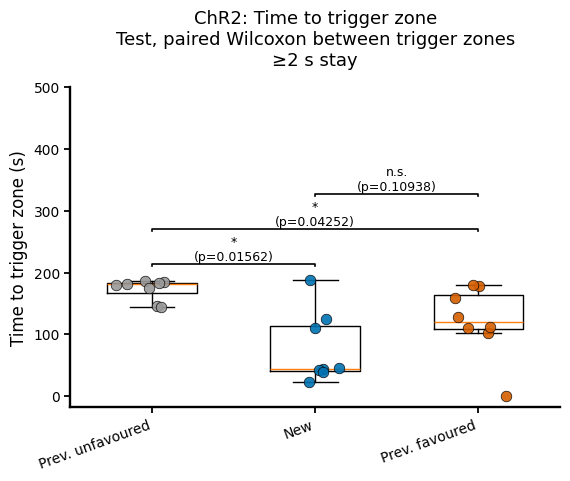


Trial-by-trial plot: Time to trigger zone
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig

Animals included per trigger zone, trial-by-trial:
  Previously unfavoured location: 8 animals
  New location: 8 animals
  Previously favoured location: 8 animals
Total unique animals included, any zone: 8
Animal subs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(17), np.int64(18)]
Animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']


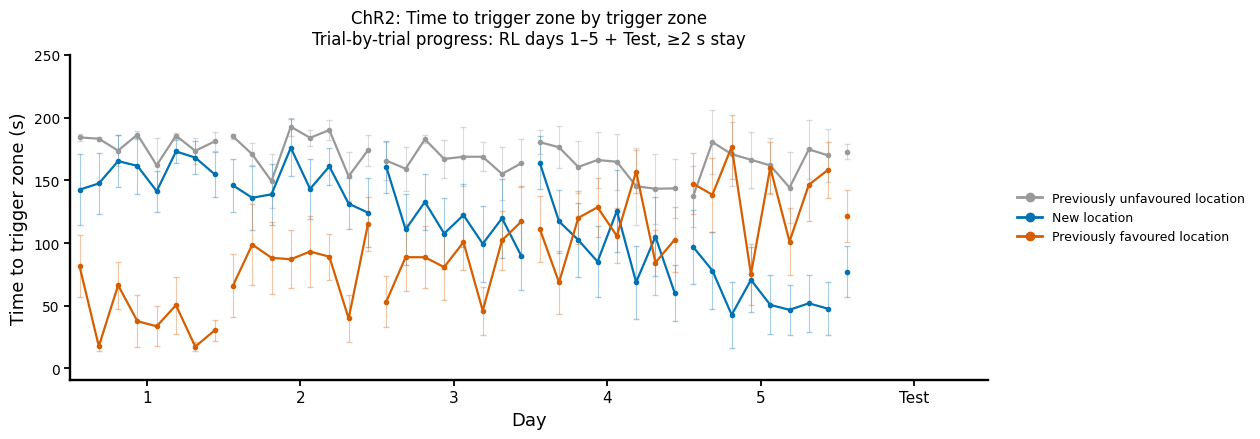


RL day 1 average vs RL day 5 average: Time to trigger zone
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=16.000, p=0.84375, Day1 mean=178.708, Day5 mean=163.198


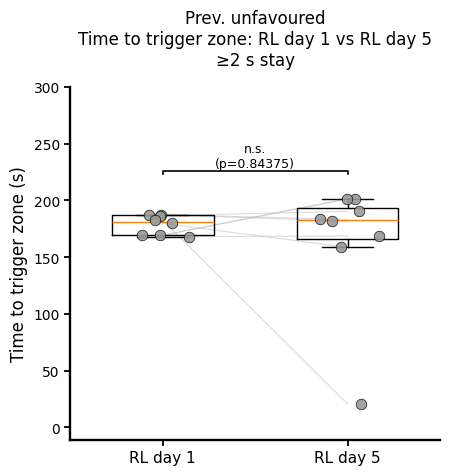


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 mean=156.795, Day5 mean=60.677


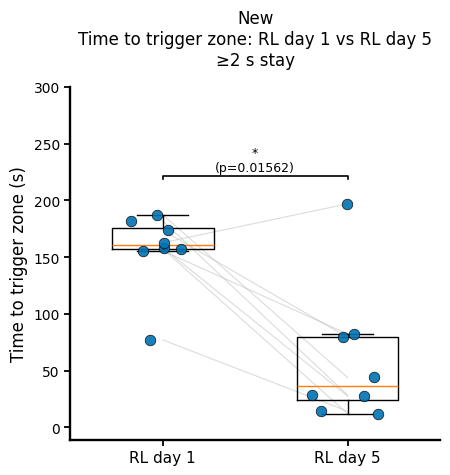


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=1.000, p=0.01562, Day1 mean=41.874, Day5 mean=137.990


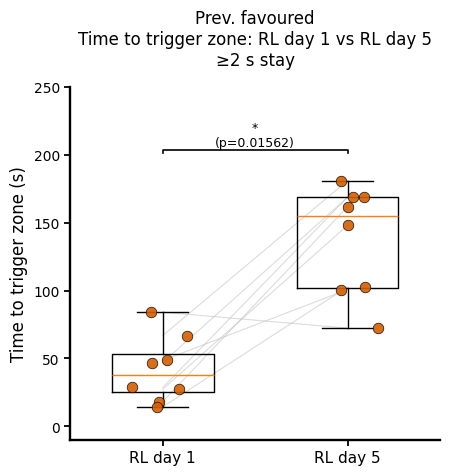


RL day 1 trial 1 vs Test-day average: Time to trigger zone
Using column: t_to_trigger_trig_long
Computed using: ≥2 s stay
Plotting separate trigger zones from meta_trig

Previously unfavoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=9.000, p=0.25000, Day1 trial1 mean=184.195, Test mean=172.829


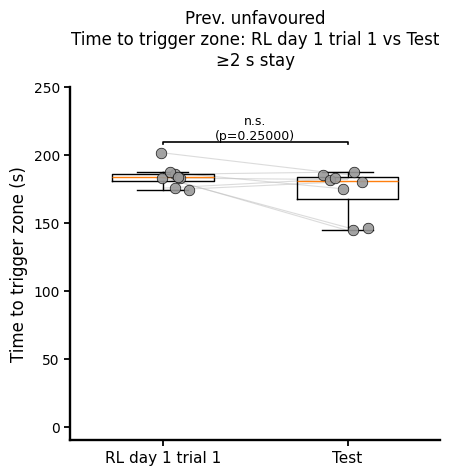


New location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=6.000, p=0.10938, Day1 trial1 mean=142.559, Test mean=77.238


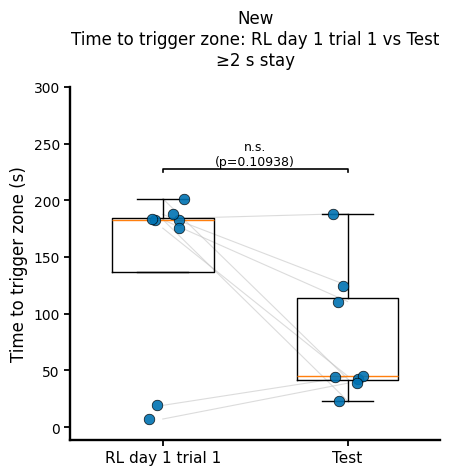


Previously favoured location
  Paired n = 8
  IDs = ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AN', 'AO']
  Wilcoxon: W=8.000, p=0.19531, Day1 trial1 mean=81.514, Test mean=121.499


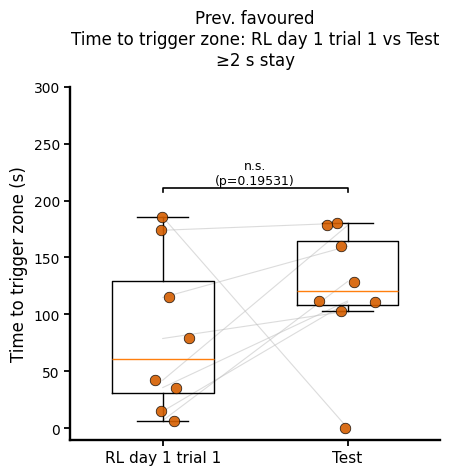

In [342]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

# ============================================================
# RL days 1–5 + first post-RL Test day 6
#
# Uses NEW per-trigger time-to-trigger dataframe:
#
#   meta_trig
#
# with one row per trial × trigger:
#   trigger_id
#   t_to_trigger_trig
#   t_to_trigger_trig_long
#   reached_trigger_trig
#   reached_trigger_trig_long
#
# Produces, for BOTH:
#   1) t_to_trigger_trig       = all visits
#   2) t_to_trigger_trig_long  = ≥2 s stay
#
# Plots:
#   1) Wide line plot across RL1–RL5 + Test
#   2) Boxplots for selected days, comparing zones 1/2/3
#      - paired Wilcoxon tests only
#      - no Friedman test
#      - no multiple-comparison correction
#   3) Trial-by-trial within-day progress plot
#   4) For each zone: RL day 1 average vs RL day 5 average
#   5) For each zone: RL day 1 trial 1 vs Test-day average
#
# IMPORTANT:
#   short_duration is NOT filtered anywhere in this code.
# ============================================================


# ============================================================
# OPTIONS
# ============================================================

GENOTYPE_TO_PLOT = 'ChR2'

# New per-trigger columns from meta_trig
METRICS_TO_PLOT = [
    't_to_trigger_trig',
    't_to_trigger_trig_long',
]

METRIC_LABELS = {
    't_to_trigger_trig': 'Time to trigger zone (s)',
    't_to_trigger_trig_long': 'Time to trigger zone (s)',
}

METRIC_TITLES = {
    't_to_trigger_trig': 'Time to trigger zone',
    't_to_trigger_trig_long': 'Time to trigger zone',
}

METRIC_STAY_TAG = {
    't_to_trigger_trig': 'all visits',
    't_to_trigger_trig_long': '≥2 s stay',
}

# ------------------------------------------------------------
# Time scaling
# ------------------------------------------------------------
# Your t values are usually in ms from position['t'].
# If your t is in ms, use 1/1000 to plot seconds.
# If your t is already in seconds, change this to 1.0.
METRIC_SCALE = {
    't_to_trigger_trig': 1 / 1000.0,
    't_to_trigger_trig_long': 1 / 1000.0,
}

# Trigger zones
ZONE_IDS = [1, 2, 3]

ZONE_LABELS = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

ZONE_SHORT_LABELS = {
    1: 'Prev. unfavoured',
    2: 'New',
    3: 'Prev. favoured',
}

ZONE_COLORS = {
    1: '#999999',  # grey
    2: '#0072B2',  # blue
    3: '#D55E00',  # orange
}

EXCLUDE_ID = []
EXCLUDE_SUBS = []

# If True, line-plot matrices require all 6 days.
REQUIRE_COMPLETE_LINE = False

# Line plot SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
LINE_SEM_STYLE = 'shaded'
# LINE_SEM_STYLE = 'bar'
# LINE_SEM_STYLE = 'none'

# Trial-by-trial SEM style:
#   'shaded' -> shaded SEM band
#   'bar'    -> SEM error bars
#   'none'   -> mean line only
TRIAL_SEM_STYLE = 'bar'
# TRIAL_SEM_STYLE = 'shaded'
# TRIAL_SEM_STYLE = 'none'

RUN_LINE_PLOTS = True
RUN_DAY_BOXPLOTS = True
RUN_TRIAL_BY_TRIAL_PLOTS = True
RUN_DAY1_VS_DAY5_BOXPLOTS = True
RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS = True

# Boxplots comparing zones on each selected day:
#   1 = RL day 1
#   2 = RL day 2
#   ...
#   6 = Test
BOXPLOT_DAYS = [1, 2, 3, 4, 5, 6]

# Pairwise paired Wilcoxon comparisons between zones
ZONE_COMPARISONS = [
    (1, 2),
    (1, 3),
    (2, 3),
]

SHOW_ANIMAL_IDS = False
SHOW_PAIRED_LINES_IN_BOXPLOT = False

# For within-zone paired plots
SHOW_PAIRED_LINES_DAY1_DAY5 = True
SHOW_PAIRED_LINES_TRIAL1_TEST = True

# Plot-day labels
plot_days = np.arange(1, 7)
plot_day_labels = ['1', '2', '3', '4', '5', 'Test']

# Trial-by-trial
trials = np.arange(1, 9)

# Figure sizes
LINE_FIGSIZE = (8.8, 5.0)
TRIAL_FIGSIZE = (15, 4.5)
BOX_FIGSIZE = (5.8, 5.4)
PAIR_BOX_FIGSIZE = (4.6, 5.4)

# ------------------------------------------------------------
# Y-axis padding
# ------------------------------------------------------------
LINE_Y_ZERO_PAD_FRAC = 0.04
LINE_Y_TOP_PAD_FRAC = 0.18

TRIAL_Y_ZERO_PAD_FRAC = 0.04
TRIAL_Y_TOP_PAD_FRAC = 0.12

BOX_Y_ZERO_PAD_FRAC = 0.04
BOX_Y_TOP_PAD_FRAC = 0.12

# Extra p-value/stat bar space for boxplots
BOX_STAT_EXTRA_TOP_FRAC = 0.10

# Optional manual y-axis limits.
# Use None for auto.
YMAX_BY_METRIC = {
    't_to_trigger_trig': None,
    't_to_trigger_trig_long': None,
}

YMIN_BY_METRIC = {
    't_to_trigger_trig': None,
    't_to_trigger_trig_long': None,
}

Y_TICK_STEP_BY_METRIC = {
    't_to_trigger_trig': None,
    't_to_trigger_trig_long': None,
}

# Boxplot p-value spacing
JITTER = 0.08
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.5

P_DECIMALS = 5
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.30
P_TEXT_OFFSET_FRAC = 0.02

np.random.seed(1)


# ============================================================
# Check meta_trig exists
# ============================================================

if 'meta_trig' not in globals():
    raise NameError(
        "meta_trig is not defined. "
        "Run the updated per-trigger time-to-trigger computing code first."
    )


# ============================================================
# Helper functions
# ============================================================

def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def style_nature(ax, linewidth=1.8):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.grid(False)


def scale_value(vals, value_col):
    return np.asarray(vals, dtype=float) * METRIC_SCALE.get(value_col, 1.0)


def mean_sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan

    if len(vals) == 1:
        return float(vals[0]), 0.0

    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))


def mean_sem_by_col(mat):
    if mat is None or mat.size == 0:
        return None, None

    mean_ = np.full(mat.shape[1], np.nan)
    sem_ = np.full(mat.shape[1], np.nan)

    for j in range(mat.shape[1]):
        m, s = mean_sem(mat[:, j])
        mean_[j] = m
        sem_[j] = s

    return mean_, sem_


def wilcoxon_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    ok = np.isfinite(a) & np.isfinite(b)
    a = a[ok]
    b = b[ok]

    if len(a) == 0:
        return np.nan, np.nan

    if np.allclose(a, b, equal_nan=False):
        return np.nan, 1.0

    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, 1.0

    return stat, p


def apply_y_axis(
    ax,
    all_vals,
    value_col,
    context='line',
    extra_top_y=None
):
    """
    Sets y-axis with:
      - optional manual YMIN/YMAX by metric
      - automatic range from values actually plotted
      - separate padding for line/trial/box plots
      - 0 padded below x-axis unless manual ymin is set

    context:
      'line'  -> line plot
      'trial' -> trial-by-trial plot
      'box'   -> boxplot
    """

    all_vals = np.asarray(all_vals, dtype=float)
    all_vals = all_vals[np.isfinite(all_vals)]

    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)
    tick_step = Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if context == 'line':
        zero_pad = LINE_Y_ZERO_PAD_FRAC
        top_pad = LINE_Y_TOP_PAD_FRAC
    elif context == 'trial':
        zero_pad = TRIAL_Y_ZERO_PAD_FRAC
        top_pad = TRIAL_Y_TOP_PAD_FRAC
    elif context == 'box':
        zero_pad = BOX_Y_ZERO_PAD_FRAC
        top_pad = BOX_Y_TOP_PAD_FRAC
    else:
        raise ValueError("context must be 'line', 'trial', or 'box'")

    if len(all_vals) == 0:
        data_top = 1.0
    else:
        data_top = np.nanmax(all_vals)
        if not np.isfinite(data_top) or data_top <= 0:
            data_top = 1.0

    if extra_top_y is not None and np.isfinite(extra_top_y):
        data_top = max(data_top, extra_top_y)

    if manual_ymax is not None:
        y_top = float(manual_ymax)
    else:
        y_top = data_top * (1 + top_pad)

    if manual_ymin is not None:
        if manual_ymin >= 0:
            y_bottom = -zero_pad * y_top
        else:
            y_bottom = float(manual_ymin)
    else:
        y_bottom = -zero_pad * y_top

    ax.set_ylim(y_bottom, y_top)

    if tick_step is not None:
        ax.set_yticks(np.arange(0, y_top + tick_step, tick_step))
    else:
        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]

        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)

        ax.set_yticks(yticks)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + 0.015 * yrng, y + 0.015 * yrng, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})",
        ha='center',
        va='bottom',
        fontsize=9
    )


def get_animal_id(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def normalise_meta_trig_columns(df):
    """
    Makes sure the long-format dataframe has clean column names:
      trigger_id
      trial_id

    This protects against merge-created names like trigger_id_x / trigger_id_y.
    """
    df = df.copy()

    if 'trigger_id' not in df.columns:
        if 'trigger_id_x' in df.columns:
            df = df.rename(columns={'trigger_id_x': 'trigger_id'})
        elif 'trigger_id_y' in df.columns:
            df = df.rename(columns={'trigger_id_y': 'trigger_id'})

    if 'trial_id' not in df.columns:
        if 'trial_id_x' in df.columns:
            df = df.rename(columns={'trial_id_x': 'trial_id'})
        elif 'trial_id_y' in df.columns:
            df = df.rename(columns={'trial_id_y': 'trial_id'})

    return df


# ============================================================
# Prepare RL + Test data from meta_trig
# ============================================================

def prepare_rl_test_data(meta_trig_df, value_col):
    """
    Uses the NEW per-trigger long-format dataframe.

    Each row is one trial × trigger.
    Therefore trigger_id is already the actual zone being plotted.
    """

    meta_trig_df = normalise_meta_trig_columns(meta_trig_df)

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        'trial_id',
        'trigger_id',
        value_col,
    ]

    missing_cols = [c for c in needed_cols if c not in meta_trig_df.columns]
    if len(missing_cols) > 0:
        raise KeyError(
            f"Missing columns in meta_trig: {missing_cols}\n"
            f"The selected VALUE_COL is '{value_col}'.\n"
            "Make sure you ran the updated per-trigger time-to-trigger computing code."
        )

    mt = meta_trig_df[
        (meta_trig_df['usable'] == 1) &
        (meta_trig_df['genotype'] == GENOTYPE_TO_PLOT) &
        (meta_trig_df['trial_type'].isin(['RL', 'T'])) &
        (meta_trig_df['trigger_id'].isin(ZONE_IDS)) &
        (meta_trig_df[value_col].notna()) &
        (np.isfinite(meta_trig_df[value_col]))
    ].copy()

    mt['trigger_id'] = mt['trigger_id'].astype(int)

    # Scale time to seconds if needed.
    mt[value_col] = scale_value(mt[value_col].values, value_col)

    # No short_duration filtering anywhere.

    if len(EXCLUDE_ID) > 0 and 'id' in mt.columns:
        mt = mt[
            ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        mt = mt[
            ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    # --------------------------------------------------------
    # Assign plot_day:
    # RL -> trial_type_day 1–5
    # T  -> first T session after last RL = day 6
    # --------------------------------------------------------
    mt['plot_day'] = np.nan

    mask_RL = mt['trial_type'] == 'RL'
    mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

    mt = mt[
        (~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in mt['sub'].unique():
        ms = mt[mt['sub'] == sub].copy()

        RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']

        if len(RL_ses) == 0:
            continue

        last_RL_ses = RL_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_RL_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = mt.index[
            (mt['sub'] == sub) &
            (mt['trial_type'] == 'T') &
            (mt['ses'] == first_T_ses)
        ]

        mt.loc[idx, 'plot_day'] = 6

    mt = mt[mt['plot_day'].isin(plot_days)].copy()

    # --------------------------------------------------------
    # Create trial_in_day = 1..8 based on unique trial_id.
    # Important because each trial has 3 trigger rows.
    # --------------------------------------------------------
    if 'trial_in_day' in mt.columns:
        mt = mt.drop(columns=['trial_in_day'])

    trial_table = (
        mt[['trial_id', 'sub', 'ses', 'plot_day']]
        .drop_duplicates('trial_id')
        .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
        .copy()
    )

    trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1
    trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)].copy()

    mt = mt.merge(
        trial_table[['trial_id', 'trial_in_day']],
        on='trial_id',
        how='inner'
    )

    return mt


# ============================================================
# Matrix / values builders
# ============================================================

def build_zone_day_matrix(mt_all, zone_id, value_col):
    mt_zone = mt_all[mt_all['trigger_id'] == zone_id].copy()

    perf_mat = []
    subjects = []
    ids = []

    for sub in sorted(mt_zone['sub'].unique()):
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = (
            ms.groupby('plot_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE_LINE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        ids.append(get_animal_id(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, ids


def build_zone_trial_matrix(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    if len(md) == 0:
        return None, []

    rows = []
    ids = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        mean_by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        vals = np.array(
            [mean_by_trial.get(t, np.nan) for t in trials],
            dtype=float
        )

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        ids.append(get_animal_id(ms, sub))

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), ids


def day_values_for_zone(mt_all, plot_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


def day_trial_value_for_zone(mt_all, plot_day, trial_in_day, zone_id, value_col):
    md = mt_all[
        (mt_all['plot_day'] == plot_day) &
        (mt_all['trial_in_day'] == trial_in_day) &
        (mt_all['trigger_id'] == zone_id)
    ].copy()

    rows = []

    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub].copy()

        if len(ms) == 0:
            continue

        val = ms[value_col].mean()

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_id(ms, sub),
            'zone_id': zone_id,
            'plot_day': plot_day,
            'trial_in_day': trial_in_day,
            'value': float(val),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plot 1: line plot across RL1–RL5 + Test
# ============================================================

def plot_line_across_days(mt, value_col, value_label, value_title, stay_tag):
    if not RUN_LINE_PLOTS:
        return

    zone_data = {}

    print("\n============================================================")
    print(f"Line plot: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", stay_tag)
    print("Plotting separate trigger zones from meta_trig")

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_day_matrix(mt, zid, value_col)

        zone_data[zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {ZONE_LABELS[zid]}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

    fig, ax = plt.subplots(figsize=LINE_FIGSIZE)

    x_vals = plot_days - 1
    all_y = []

    for zid in ZONE_IDS:
        mat = zone_data[zid]['mat']
        subs = zone_data[zid]['subs']

        if mat is None or len(subs) == 0:
            continue

        mean_vals, sem_vals = mean_sem_by_col(mat)
        col = ZONE_COLORS[zid]

        if LINE_SEM_STYLE == 'shaded':
            ax.fill_between(
                x_vals,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=col,
                alpha=0.25,
                linewidth=0,
                zorder=1
            )

        ax.plot(
            x_vals,
            mean_vals,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{ZONE_LABELS[zid]} (n={len(subs)})',
            zorder=3
        )

        if LINE_SEM_STYLE == 'bar':
            ax.errorbar(
                x_vals,
                mean_vals,
                yerr=sem_vals,
                fmt='none',
                ecolor=col,
                alpha=0.45,
                elinewidth=1.1,
                capsize=3,
                zorder=2
            )

        elif LINE_SEM_STYLE == 'none':
            pass

        elif LINE_SEM_STYLE != 'shaded':
            raise ValueError("LINE_SEM_STYLE must be 'shaded', 'bar', or 'none'")

        all_y.extend(list((mean_vals + sem_vals)[np.isfinite(mean_vals + sem_vals)]))
        all_y.extend(list((mean_vals - sem_vals)[np.isfinite(mean_vals - sem_vals)]))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(value_label, fontsize=14)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(plot_day_labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title} by trigger zone\n'
        f'RL days 1–5 + Test, {stay_tag}',
        fontsize=14,
        pad=8
    )

    style_nature(ax, linewidth=2.0)
    apply_y_axis(ax, all_y, value_col, context='line')

    ax.legend(
        frameon=False,
        fontsize=9,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout(rect=[0, 0, 0.80, 1])
    plt.show()


# ============================================================
# Plot 2: boxplot comparing zones for selected days
# ============================================================

def plot_day_boxplot(mt, value_col, value_label, value_title, stay_tag, test_day):
    if not RUN_DAY_BOXPLOTS:
        return

    zone_dfs = {
        zid: day_values_for_zone(mt, test_day, zid, value_col)
        for zid in ZONE_IDS
    }

    vals_groups = [
        zone_dfs[zid]['value'].values.astype(float)
        for zid in ZONE_IDS
    ]

    print("\n============================================================")
    print(f"Boxplot: {value_title}, plot_day {test_day}")
    print("Using column:", value_col)
    print("Computed using:", stay_tag)
    print("Plotting separate trigger zones from meta_trig")

    for zid in ZONE_IDS:
        df_z = zone_dfs[zid]
        print(
            f"  {ZONE_LABELS[zid]}: "
            f"n={len(df_z)}, ids={list(df_z['id'])}, "
            f"values={np.round(df_z['value'].values.astype(float), 4)}"
        )

    fig, ax = plt.subplots(figsize=BOX_FIGSIZE)

    positions = np.arange(len(ZONE_IDS))

    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, zid in enumerate(ZONE_IDS):
        vals = vals_groups[i]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=ZONE_COLORS[zid],
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, zone_dfs[zid]['id'].values):
                ax.text(
                    xi + 0.035,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=ZONE_COLORS[zid],
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    print(f"\nPaired Wilcoxon tests, plot_day {test_day}:")

    stats_to_draw = []

    for zid1, zid2 in ZONE_COMPARISONS:
        df1 = zone_dfs[zid1][['sub', 'value']].rename(columns={'value': 'value_1'})
        df2 = zone_dfs[zid2][['sub', 'value']].rename(columns={'value': 'value_2'})

        paired = df1.merge(df2, on='sub', how='inner')
        paired = paired[
            paired['value_1'].notna() &
            paired['value_2'].notna() &
            np.isfinite(paired['value_1']) &
            np.isfinite(paired['value_2'])
        ].copy()

        vals1 = paired['value_1'].values.astype(float)
        vals2 = paired['value_2'].values.astype(float)

        stat, p = wilcoxon_safe(vals1, vals2)

        print(
            f"  {ZONE_LABELS[zid1]} vs {ZONE_LABELS[zid2]}: "
            f"paired n={len(paired)}, "
            f"mean={np.nanmean(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmean(vals2) if len(vals2) else np.nan:.3f}, "
            f"median={np.nanmedian(vals1) if len(vals1) else np.nan:.3f} vs "
            f"{np.nanmedian(vals2) if len(vals2) else np.nan:.3f}, "
            f"W={stat:.3f}, p={format_p(p)}"
        )

        stats_to_draw.append((
            ZONE_IDS.index(zid1),
            ZONE_IDS.index(zid2),
            p
        ))

        if SHOW_PAIRED_LINES_IN_BOXPLOT and len(paired) > 0:
            for _, row in paired.iterrows():
                ax.plot(
                    [ZONE_IDS.index(zid1), ZONE_IDS.index(zid2)],
                    [row['value_1'], row['value_2']],
                    '-',
                    color='0.75',
                    linewidth=0.7,
                    alpha=0.45,
                    zorder=1
                )

    nonempty_vals = [v for v in vals_groups if len(v) > 0]
    extra_top_y = None

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        if len(all_vals) > 0:
            ymax = np.nanmax(all_vals)
            ymin = np.nanmin(all_vals)
            yrng = ymax - ymin

            if not np.isfinite(yrng) or yrng <= 0:
                yrng = max(abs(ymax), 1.0)

            current_y = ymax + P_LINE_START_FRAC * yrng
            y_step = P_LINE_STEP_FRAC * yrng

            for x1, x2, p in stats_to_draw:
                draw_sig_bar(ax, x1, x2, current_y, p, yrng)
                current_y += y_step

            extra_top_y = current_y + BOX_STAT_EXTRA_TOP_FRAC * yrng

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [ZONE_SHORT_LABELS[zid] for zid in ZONE_IDS],
        fontsize=10,
        rotation=20,
        ha='right'
    )

    ax.set_ylabel(value_label, fontsize=12)

    day_label = 'Test' if test_day == 6 else f'RL day {test_day}'

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title}\n'
        f'{day_label}, paired Wilcoxon between trigger zones\n'
        f'{stay_tag}',
        fontsize=13,
        pad=16
    )

    style_nature(ax, linewidth=1.7)

    all_for_axis = np.concatenate(nonempty_vals) if len(nonempty_vals) > 0 else np.array([])

    apply_y_axis(
        ax,
        all_for_axis,
        value_col,
        context='box',
        extra_top_y=extra_top_y
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])
    plt.show()


# ============================================================
# Plot 3: trial-by-trial within-day plot
# ============================================================

def plot_trial_by_trial(mt, value_col, value_label, value_title, stay_tag):
    if not RUN_TRIAL_BY_TRIAL_PLOTS:
        return

    print("\n============================================================")
    print(f"Trial-by-trial plot: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", stay_tag)
    print("Plotting separate trigger zones from meta_trig")

    fig, ax = plt.subplots(figsize=TRIAL_FIGSIZE)

    offsets = np.linspace(0.06, 0.94, len(trials))

    all_y_for_axis = []
    subs_zone = {}

    for zid in ZONE_IDS:
        first_label = True

        for day in plot_days:
            mat, ids = build_zone_trial_matrix(mt, day, zid, value_col)

            if mat is None:
                continue

            x = day + offsets

            mean_, sem_ = mean_sem_by_col(mat)

            col = ZONE_COLORS[zid]

            valid_band = np.isfinite(mean_) & np.isfinite(sem_)
            if np.any(valid_band):
                all_y_for_axis.extend(list((mean_ + sem_)[valid_band]))
                all_y_for_axis.extend(list((mean_ - sem_)[valid_band]))

            if TRIAL_SEM_STYLE == 'shaded':
                ax.fill_between(
                    x,
                    mean_ - sem_,
                    mean_ + sem_,
                    color=col,
                    alpha=0.20,
                    linewidth=0,
                    zorder=1
                )

            ax.plot(
                x,
                mean_,
                'o-',
                color=col,
                linewidth=1.6,
                markersize=3,
                label=ZONE_LABELS[zid] if first_label else '_nolegend_',
                zorder=3
            )

            if TRIAL_SEM_STYLE == 'bar':
                ax.errorbar(
                    x,
                    mean_,
                    yerr=sem_,
                    fmt='none',
                    ecolor=col,
                    alpha=0.35,
                    elinewidth=0.8,
                    capsize=2,
                    zorder=2
                )

            elif TRIAL_SEM_STYLE == 'none':
                pass

            elif TRIAL_SEM_STYLE != 'shaded':
                raise ValueError("TRIAL_SEM_STYLE must be 'shaded', 'bar', or 'none'")

            first_label = False

        subs_zone[zid] = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())

    ax.set_xlabel('Day', fontsize=13)
    ax.set_ylabel(value_label, fontsize=13)

    ax.set_xticks(plot_days + 0.5)
    ax.set_xticklabels(plot_day_labels, fontsize=11)

    ax.set_xlim(1.0, 6.98)

    ax.set_title(
        f'{GENOTYPE_TO_PLOT}: {value_title} by trigger zone\n'
        f'Trial-by-trial progress: RL days 1–5 + Test, {stay_tag}',
        fontsize=12,
        pad=8
    )

    style_nature(ax, linewidth=1.7)

    apply_y_axis(
        ax,
        all_y_for_axis,
        value_col,
        context='trial'
    )

    legend_handles = [
        Line2D(
            [0],
            [0],
            color=ZONE_COLORS[zid],
            lw=2,
            marker='o',
            label=ZONE_LABELS[zid]
        )
        for zid in ZONE_IDS
    ]

    ax.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=9
    )

    print("\nAnimals included per trigger zone, trial-by-trial:")
    for zid in ZONE_IDS:
        ids_z = sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        print(f"  {ZONE_LABELS[zid]}: {len(ids_z)} animals")

    all_animals = sorted(set().union(*[
        set(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
        for zid in ZONE_IDS
    ]))

    print(f"Total unique animals included, any zone: {len(all_animals)}")
    print("Animal subs:", all_animals)

    if 'id' in mt.columns and len(mt) > 0:
        ids_all = sorted(mt['id'].dropna().astype(str).unique())
        print("Animal IDs:", ids_all)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


# ============================================================
# Plot 4: each zone, RL day 1 average vs RL day 5 average
# ============================================================

def plot_day1_vs_day5_for_each_zone(mt, value_col, value_label, value_title, stay_tag):
    if not RUN_DAY1_VS_DAY5_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 average vs RL day 5 average: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", stay_tag)
    print("Plotting separate trigger zones from meta_trig")

    for zid in ZONE_IDS:
        df_day1 = day_values_for_zone(mt, 1, zid, value_col).rename(
            columns={'value': 'day1_value', 'id': 'day1_id'}
        )
        df_day5 = day_values_for_zone(mt, 5, zid, value_col).rename(
            columns={'value': 'day5_value', 'id': 'day5_id'}
        )

        if len(df_day1) == 0 or len(df_day5) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1/day 5 data.")
            continue

        paired = df_day1[['sub', 'day1_id', 'day1_value']].merge(
            df_day5[['sub', 'day5_id', 'day5_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['day1_id'].fillna(paired['day5_id'])

        paired = paired[
            paired['day1_value'].notna() &
            paired['day5_value'].notna() &
            np.isfinite(paired['day1_value']) &
            np.isfinite(paired['day5_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1/day 5 data.")
            continue

        d1 = paired['day1_value'].values.astype(float)
        d5 = paired['day5_value'].values.astype(float)

        stat, p = wilcoxon_safe(d1, d5)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 mean={np.nanmean(d1):.3f}, Day5 mean={np.nanmean(d5):.3f}"
        )

        fig, ax = plt.subplots(figsize=PAIR_BOX_FIGSIZE)

        data = [d1, d5]
        positions = np.arange(2)

        ax.boxplot(
            data,
            positions=positions,
            widths=0.55,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES_DAY1_DAY5:
            for v1, v5 in zip(d1, d5):
                ax.plot(
                    positions,
                    [v1, v5],
                    '-',
                    color='0.75',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(data):
            x = np.random.normal(positions[i], JITTER, size=len(vals))
            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=ZONE_COLORS[zid],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=ZONE_COLORS[zid],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[d1, d5]
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng
        draw_sig_bar(ax, positions[0], positions[1], y, p, yrng)

        ax.set_xticks(positions)
        ax.set_xticklabels(['RL day 1', 'RL day 5'], fontsize=11)

        ax.set_ylabel(value_label, fontsize=12)

        ax.set_title(
            f'{ZONE_SHORT_LABELS[zid]}\n'
            f'{value_title}: RL day 1 vs RL day 5\n'
            f'{stay_tag}',
            fontsize=12,
            pad=16
        )

        style_nature(ax, linewidth=1.7)

        apply_y_axis(
            ax,
            all_vals,
            value_col,
            context='box',
            extra_top_y=y + BOX_STAT_EXTRA_TOP_FRAC * yrng
        )

        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()


# ============================================================
# Plot 5: each zone, RL day 1 trial 1 vs Test-day average
# ============================================================

def plot_day1_trial1_vs_test_for_each_zone(mt, value_col, value_label, value_title, stay_tag):
    if not RUN_DAY1_TRIAL1_VS_TEST_BOXPLOTS:
        return

    print("\n============================================================")
    print(f"RL day 1 trial 1 vs Test-day average: {value_title}")
    print("Using column:", value_col)
    print("Computed using:", stay_tag)
    print("Plotting separate trigger zones from meta_trig")

    for zid in ZONE_IDS:
        df_trial1 = day_trial_value_for_zone(
            mt_all=mt,
            plot_day=1,
            trial_in_day=1,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'day1_trial1_value', 'id': 'trial1_id'})

        df_test = day_values_for_zone(
            mt_all=mt,
            plot_day=6,
            zone_id=zid,
            value_col=value_col
        ).rename(columns={'value': 'test_value', 'id': 'test_id'})

        if len(df_trial1) == 0 or len(df_test) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no paired day 1 trial 1 / Test data.")
            continue

        paired = df_trial1[['sub', 'trial1_id', 'day1_trial1_value']].merge(
            df_test[['sub', 'test_id', 'test_value']],
            on='sub',
            how='inner'
        )

        paired['id'] = paired['trial1_id'].fillna(paired['test_id'])

        paired = paired[
            paired['day1_trial1_value'].notna() &
            paired['test_value'].notna() &
            np.isfinite(paired['day1_trial1_value']) &
            np.isfinite(paired['test_value'])
        ].copy()

        if len(paired) == 0:
            print(f"\n{ZONE_LABELS[zid]}: no finite paired day 1 trial 1 / Test data.")
            continue

        t1 = paired['day1_trial1_value'].values.astype(float)
        test = paired['test_value'].values.astype(float)

        stat, p = wilcoxon_safe(t1, test)

        print(f"\n{ZONE_LABELS[zid]}")
        print(f"  Paired n = {len(paired)}")
        print(f"  IDs = {list(paired['id'])}")
        print(
            f"  Wilcoxon: W={stat:.3f}, p={format_p(p)}, "
            f"Day1 trial1 mean={np.nanmean(t1):.3f}, Test mean={np.nanmean(test):.3f}"
        )

        fig, ax = plt.subplots(figsize=PAIR_BOX_FIGSIZE)

        data = [t1, test]
        positions = np.arange(2)

        ax.boxplot(
            data,
            positions=positions,
            widths=0.55,
            patch_artist=False,
            showfliers=False
        )

        if SHOW_PAIRED_LINES_TRIAL1_TEST:
            for v1, v2 in zip(t1, test):
                ax.plot(
                    positions,
                    [v1, v2],
                    '-',
                    color='0.75',
                    linewidth=0.8,
                    alpha=0.55,
                    zorder=1
                )

        for i, vals in enumerate(data):
            x = np.random.normal(positions[i], JITTER, size=len(vals))
            ax.scatter(
                x,
                vals,
                s=DOT_SIZE,
                color=ZONE_COLORS[zid],
                edgecolor=DOT_EDGE_COLOR,
                linewidth=DOT_EDGE_WIDTH,
                alpha=0.9,
                zorder=3
            )

            if SHOW_ANIMAL_IDS:
                for xi, yi, animal_id in zip(x, vals, paired['id'].values):
                    ax.text(
                        xi + 0.035,
                        yi,
                        str(animal_id),
                        fontsize=7,
                        color=ZONE_COLORS[zid],
                        ha='left',
                        va='center',
                        alpha=0.9,
                        zorder=4
                    )

        all_vals = np.r_[t1, test]
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)
        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y = ymax + P_LINE_START_FRAC * yrng
        draw_sig_bar(ax, positions[0], positions[1], y, p, yrng)

        ax.set_xticks(positions)
        ax.set_xticklabels(['RL day 1 trial 1', 'Test'], fontsize=11)

        ax.set_ylabel(value_label, fontsize=12)

        ax.set_title(
            f'{ZONE_SHORT_LABELS[zid]}\n'
            f'{value_title}: RL day 1 trial 1 vs Test\n'
            f'{stay_tag}',
            fontsize=12,
            pad=16
        )

        style_nature(ax, linewidth=1.7)

        apply_y_axis(
            ax,
            all_vals,
            value_col,
            context='box',
            extra_top_y=y + BOX_STAT_EXTRA_TOP_FRAC * yrng
        )

        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()


# ============================================================
# Run full analysis for all visits and ≥2 s stay
# ============================================================

for VALUE_COL in METRICS_TO_PLOT:

    VALUE_LABEL = METRIC_LABELS.get(VALUE_COL, VALUE_COL)
    VALUE_TITLE = METRIC_TITLES.get(VALUE_COL, VALUE_COL)
    STAY_TAG = METRIC_STAY_TAG.get(VALUE_COL, VALUE_COL)

    print("\n\n############################################################")
    print(f"RUNNING: {VALUE_COL}")
    print("Computed using:", STAY_TAG)
    print("Using separate per-trigger values from meta_trig")
    print("############################################################")

    mt = prepare_rl_test_data(meta_trig, VALUE_COL)

    print("\nFiltered RL/Test rows:")
    if len(mt) == 0:
        print("No rows left after filtering.")
        continue

    cols_to_print = ['sub']
    if 'id' in mt.columns:
        cols_to_print.append('id')

    optional_cols = []
    if VALUE_COL == 't_to_trigger_trig' and 'reached_trigger_trig' in mt.columns:
        optional_cols.append('reached_trigger_trig')
    if VALUE_COL == 't_to_trigger_trig_long' and 'reached_trigger_trig_long' in mt.columns:
        optional_cols.append('reached_trigger_trig_long')
    if 'full_trial_time' in mt.columns:
        optional_cols.append('full_trial_time')

    cols_to_print += [
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'plot_day',
        'trial_in_day',
        'trigger_id',
        VALUE_COL,
    ] + optional_cols

    print(
        mt[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )

    # 1) Wide line plot
    plot_line_across_days(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE,
        stay_tag=STAY_TAG
    )

    # 2) Day boxplots comparing zones
    if RUN_DAY_BOXPLOTS:
        for d in BOXPLOT_DAYS:
            plot_day_boxplot(
                mt=mt,
                value_col=VALUE_COL,
                value_label=VALUE_LABEL,
                value_title=VALUE_TITLE,
                stay_tag=STAY_TAG,
                test_day=d
            )

    # 3) Trial-by-trial plot
    plot_trial_by_trial(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE,
        stay_tag=STAY_TAG
    )

    # 4) Each zone: RL day 1 average vs RL day 5 average
    plot_day1_vs_day5_for_each_zone(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE,
        stay_tag=STAY_TAG
    )

    # 5) Each zone: RL day 1 trial 1 vs Test-day average
    plot_day1_trial1_vs_test_for_each_zone(
        mt=mt,
        value_col=VALUE_COL,
        value_label=VALUE_LABEL,
        value_title=VALUE_TITLE,
        stay_tag=STAY_TAG
    )

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


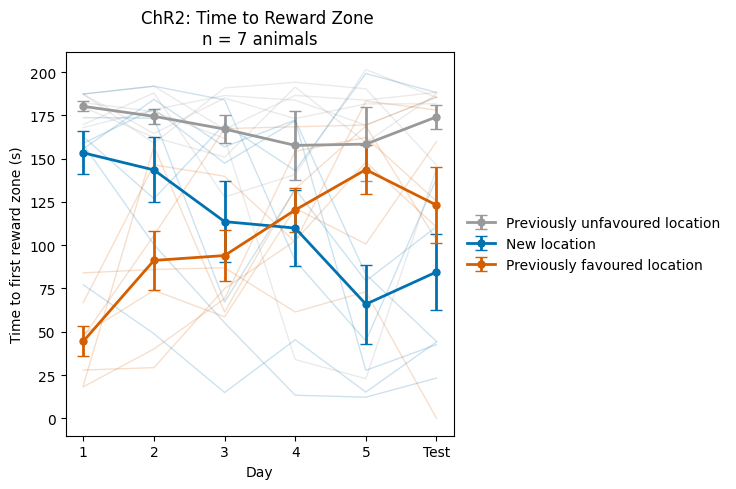

In [34]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly, “paper” style colors (similar to ggplot2 palette)
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location (highlighted)
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,                # ms → s
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    f'ChR2: Time to Reward Zone \n'
    f'n = {n_animals} animals',
    fontsize=12
)

#(≥2 s stay)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout()
plt.show()




Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


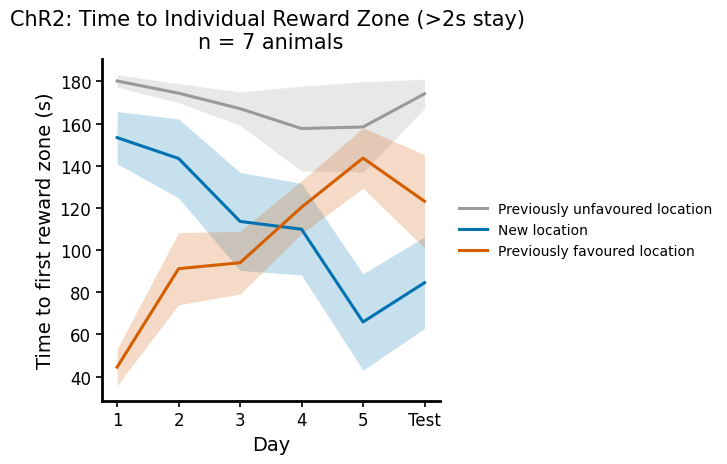

In [35]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(9, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Previously unfavoured
    2: '#0072B2',  # New location
    3: '#D55E00',  # Previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM in seconds
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[trig_id],
        alpha=0.22,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[trig_id],
        linewidth=2.2,
        label=f'{labels[trig_id]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'ChR2: Time to Individual Reward Zone (>2s stay) \n'
    f'n = {n_animals} animals',
    fontsize=15,
    pad=8
)
#(≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.8, 0.95])
plt.show()

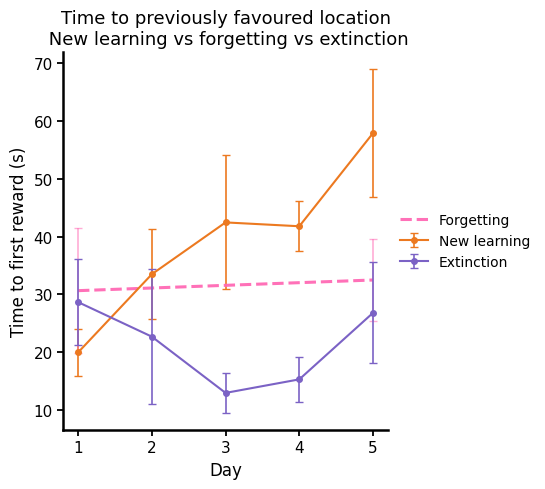

In [25]:

# ============================================================
# 1) RL stage – time to first entry into previously favoured location (trigger 3)
# ============================================================

# Start from your RL/T filter
mt_rl = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl['plot_day'] = np.nan

mask_RL = (mt_rl['trial_type'] == 'RL')
mt_rl.loc[mask_RL, 'plot_day'] = mt_rl.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl = mt_rl[(~mask_RL) | (mt_rl['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# (We don't really need the T=6 assignment for this analysis, but it won't hurt)
for sub in mt_rl['sub'].unique():
    ms = mt_rl[mt_rl['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl.index[
        (mt_rl['sub'] == sub) &
        (mt_rl['trial_type'] == 'T') &
        (mt_rl['ses'] == first_T_ses)
    ]
    mt_rl.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_stats(mt_rl, trigger_id=3):
    """
    Time to first entry into 'previously favoured' trigger for RL days 1–5.
    Returns mean_s, sem_s (seconds), each length 5.
    """
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['plot_day'].isin(rl_days))
    ].copy()

    mean_ms = np.full(len(rl_days), np.nan)
    sem_ms  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0  # seconds

mean_rl_s, sem_rl_s = rl_fav_stats(mt_rl, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – time to first entry into favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_time_to_zone2(meta_df):
    """
    For a meta_df subset (forgetting or extinction),
    compute time to trigger_id=2 per test day (1–5):

    1) mean per subject per day
    2) mean & SEM across subjects

    Returns mean_s, sem_s (seconds), length 5.
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_ms = np.full(len(test_days), np.nan)
    sem_ms  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df_day['trial_type_day'] == d] if False else df[df['trial_type_day'] == d]  # keep logic clear
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0   # seconds


meta_forg = meta_T[meta_T['test_type'] == 'forgetting'].copy()
meta_ext  = meta_T[meta_T['test_type'] == 'extinction'].copy()

mean_forg_s, sem_forg_s = build_time_to_zone2(meta_forg)
mean_ext_s,  sem_ext_s  = build_time_to_zone2(meta_ext)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction favoured zone
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_s, yerr=sem_rl_s,
    fmt='-o',
    color="#EC7920",         # unchanged
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials ----
col_f = '#FF69B4'   # pastel green (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)


# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_s[0], mean_forg_s[4]])
e_f = np.array([sem_forg_s[0],  sem_forg_s[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_s, yerr=sem_ext_s,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Time to first reward (s)', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Time to previously favoured location\n New learning vs forgetting vs extinction', fontsize=13, pad=6)
#(>2s stay)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

N per group (day 5):
  RL (RL day 5, trig3):          7
  Forgetting (Test day 5, trig2): 8
  Extinction (Test day 5, trig2): 7
RL vs Forg: raw p = 0.152
RL vs Ext: raw p = 0.62
Forg vs Ext: raw p = 0.397

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.456
  RL vs Ext: p_FDR = 0.62
  Forg vs Ext: p_FDR = 0.595


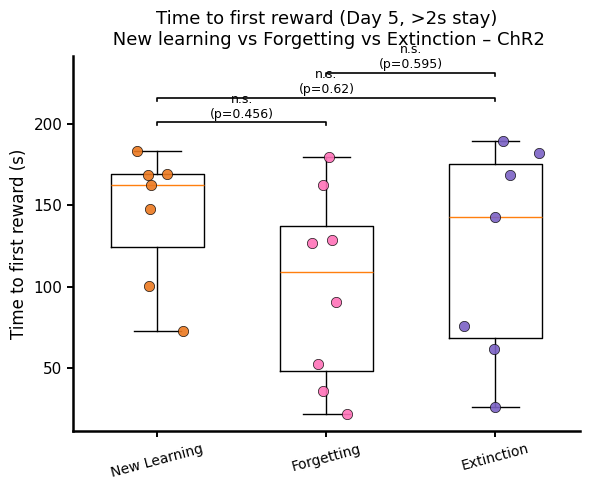

In [ ]:

from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for the three groups (all ChR2)
#    - RL day 5, trigger_id = 3  (previously favoured)
#    - Forgetting test day 5, trigger_id = 2
#    - Extinction test day 5, trigger_id = 2
#    Using time to trigger per animal (mean across trials)
# ------------------------------------------------------------

# ---- RL day 5 (RL, trig=3, day=5) ----
rl_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'RL') &
    (meta_trig['trigger_id'] == 3) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

rl_per_sub = (
    rl_df.groupby('sub')['t_to_trigger_trig']
         .mean()
         .astype(float)
)
vals_rl = (rl_per_sub.values / 1000.0)  # ms → s

# ---- Forgetting day 5 (T, trig=2, day=5) ----
forg_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'forgetting') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

forg_per_sub = (
    forg_df.groupby('sub')['t_to_trigger_trig']
           .mean()
           .astype(float)
)
vals_forg = (forg_per_sub.values / 1000.0)  # ms → s

# ---- Extinction day 5 (T, trig=2, day=5) ----
ext_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'extinction') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

ext_per_sub = (
    ext_df.groupby('sub')['t_to_trigger_trig']
          .mean()
          .astype(float)
)
vals_ext = (ext_per_sub.values / 1000.0)  # ms → s

print("N per group (day 5):")
print("  RL (RL day 5, trig3):         ", len(vals_rl))
print("  Forgetting (Test day 5, trig2):", len(vals_forg))
print("  Extinction (Test day 5, trig2):", len(vals_ext))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl, vals_forg, vals_ext]
positions = np.arange(len(groups))

# simple colour scheme (consistent with earlier line plots)
colors = {
    "New Learning":         "#EC7920",  # orange
    "Forgetting": '#FF72B8', # pink
    "Extinction": '#7b62c5ff'   #  purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",      0, 1, vals_rl,  vals_forg),
    ("RL vs Ext",       0, 2, vals_rl,  vals_ext),
    ("Forg vs Ext",     1, 2, vals_forg, vals_ext)
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing

# start a bit above max
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    stars = p_to_stars(p)
    # draw only if we have at least a valid p
    if np.isnan(p):
        continue

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max, current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # move up for next comparison

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Time to first reward (s)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Time to first reward (Day 5, >2s stay)\n New learning vs Forgetting vs Extinction – ChR2', fontsize=13, pad=8)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()